# HFE Measurements

This notebook builds measurement-focused HFE figures from the three latest recirculation logs used by `pump_performance.ipynb`:

- `log_20260417_094053.csv`
- `log_20260422_143345.csv`
- `log_20260424_153546.csv`

Figures are exported to `analysis/notebooks/HFE_measurements_plots`.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from IPython import get_ipython
from IPython.display import display
from scipy.optimize import brentq, least_squares
from scipy.special import k0

warnings.filterwarnings(
    'ignore',
    message='FigureCanvasAgg is non-interactive, and thus cannot be shown',
    category=UserWarning,
)

ip = get_ipython()
if ip is not None:
    ip.run_line_magic('config', "InlineBackend.print_figure_kwargs = {'bbox_inches': None}")

plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 180,
    'axes.grid': True,
    'grid.alpha': 0.28,
    'grid.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'raw' / 'recirculation').exists() and (candidate / 'analysis' / 'src').exists():
            return candidate
    raise RuntimeError('Could not find repo root from current working directory.')


REPO_ROOT = find_repo_root()
ANALYSIS_SRC = REPO_ROOT / 'analysis' / 'src'
if str(ANALYSIS_SRC) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_SRC))

from orca.logbook import (
    add_canonical_flow_columns,
    connected_tc_columns,
    is_legacy_wrong_type_log,
    read_tc_calibrated_csv,
    tc_display_name,
)

RECIRCULATION_DIR = REPO_ROOT / 'data' / 'raw' / 'recirculation'
PUMP_POWER_BACKUP_DIR = REPO_ROOT / 'data' / 'raw' / 'archive' / '_pump_log_backups'
TC_CALIBRATION_PATH = REPO_ROOT / 'data' / 'processed' / 'calibration' / 'TC_calibration_20260420.csv'
VENDOR_CURVE_PATH = REPO_ROOT / 'data' / 'processed' / 'pump_performance' / 'vendor_water_performance_digitized.csv'
FIGURE_DIR = REPO_ROOT / 'analysis' / 'notebooks' / 'HFE_measurements_plots'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_HFE_MEASUREMENTS_DIR = REPO_ROOT / 'data' / 'processed' / 'HFE_measurements'
PROCESSED_HFE_MEASUREMENTS_DIR.mkdir(parents=True, exist_ok=True)

PUMP_DENSITY_BOUNDS_KG_M3 = (1100.0, 1800.0)
RPM_PER_HZ_RECIRC = 30.0
MIN_SETTLE_SECONDS = 2.0
THM_CALIBRATION_ROOM_ANCHOR_C = 20.2778
THM_CALIBRATION_LOW_ANCHOR_C = -35.04
THM_CALIBRATION_U_ROOM_C = 0.058
THM_CALIBRATION_U_LOW_ANCHOR_C = 0.060
THM_RECOMMENDED_U_NOISE_C = 0.0440
THM_EXTRAPOLATION_MODEL_FRACTION = 0.01
LOOP_TC_TEMPERATURE_COLUMNS = ('TFO_C', 'TTI_C', 'TTO_C', 'TMI_C')
LOOP_MEAN_TEMPERATURE_COL = 'loop_mean_temperature_C'
POWER_RUN_KEYS = ('0417', '0422', '0424')

RUN_COLORS = {
    '0417': '#1f77b4',
    '0422': '#2ca02c',
    '0424': '#061a40',
}
POWER_RUN_LEGEND_LABELS = {
    '0417': '1st -50°C, bypass open',
    '0422': '2nd -50°C, bypass closed',
    '0424': '-100°C, bypass closed',
}
SYSTEM_RUN_CONFIGS = {
    '0417': {
        'label': 'Apr 17',
        'display_label': POWER_RUN_LEGEND_LABELS['0417'],
        'path': RECIRCULATION_DIR / 'log_20260417_094053.csv',
        'bypass_policy': 'always_open',
    },
    '0422': {
        'label': 'Apr 22',
        'display_label': POWER_RUN_LEGEND_LABELS['0422'],
        'path': RECIRCULATION_DIR / 'log_20260422_143345.csv',
        'bypass_policy': '0422_marker_window',
        'bypass_open_min': 285.5,
        'bypass_closed_min': 301.95,
    },
    '0424': {
        'label': 'Apr 24',
        'display_label': POWER_RUN_LEGEND_LABELS['0424'],
        'path': RECIRCULATION_DIR / 'log_20260424_153546.csv',
        'bypass_policy': 'first_40_to_30_transition',
    },
}
RECIRCULATION_RUN_CONFIG_BY_NAME = {
    config['path'].name: {**config, 'key': key}
    for key, config in SYSTEM_RUN_CONFIGS.items()
}

DISSERTATION_LABEL_FONTSIZE = 20
DISSERTATION_TICK_FONTSIZE = 16
DISSERTATION_LEGEND_FONTSIZE = 15
DISSERTATION_TITLE_FONTSIZE = 20
DISSERTATION_LINEWIDTH = 2.4
DISSERTATION_FIT_LINEWIDTH = 3.0
TWO_PANEL_FIGSIZE = (15.8, 7.2)
SINGLE_FIGSIZE = (12.8, 8.2)

print(f'Repo root: {REPO_ROOT}')
print(f'Recirculation logs: {RECIRCULATION_DIR}')
print(f'Figure output directory: {FIGURE_DIR}')

Repo root: /home/aamy/Documents/hfe-system
Recirculation logs: /home/aamy/Documents/hfe-system/data/raw/recirculation
Figure output directory: /home/aamy/Documents/hfe-system/analysis/notebooks/HFE_measurements_plots


## Data Loading

The loading and settled-sample selection mirror the recirculation section of `pump_performance.ipynb`: thermocouples are calibrated through the shared logbook helpers, flow-meter channels are normalized to SI, and positive-flow pump steps are trimmed by at least one sample interval after each command change.

In [2]:
def finite_numeric(frame: pd.DataFrame, column: str, default: float = np.nan) -> pd.Series:
    if column in frame.columns:
        return pd.to_numeric(frame[column], errors='coerce')
    return pd.Series(default, index=frame.index, dtype='float64')


def restore_decimal_pump_input_power(data: pd.DataFrame, path: Path) -> pd.DataFrame:
    data = data.copy()
    logged_power_w = finite_numeric(data, 'pump_input_power_w')
    data['pump_input_power_w'] = logged_power_w.astype(float)
    data['pump_input_power_logged_w'] = logged_power_w
    data['pump_input_power_restored_w'] = np.nan
    data['pump_input_power_source'] = 'logged whole-watt VFD power'

    backup_path = PUMP_POWER_BACKUP_DIR / path.name
    if not backup_path.exists():
        return data

    backup = pd.read_csv(backup_path, comment='#')
    if 'pump_input_power_w' not in backup.columns or len(backup) != len(data):
        return data

    data_time = finite_numeric(data, 'time_s').reset_index(drop=True)
    backup_time = pd.to_numeric(backup.get('time_s'), errors='coerce').reset_index(drop=True)
    aligned = data_time.notna().all() and backup_time.notna().all() and np.allclose(
        data_time.to_numpy(float), backup_time.to_numpy(float), rtol=0.0, atol=1.0e-6,
    )
    if not aligned:
        return data

    restored = pd.to_numeric(backup['pump_input_power_w'], errors='coerce').reset_index(drop=True)
    if is_legacy_wrong_type_log(path):
        restored = restored * 746.0 / 400.0
    restored.index = data.index
    use_restored = restored.notna()
    data.loc[use_restored, 'pump_input_power_restored_w'] = restored.loc[use_restored]
    data.loc[use_restored, 'pump_input_power_w'] = restored.loc[use_restored]
    data.loc[use_restored, 'pump_input_power_source'] = 'archive decimal power restored'
    return data


def add_pump_speed_columns(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    freq_hz = finite_numeric(data, 'pump_freq_hz').astype(float)
    fallback_rpm = freq_hz * RPM_PER_HZ_RECIRC

    if 'pump_rotation_speed_rpm' in data.columns:
        logged_rpm = finite_numeric(data, 'pump_rotation_speed_rpm').astype(float)
        use_fallback = logged_rpm.isna() | logged_rpm.le(0.0)
        data['pump_speed_rpm'] = logged_rpm.where(~use_fallback, fallback_rpm)
        data['pump_speed_source'] = np.where(use_fallback, 'freq_hz_x30', 'logged_rpm')
    else:
        data['pump_speed_rpm'] = fallback_rpm
        data['pump_speed_source'] = 'freq_hz_x30'
    return data


def add_loop_mean_temperature_column(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    loop_temperatures = pd.concat(
        [finite_numeric(data, column) for column in LOOP_TC_TEMPERATURE_COLUMNS],
        axis=1,
    )
    loop_temperatures.columns = LOOP_TC_TEMPERATURE_COLUMNS
    valid_count = loop_temperatures.notna().sum(axis=1)
    data['loop_temperature_tc_count'] = valid_count
    data[LOOP_MEAN_TEMPERATURE_COL] = loop_temperatures.mean(axis=1).where(
        valid_count.eq(len(LOOP_TC_TEMPERATURE_COLUMNS))
    )
    return data


def first_command_transition_min(data: pd.DataFrame, from_pct: float, to_pct: float) -> float:
    work = data.sort_values('time_s').copy()
    command = finite_numeric(work, 'pump_cmd_pct').round(0)
    changed = command.ne(command.shift()) & command.notna()
    previous = command.shift()
    transition = changed & previous.eq(float(from_pct)) & command.eq(float(to_pct))
    if transition.any():
        return float(work.loc[transition, 'time_s'].iloc[0] / 60.0)
    return np.nan


def bypass_state_for_frame(frame: pd.DataFrame, config: dict | None, step_windows: pd.DataFrame) -> tuple[pd.Series, float]:
    state = pd.Series('not specified', index=frame.index, dtype='object')
    marker_min = np.nan
    if not config:
        return state, marker_min

    policy = config.get('bypass_policy')
    time_min = finite_numeric(frame, 't_min')
    if policy == 'always_open':
        state.loc[:] = 'open'
        return state, marker_min
    if policy == '0422_marker_window':
        state.loc[:] = np.where(
            time_min.between(config['bypass_open_min'], config['bypass_closed_min']),
            'open',
            'closed',
        )
        marker_min = float(config['bypass_closed_min'])
        return state, marker_min
    if policy == 'first_40_to_30_transition':
        marker_min = first_command_transition_min(frame, 40.0, 30.0)
        if not np.isfinite(marker_min) and not step_windows.empty:
            transition = step_windows['cmd_pct'].shift(1).round().eq(40.0) & step_windows['cmd_pct'].round().eq(30.0)
            if transition.any():
                marker_min = float(step_windows.loc[step_windows.index[transition][0], 'start_s'] / 60.0)
        if np.isfinite(marker_min):
            state.loc[:] = np.where(time_min < marker_min, 'open', 'closed')
        return state, marker_min
    return state, marker_min


def settled_positive_flow_samples(data: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    work = data.copy().sort_values('time_s')
    work['cmd_bucket_pct'] = finite_numeric(work, 'pump_cmd_pct').round(0)

    fluid_meter_valid = finite_numeric(work, 'fluid_meter_valid', default=1.0).fillna(1.0).gt(0.0)
    base_mask = (
        work['pump_running'].fillna(False)
        & work['liquid_like_density'].fillna(False)
        & fluid_meter_valid
        & finite_numeric(work, 'positive_mass_flow').fillna(False).astype(bool)
        & finite_numeric(work, 'volume_flow_lmin_si').gt(0.0)
        & finite_numeric(work, 'mass_flow_kgmin_si').gt(0.0)
        & finite_numeric(work, 'pump_speed_rpm').gt(0.0)
        & finite_numeric(work, 'cmd_bucket_pct').gt(0.0)
        & finite_numeric(work, 'TMI_C').notna()
    )
    work = work.loc[base_mask].copy()
    if work.empty:
        return work, pd.DataFrame()

    dt_s = finite_numeric(work, 'time_s').diff().clip(lower=0.0)
    positive_dt = dt_s[dt_s.gt(0.0) & dt_s.notna()]
    median_dt_s = float(positive_dt.median()) if not positive_dt.empty else MIN_SETTLE_SECONDS
    settle_cutoff_s = max(MIN_SETTLE_SECONDS, median_dt_s)
    time_gap_break_s = max(10.0, 5.0 * median_dt_s)

    command_changed = work['cmd_bucket_pct'].ne(work['cmd_bucket_pct'].shift())
    time_gap = dt_s.fillna(0.0).gt(time_gap_break_s)
    work['step_id'] = (command_changed | time_gap).cumsum()
    work['time_from_step_s'] = work.groupby('step_id')['time_s'].transform(lambda series: series - series.iloc[0])

    step_windows = (
        work.groupby('step_id')
        .agg(
            log_name=('log_name', 'first'),
            log_key=('log_key', 'first'),
            run_label=('run_label', 'first'),
            cmd_pct=('cmd_bucket_pct', 'first'),
            start_s=('time_s', 'min'),
            end_s=('time_s', 'max'),
            duration_s=('time_s', lambda series: float(series.iloc[-1] - series.iloc[0])),
            median_speed_rpm=('pump_speed_rpm', 'median'),
            median_tmi_C=('TMI_C', 'median'),
            median_delta_p_bar=('delta_p_bar_recomputed', 'median'),
            sample_count=('time_s', 'size'),
        )
        .reset_index()
    )
    step_windows['settle_cutoff_s'] = settle_cutoff_s

    settled = work.loc[work['time_from_step_s'].ge(settle_cutoff_s)].copy()
    return settled, step_windows


def load_one_log(path: Path) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.DataFrame]:
    raw = read_tc_calibrated_csv(path, calibration_path=TC_CALIBRATION_PATH)
    data, flow_note = add_canonical_flow_columns(
        raw,
        density_bounds=PUMP_DENSITY_BOUNDS_KG_M3,
        log_path=path,
    )
    data = restore_decimal_pump_input_power(data, path)
    data = add_pump_speed_columns(data)
    data = add_loop_mean_temperature_column(data)
    config = RECIRCULATION_RUN_CONFIG_BY_NAME.get(path.name)
    data['log_name'] = path.name
    data['log_key'] = config['key'] if config else path.stem
    data['run_label'] = config.get('display_label', config.get('label', path.stem)) if config else path.stem
    data['t_min'] = finite_numeric(data, 'time_s') / 60.0

    settled, step_windows = settled_positive_flow_samples(data)
    bypass_state, bypass_marker_min = bypass_state_for_frame(settled, config, step_windows)
    if not settled.empty:
        settled = settled.copy()
        settled['bypass_state'] = bypass_state
    if not step_windows.empty:
        step_windows = step_windows.copy()
        step_windows['bypass_marker_min'] = bypass_marker_min

    coverage = pd.Series({
        'log_name': path.name,
        'run_label': data['run_label'].iloc[0] if len(data) else path.stem,
        'raw_rows': len(raw),
        'settled_samples': len(settled),
        'legacy_pre_fix_log': is_legacy_wrong_type_log(path),
        'legacy_tc_correction_applied': bool(data.attrs.get('legacy_tc_correction_applied', False)),
        'restored_tc_calibration_applied': bool(data.attrs.get('tc_calibration_applied_from_log_metadata', False)),
        'pump_speed_sources': ', '.join(sorted(set(data['pump_speed_source'].dropna().astype(str)))) or 'none',
        'bypass_states': ', '.join(sorted(set(settled['bypass_state'].dropna().astype(str)))) if not settled.empty else '',
        'bypass_marker_min': bypass_marker_min,
        'tmi_min_C': float(settled['TMI_C'].min()) if not settled.empty else np.nan,
        'tmi_max_C': float(settled['TMI_C'].max()) if not settled.empty else np.nan,
        'flow_meter_temperature_min_C': float(settled['temperature_c_si'].min()) if not settled.empty else np.nan,
        'flow_meter_temperature_max_C': float(settled['temperature_c_si'].max()) if not settled.empty else np.nan,
        'density_min_kg_m3': float(settled['density_kg_m3_si'].min()) if not settled.empty else np.nan,
        'density_max_kg_m3': float(settled['density_kg_m3_si'].max()) if not settled.empty else np.nan,
        'normalization_note': flow_note,
    })
    return data, settled, coverage, step_windows


full_run_frames: dict[str, pd.DataFrame] = {}
settled_frames: list[pd.DataFrame] = []
coverage_rows: list[pd.Series] = []
step_window_frames: list[pd.DataFrame] = []

for key, config in SYSTEM_RUN_CONFIGS.items():
    full, settled, coverage_row, step_windows = load_one_log(config['path'])
    full_run_frames[key] = full
    settled_frames.append(settled)
    coverage_rows.append(coverage_row)
    if not step_windows.empty:
        step_window_frames.append(step_windows)

coverage = pd.DataFrame(coverage_rows).set_index('log_name')
settled_samples = pd.concat(settled_frames, ignore_index=True) if settled_frames else pd.DataFrame()
step_windows = pd.concat(step_window_frames, ignore_index=True) if step_window_frames else pd.DataFrame()

print(f'Loaded {len(SYSTEM_RUN_CONFIGS)} recirculation logs.')
print(f'Settled positive-flow samples retained: {len(settled_samples):,}')
display(
    coverage[[
        'raw_rows', 'settled_samples', 'run_label', 'legacy_pre_fix_log',
        'legacy_tc_correction_applied', 'restored_tc_calibration_applied',
        'pump_speed_sources', 'bypass_states', 'bypass_marker_min',
        'tmi_min_C', 'tmi_max_C', 'flow_meter_temperature_min_C',
        'flow_meter_temperature_max_C', 'density_min_kg_m3', 'density_max_kg_m3',
    ]].round(3)
)

Loaded 3 recirculation logs.
Settled positive-flow samples retained: 20,634


,raw_rows,settled_samples,run_label,legacy_pre_fix_log,legacy_tc_correction_applied,restored_tc_calibration_applied,pump_speed_sources,bypass_states,bypass_marker_min,tmi_min_C,tmi_max_C,flow_meter_temperature_min_C,flow_meter_temperature_max_C,density_min_kg_m3,density_max_kg_m3
log_name,,,,,,,,,,,,,,,
log_20260417_094053.csv,10091,8308,"1st -50°C, bypass open",True,True,False,"freq_hz_x30, logged_rpm",open,NaN,-57.817,20.464,-53.368,19.870,1437.267,1589.965
log_20260422_143345.csv,11210,4509,"2nd -50°C, bypass closed",False,False,False,"freq_hz_x30, logged_rpm","closed, open",301.950,-65.360,20.970,-58.052,21.093,1434.411,1600.126
log_20260424_153546.csv,9467,7817,"-100°C, bypass closed",False,False,False,"freq_hz_x30, logged_rpm","closed, open",57.994,-99.890,21.460,-94.380,21.567,1434.000,1673.000


In [3]:
def load_vendor_curve() -> pd.DataFrame:
    if VENDOR_CURVE_PATH.exists():
        return pd.read_csv(VENDOR_CURVE_PATH)
    raise FileNotFoundError(f'Could not find digitized pump.pdf vendor curve: {VENDOR_CURVE_PATH}')


def vendor_zero_pressure_displacement() -> tuple[float, float]:
    zero_pressure = vendor_curve.loc[
        vendor_curve['differential_pressure_bar'].eq(0.0) & vendor_curve['flow_lmin'].notna()
    ].copy()
    if zero_pressure.empty:
        raise RuntimeError('Vendor curve does not contain zero-pressure points.')

    speed = zero_pressure['speed_rpm'].to_numpy(float)
    flow = zero_pressure['flow_lmin'].to_numpy(float)
    displacement = 1000.0 * float(np.sum(speed * flow) / np.sum(speed**2))
    point_displacement = flow * 1000.0 / speed
    displacement_sigma = float(point_displacement.std(ddof=1))
    return displacement, displacement_sigma


vendor_curve = load_vendor_curve()
VENDOR_DISPLACEMENT_ML_PER_REV, VENDOR_DISPLACEMENT_SIGMA_ML_PER_REV = vendor_zero_pressure_displacement()
if not np.isfinite(VENDOR_DISPLACEMENT_SIGMA_ML_PER_REV) or VENDOR_DISPLACEMENT_SIGMA_ML_PER_REV <= 0.0:
    VENDOR_DISPLACEMENT_SIGMA_ML_PER_REV = 0.15

samples = settled_samples.copy().replace([np.inf, -np.inf], np.nan)
samples['delta_p_bar_plot'] = samples['delta_p_bar_recomputed'].clip(lower=0.0)
samples['delivered_ml_per_rev'] = samples['volume_flow_lmin_si'] * 1000.0 / samples['pump_speed_rpm']
samples['apparent_slip_pct_vs_zero_dp'] = 100.0 * (
    VENDOR_DISPLACEMENT_ML_PER_REV - samples['delivered_ml_per_rev']
) / VENDOR_DISPLACEMENT_ML_PER_REV
samples['delta_p_per_krpm_bar'] = samples['delta_p_bar_plot'] / (samples['pump_speed_rpm'] / 1000.0)

plot04b_samples = samples.loc[
    samples['log_key'].isin(POWER_RUN_KEYS)
    & samples['pump_speed_rpm'].ge(180.0)
    & samples['delta_p_bar_plot'].notna()
    & samples['TMI_C'].notna()
    & samples['cmd_bucket_pct'].notna()
    & samples['apparent_slip_pct_vs_zero_dp'].notna()
].copy()
plot04b_samples = plot04b_samples.sort_values(['log_key', 'cmd_bucket_pct', 'TMI_C'])

print(f'Vendor zero-pressure displacement basis: {VENDOR_DISPLACEMENT_ML_PER_REV:.3f} ± {VENDOR_DISPLACEMENT_SIGMA_ML_PER_REV:.3f} mL/rev')
print(f'Plot-04b-equivalent viscosity/proxy samples: {len(plot04b_samples):,}')

Vendor zero-pressure displacement basis: 3.145 ± 0.151 mL/rev
Plot-04b-equivalent viscosity/proxy samples: 20,466


## Shared Plot Helpers and HFE Reference Curves

In [4]:
def save_figure(fig: mpl.figure.Figure, filename: str, *, pad_inches: float = 0.10) -> Path:
    path = FIGURE_DIR / filename
    fig.savefig(path, bbox_inches='tight', pad_inches=pad_inches)
    print(f'Saved {path.relative_to(REPO_ROOT)}')
    return path


def style_axis(ax):
    ax.minorticks_on()
    ax.grid(True, which='major', alpha=0.30, linewidth=0.8)
    ax.grid(True, which='minor', alpha=0.13, linewidth=0.5)
    ax.tick_params(axis='both', which='major', labelsize=DISSERTATION_TICK_FONTSIZE, length=7, width=1.2)
    ax.tick_params(axis='both', which='minor', length=4, width=1.0)


def thm_extrapolation_model_uncertainty_C(temperature_c):
    temperature = np.asarray(temperature_c, dtype=float)
    uncertainty = THM_EXTRAPOLATION_MODEL_FRACTION * np.maximum(0.0, THM_CALIBRATION_LOW_ANCHOR_C - temperature)
    return float(uncertainty) if uncertainty.ndim == 0 else uncertainty


def thm_calibration_standard_uncertainty_C(temperature_c):
    temperature = np.asarray(temperature_c, dtype=float)
    anchor_span_C = THM_CALIBRATION_ROOM_ANCHOR_C - THM_CALIBRATION_LOW_ANCHOR_C
    low_anchor_term = ((THM_CALIBRATION_ROOM_ANCHOR_C - temperature) / anchor_span_C * THM_CALIBRATION_U_LOW_ANCHOR_C) ** 2
    room_anchor_term = ((temperature - THM_CALIBRATION_LOW_ANCHOR_C) / anchor_span_C * THM_CALIBRATION_U_ROOM_C) ** 2
    noise_term = THM_RECOMMENDED_U_NOISE_C ** 2
    model_term = thm_extrapolation_model_uncertainty_C(temperature) ** 2
    uncertainty = np.sqrt(low_anchor_term + room_anchor_term + noise_term + model_term)
    return float(uncertainty) if uncertainty.ndim == 0 else uncertainty


def hfe7200_density_kg_m3(temperature_c):
    """3M Novec/HFE 7200 TDS liquid density, converted from g/mL to kg/m^3."""
    return 1000.0 * (1.4811 - 0.0023026 * np.asarray(temperature_c, dtype=float))


# Viscosity points from HFE Freezing Data.pdf, final slide, also used in HFE_properties.ipynb.
hfe7200_viscosity_points = pd.DataFrame({
    'temperature_c': [25.0, 0.0, -10.0, -20.0, -30.0, -40.0, -50.0, -60.0, -70.0, -100.0, -120.0],
    'kinematic_viscosity_cst': [0.41, 0.67, 0.78, 0.93, 1.14, 1.42, 1.84, 2.48, 3.72, 12.47, 64.47],
}).sort_values('temperature_c')

SEETON_MIN_VISCOSITY_CST = 0.04
SEETON_BESSEL_OFFSET_CST = 1.244067


def seeton_viscosity_transform(viscosity_cst):
    viscosity_cst = np.asarray(viscosity_cst, dtype=float)
    correction = np.exp(-viscosity_cst) * k0(viscosity_cst + SEETON_BESSEL_OFFSET_CST)
    return np.log(np.log(viscosity_cst + 0.7 + correction))


def invert_seeton_transform(target_transform, high_start_cst):
    target_transform = float(target_transform)
    low_cst = SEETON_MIN_VISCOSITY_CST
    low_transform = float(seeton_viscosity_transform(low_cst))
    if target_transform < low_transform:
        raise ValueError('Seeton fit evaluated below the 0.04 cSt lower validity limit.')

    high_cst = max(float(high_start_cst), 2.0 * low_cst)
    while float(seeton_viscosity_transform(high_cst)) < target_transform:
        high_cst *= 2.0
        if high_cst > 1.0e8:
            raise RuntimeError('Could not bracket the Seeton viscosity inversion.')

    return brentq(
        lambda trial_cst: float(seeton_viscosity_transform(trial_cst)) - target_transform,
        low_cst,
        high_cst,
        xtol=1.0e-10,
        rtol=1.0e-10,
    )


def evaluate_seeton_viscosity(temperature_c, coefficient_a, coefficient_b, high_start_cst):
    temperature_c = np.asarray(temperature_c, dtype=float)
    temperature_k = temperature_c + 273.15
    target_transform = coefficient_a - coefficient_b * np.log(temperature_k)
    flat_result = [
        invert_seeton_transform(target_value, high_start_cst)
        for target_value in np.ravel(target_transform)
    ]
    return np.asarray(flat_result).reshape(target_transform.shape)


def fit_seeton_viscosity(temperature_c, viscosity_cst):
    temperature_c = np.asarray(temperature_c, dtype=float)
    temperature_k = temperature_c + 273.15
    viscosity_cst = np.asarray(viscosity_cst, dtype=float)
    high_start_cst = max(2.0 * float(np.max(viscosity_cst)), 1.0)
    transformed_viscosity = seeton_viscosity_transform(viscosity_cst)
    slope, intercept = np.polyfit(np.log(temperature_k), transformed_viscosity, 1)
    initial_guess = np.array([float(intercept), float(-slope)])

    def fitted_viscosity(params):
        coefficient_a, coefficient_b = params
        return evaluate_seeton_viscosity(temperature_c, coefficient_a, coefficient_b, high_start_cst)

    def log_residual(params):
        return np.log(fitted_viscosity(params)) - np.log(viscosity_cst)

    result = least_squares(log_residual, initial_guess)
    coefficient_a, coefficient_b = result.x

    def evaluate(new_temperature_c):
        return evaluate_seeton_viscosity(new_temperature_c, coefficient_a, coefficient_b, high_start_cst)

    params = {
        'A': float(coefficient_a),
        'B': float(coefficient_b),
        'log_rmse': float(np.sqrt(np.mean(log_residual(result.x) ** 2))),
    }
    return params, evaluate


hfe7200_seeton_params, hfe7200_kinematic_viscosity_cst = fit_seeton_viscosity(
    hfe7200_viscosity_points['temperature_c'],
    hfe7200_viscosity_points['kinematic_viscosity_cst'],
)


def hfe7200_dynamic_viscosity_mpa_s(temperature_c):
    """Dynamic viscosity from the Seeton kinematic-viscosity fit and vendor density."""
    return hfe7200_kinematic_viscosity_cst(temperature_c) * hfe7200_density_kg_m3(temperature_c) / 1000.0

display(hfe7200_viscosity_points)
display(pd.DataFrame([hfe7200_seeton_params], index=['HFE 7200 Seeton']).round(4))

,temperature_c,kinematic_viscosity_cst
10,-120.0,64.47
9,-100.0,12.47
8,-70.0,3.72
7,-60.0,2.48
6,-50.0,1.84
5,-40.0,1.42
4,-30.0,1.14
3,-20.0,0.93
2,-10.0,0.78
1,0.0,0.67


,A,B,log_rmse
HFE 7200 Seeton,22.383,4.1607,0.1056


## 01. HFE Density Versus Temperature

Saved analysis/notebooks/HFE_measurements_plots/01_hfe_density_vs_temperature.png


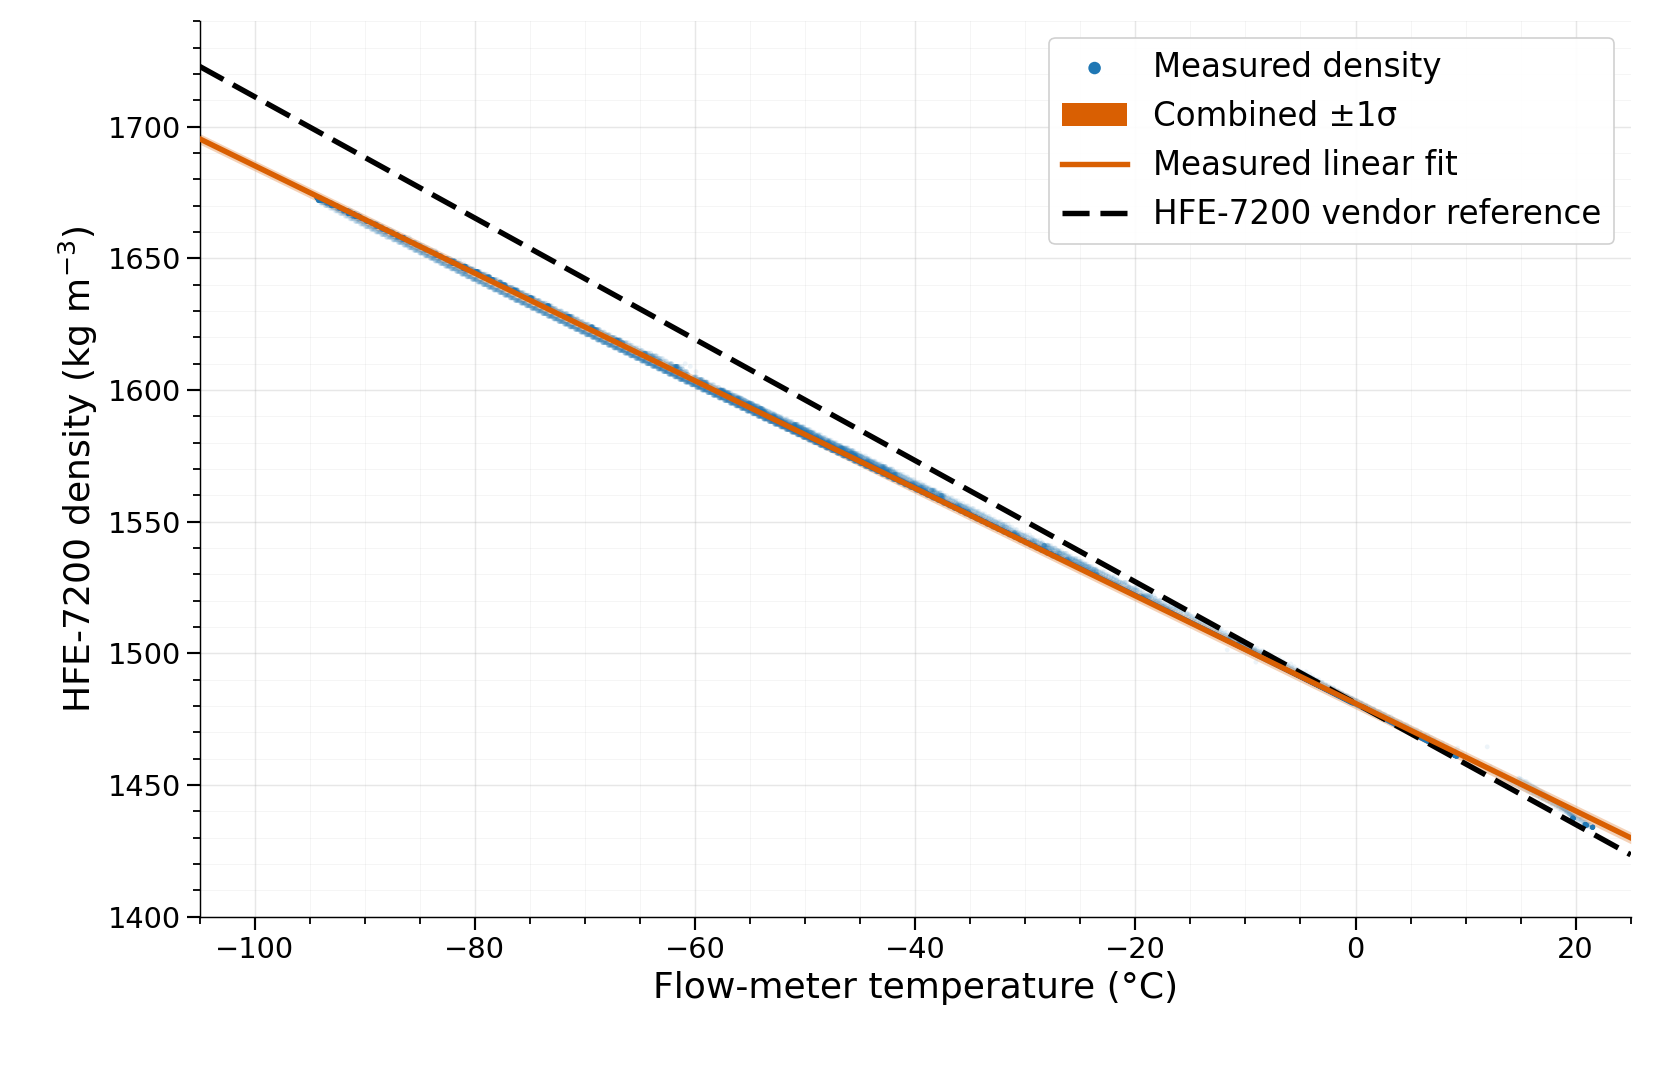

Density plot samples: 20,634
Density raw fit samples: 20,634
Flow-meter standard uncertainty range: σT = 0.59-0.90 °C, σρ = 0.60-1.16 kg/m^3
Measured density fit: ρ(T) = (1440.18 ± 0.03) + (2.0415 ± 0.0004) × (20°C - T) kg/m^3
Density raw residual σ: 1.08 kg/m^3; raw RMSE: 1.08 kg/m^3
Density combined 1σ band: 1.98-2.23 kg/m^3
Density weighted reduced χ²: 0.39
Uncertainty basis: OPTIMASS 6000 density ±1 kg/m^3, repeatability ±0.3 kg/m^3, density temperature effect ±0.015 kg/m^3/°C, temperature ±0.5°C ±0.5% of absolute reading; MPE terms converted to 1σ by /√3.


In [5]:
FLOW_METER_DENSITY_COLOR = '#1f77b4'
FLOW_METER_DENSITY_FIT_COLOR = '#d95f02'
FLOW_METER_DENSITY_CALIBRATION_T_C = 20.0
FLOW_METER_TEMPERATURE_BASE_MPE_C = 0.5
FLOW_METER_TEMPERATURE_REL_MPE = 0.005
FLOW_METER_DENSITY_BASE_MPE_KG_M3 = 1.0
FLOW_METER_DENSITY_REPEATABILITY_MPE_KG_M3 = 0.3
FLOW_METER_DENSITY_TEMP_MPE_KG_M3_PER_C = 0.015


def flow_meter_temperature_standard_uncertainty_C(temperature_c):
    # OPTIMASS 6000 temperature error: ±0.5°C ±0.5% of reading; the percent term uses absolute temperature.
    temperature_k = np.asarray(temperature_c, dtype=float) + 273.15
    mpe_c = np.sqrt(FLOW_METER_TEMPERATURE_BASE_MPE_C**2 + (FLOW_METER_TEMPERATURE_REL_MPE * np.abs(temperature_k))**2)
    return mpe_c / np.sqrt(3.0)


def flow_meter_density_standard_uncertainty_kg_m3(temperature_c):
    # OPTIMASS 6000 density terms: base accuracy, repeatability, and temperature-deviation error.
    temperature_c = np.asarray(temperature_c, dtype=float)
    temperature_mpe_kg_m3 = FLOW_METER_DENSITY_TEMP_MPE_KG_M3_PER_C * np.abs(
        temperature_c - FLOW_METER_DENSITY_CALIBRATION_T_C
    )
    mpe_kg_m3 = np.sqrt(
        FLOW_METER_DENSITY_BASE_MPE_KG_M3**2
        + FLOW_METER_DENSITY_REPEATABILITY_MPE_KG_M3**2
        + temperature_mpe_kg_m3**2
    )
    return mpe_kg_m3 / np.sqrt(3.0)


def density_linear_model(temperature_c, rho_20_kg_m3, alpha_kg_m3_per_C):
    return rho_20_kg_m3 + alpha_kg_m3_per_C * (FLOW_METER_DENSITY_CALIBRATION_T_C - np.asarray(temperature_c, dtype=float))


density_samples = samples.dropna(subset=['density_kg_m3_si', 'temperature_c_si', 'log_key']).copy()
density_samples = density_samples.loc[
    density_samples['density_kg_m3_si'].between(*PUMP_DENSITY_BOUNDS_KG_M3)
].copy()
density_samples['temperature_sigma_C'] = flow_meter_temperature_standard_uncertainty_C(density_samples['temperature_c_si'])
density_samples['density_sigma_kg_m3'] = flow_meter_density_standard_uncertainty_kg_m3(density_samples['temperature_c_si'])

fit_temperature = density_samples['temperature_c_si'].to_numpy(float)
fit_density_measured = density_samples['density_kg_m3_si'].to_numpy(float)
fit_density_sigma = density_samples['density_sigma_kg_m3'].to_numpy(float)
fit_temperature_sigma = density_samples['temperature_sigma_C'].to_numpy(float)

initial_slope = max(0.0, -float(np.polyfit(fit_temperature, fit_density_measured, 1)[0]))
initial_rho_20 = float(np.interp(
    FLOW_METER_DENSITY_CALIBRATION_T_C,
    np.sort(fit_temperature),
    fit_density_measured[np.argsort(fit_temperature)],
))


def density_fit_residuals(params):
    rho_20_kg_m3, alpha_kg_m3_per_C = params
    effective_sigma = np.sqrt(fit_density_sigma**2 + (alpha_kg_m3_per_C * fit_temperature_sigma)**2)
    return (density_linear_model(fit_temperature, rho_20_kg_m3, alpha_kg_m3_per_C) - fit_density_measured) / effective_sigma


density_fit_result = least_squares(
    density_fit_residuals,
    x0=np.array([initial_rho_20, initial_slope]),
    bounds=([0.0, 0.0], [np.inf, np.inf]),
)
density_fit_rho20_kg_m3, density_fit_alpha_kg_m3_per_C = density_fit_result.x

density_fit_effective_sigma = np.sqrt(
    fit_density_sigma**2 + (density_fit_alpha_kg_m3_per_C * fit_temperature_sigma)**2
)
density_fit_design = np.column_stack([
    np.ones_like(fit_temperature),
    FLOW_METER_DENSITY_CALIBRATION_T_C - fit_temperature,
])
density_fit_weight = 1.0 / density_fit_effective_sigma**2
density_fit_xtwx = density_fit_design.T @ (density_fit_design * density_fit_weight[:, None])
density_fit_cov = np.linalg.inv(density_fit_xtwx)
density_fit_dof = max(len(fit_temperature) - 2, 1)
density_fit_weighted_reduced_chi2 = float(np.sum(density_fit_residuals(density_fit_result.x) ** 2) / density_fit_dof)
density_fit_cov *= max(density_fit_weighted_reduced_chi2, 1.0)
density_fit_param_sigma = np.sqrt(np.diag(density_fit_cov))

density_fit_raw_residuals = fit_density_measured - density_linear_model(
    fit_temperature,
    density_fit_rho20_kg_m3,
    density_fit_alpha_kg_m3_per_C,
)
density_fit_raw_sigma_kg_m3 = float(np.std(density_fit_raw_residuals, ddof=2))

temperature_grid_c = np.linspace(-105.0, 25.0, 500)
vendor_density = hfe7200_density_kg_m3(temperature_grid_c)
measured_density_fit = density_linear_model(
    temperature_grid_c,
    density_fit_rho20_kg_m3,
    density_fit_alpha_kg_m3_per_C,
)
measured_density_grid_temperature_sigma_C = flow_meter_temperature_standard_uncertainty_C(temperature_grid_c)
measured_density_grid_sigma_kg_m3 = flow_meter_density_standard_uncertainty_kg_m3(temperature_grid_c)
measured_density_fit_sigma = np.sqrt(
    density_fit_raw_sigma_kg_m3**2
    + measured_density_grid_sigma_kg_m3**2
    + (density_fit_alpha_kg_m3_per_C * measured_density_grid_temperature_sigma_C)**2
)

fig, ax = plt.subplots(figsize=SINGLE_FIGSIZE, constrained_layout=False)
ax.scatter(
    density_samples['temperature_c_si'],
    density_samples['density_kg_m3_si'],
    s=7,
    alpha=0.08,
    color=FLOW_METER_DENSITY_COLOR,
    edgecolors='none',
    rasterized=True,
    label='Measured density',
    zorder=3,
)
ax.fill_between(
    temperature_grid_c,
    measured_density_fit - measured_density_fit_sigma,
    measured_density_fit + measured_density_fit_sigma,
    color=FLOW_METER_DENSITY_FIT_COLOR,
    alpha=0.28,
    linewidth=0,
    label='Combined ±1σ',
    zorder=1,
)
ax.plot(
    temperature_grid_c,
    measured_density_fit,
    color=FLOW_METER_DENSITY_FIT_COLOR,
    lw=DISSERTATION_FIT_LINEWIDTH,
    label='Measured linear fit',
    zorder=4,
)
ax.plot(
    temperature_grid_c,
    vendor_density,
    color='black',
    lw=DISSERTATION_FIT_LINEWIDTH,
    linestyle=(0, (5, 2)),
    label='HFE-7200 vendor reference',
    zorder=3,
)
ax.set_xlabel('Flow-meter temperature (°C)', fontsize=DISSERTATION_LABEL_FONTSIZE)
ax.set_ylabel(r'HFE-7200 density (kg m$^{-3}$)', fontsize=DISSERTATION_LABEL_FONTSIZE)
ax.set_xlim(-105.0, 25.0)
style_axis(ax)

y_values = np.concatenate([
    density_samples['density_kg_m3_si'].to_numpy(float),
    vendor_density,
    measured_density_fit - measured_density_fit_sigma,
    measured_density_fit + measured_density_fit_sigma,
])
y_min = 20.0 * np.floor((np.nanmin(y_values) - 15.0) / 20.0)
y_max = 20.0 * np.ceil((np.nanmax(y_values) + 15.0) / 20.0)
ax.set_ylim(y_min, y_max)

legend = ax.legend(loc='upper right', fontsize=18, frameon=True, framealpha=0.92)
for handle in legend.legend_handles:
    if hasattr(handle, 'set_alpha'):
        handle.set_alpha(1.0)
    if hasattr(handle, 'set_sizes'):
        handle.set_sizes([48])
legend.get_frame().set_linewidth(0.9)

fig.subplots_adjust(left=0.12, right=0.98, top=0.98, bottom=0.14)
save_figure(fig, '01_hfe_density_vs_temperature.png')
plt.show()

density_fit_rmse_kg_m3 = float(np.sqrt(np.mean(density_fit_raw_residuals**2)))
print(f'Density plot samples: {len(density_samples):,}')
print(f'Density raw fit samples: {len(fit_temperature):,}')
print(
    'Flow-meter standard uncertainty range: '
    f'σT = {density_samples["temperature_sigma_C"].min():.2f}-{density_samples["temperature_sigma_C"].max():.2f} °C, '
    f'σρ = {density_samples["density_sigma_kg_m3"].min():.2f}-{density_samples["density_sigma_kg_m3"].max():.2f} kg/m^3'
)
print(
    'Measured density fit: '
    f'ρ(T) = ({density_fit_rho20_kg_m3:.2f} ± {density_fit_param_sigma[0]:.2f}) '
    f'+ ({density_fit_alpha_kg_m3_per_C:.4f} ± {density_fit_param_sigma[1]:.4f}) × (20°C - T) kg/m^3'
)
print(f'Density raw residual σ: {density_fit_raw_sigma_kg_m3:.2f} kg/m^3; raw RMSE: {density_fit_rmse_kg_m3:.2f} kg/m^3')
print(f'Density combined 1σ band: {measured_density_fit_sigma.min():.2f}-{measured_density_fit_sigma.max():.2f} kg/m^3')
print(f'Density weighted reduced χ²: {density_fit_weighted_reduced_chi2:.2f}')
print('Uncertainty basis: OPTIMASS 6000 density ±1 kg/m^3, repeatability ±0.3 kg/m^3, density temperature effect ±0.015 kg/m^3/°C, temperature ±0.5°C ±0.5% of absolute reading; MPE terms converted to 1σ by /√3.')


## 02. Estimated HFE Viscosity From Pump-Load Data

Plot 02 uses the three latest recirculation runs and keeps both bypass-open and bypass-closed samples, with the strict mean of the four loop thermocouples (`TFO_C`, `TTI_C`, `TTO_C`, and `TMI_C`) on the x axis. The model is a pressure-flow resistance decomposition, `Delta P / Q = R_visc(T) + C_state rho Q`, then converts the corrected viscous resistance to estimated kinematic viscosity with the anchor `nu(0 deg C) = 0.67 cSt`. To keep the flow-dependent term defensible, `C_state` is fitted only from short pump-speed sweeps at nearly fixed temperature: the closed-loop coefficient uses the Apr 22 closed sweep around `-50 deg C`, while the open-loop coefficient uses the Apr 22 open sweep near `0 deg C`. The Apr 24 near `-100 deg C` sweep is reported as a diagnostic but is not used for the default correction.


Saved analysis/notebooks/HFE_measurements_plots/02_hfe_apparent_viscosity_index_vs_loop_mean_temperature.png


Saved analysis/notebooks/HFE_measurements_plots/02cp_hfe_apparent_dynamic_viscosity_index_vs_loop_mean_temperature.png
Plot 02 model: Delta P / Q - C_state*rho*Q, with state-specific C from local speed sweeps
Latest recirculation run keys used: 0417, 0422, 0424
Plot 02 retained corrected samples = 18,681
Plot 02 rolling summary points = 18,658
Plot 02 Seeton fit points = 116
Plot 02 Seeton fit: A = 18.009, B = 3.3834, log residual 1sigma = 0.107, combined band log 1sigma = 0.110-0.192
Plot 02 fit weighting: 1 deg C bins = 116, summary points/bin = 1-338, rolling samples/bin median = 89-1831, reading log sigma = 0.023-0.160, fit weight = 39.3-1829.2
Plot 02 fit curve range: -125.00 to 30.00 deg C
Plot 02cp dynamic conversion: mu = nu*rho(T), rho from Plot 01 measured density fit; rho20 = 1440.2 kg/m^3, alpha = 2.0415 kg/m^3/K, curve range = -125.00 to 30.00 deg C
Plot 02 anchor: sample median within anchor band, median loop T = -1.73 deg C, n = 1337, nu_anchor = 0.67 cSt at 0 deg C, TCs

,coefficient_state,flow_coefficient,flow_coefficient_sigma,fit_sigma_component,between_window_sigma,effective_fit_count,fit_count,sample_count,temperature_min_C,temperature_max_C,mean_r2,source
0,closed,0.000024,3.290000e-06,3.090000e-06,0.000001,3.844309,4,2486,-59.98,-40.01,0.914860,"Apr 22 closed speed sweep, -60 to -40 deg C"
1,open,0.000019,7.200000e-07,7.200000e-07,0.000000,1.000000,1,120,-4.97,-3.62,0.998491,"Apr 22 open speed sweep, -5 to 0 deg C"


,window_label,log_key,bypass_state,coefficient_state,use_for_model,tmi_bin,temperature_C,temperature_min_C,temperature_max_C,slope_bar_per_lmin_per_density_flow,slope_sigma_bar_per_lmin_per_density_flow,intercept_bar_per_lmin,intercept_sigma_bar_per_lmin,group_count,sample_count,cmd_values,r2
0,"Apr 22 closed speed sweep, -60 to -40 deg C",0422,closed,closed,True,"(-60.0, -55.0]",-56.4900,-59.98,-55.01,0.000027,0.000005,0.063783,0.028351,4,440,"20, 40, 60, 80",0.934049
1,"Apr 22 closed speed sweep, -60 to -40 deg C",0422,closed,closed,True,"(-55.0, -50.0]",-52.5700,-54.99,-50.02,0.000026,0.000003,0.065029,0.020749,5,577,"20, 40, 60, 70, 80",0.950294
2,"Apr 22 closed speed sweep, -60 to -40 deg C",0422,closed,closed,True,"(-50.0, -45.0]",-47.5225,-50.00,-45.01,0.000021,0.000006,0.097997,0.036669,4,702,"40, 60, 70, 80",0.876506
3,"Apr 22 closed speed sweep, -60 to -40 deg C",0422,closed,closed,True,"(-45.0, -40.0]",-42.2700,-44.98,-40.01,0.000025,0.000008,0.071270,0.048674,3,767,"40, 60, 80",0.912300
4,"Apr 22 open speed sweep, -5 to 0 deg C",0422,open,open,True,"(-5.0, 0.0]",-4.1000,-4.97,-3.62,0.000019,0.000001,0.056535,0.004681,3,120,"40, 75, 80",0.998491
5,"Apr 24 closed diagnostic, -100 to -95 deg C",0424,closed,closed,False,"(-100.0, -95.0]",-97.3700,-99.89,-95.01,0.000037,0.000012,0.262384,0.071605,5,1151,"40, 45, 50, 55, 60",0.745560


,plot_02_anchor
reference_temperature_C,-1.727903
reference_value,0.035825
reference_sample_count,1337
reference_mean,0.038017
reference_std,0.024712
reference_sem,0.000676
reference_anchor_temperature_C,0.0
reference_anchor_kinematic_cSt,0.67
reference_band_half_width_C,5.0
reference_source,sample median within anchor band


,fit_bin_C,temperature_C,viscosity_cSt,viscosity_sigma_cSt,temperature_sigma_C,sample_count,rolling_sample_count_median,rolling_sample_count_min,rolling_sample_count_max,log_viscosity_sigma,log_temperature_sigma,reading_log_sigma,fit_weight,fit_band_log_sigma
0,-99.0,-98.35750,5.268541,0.270227,0.325445,235,773.0,640,934,0.051291,0.012358,0.052758,359.268161,0.119366
1,-98.0,-97.60250,5.061616,0.266936,0.321588,254,1076.5,941,1124,0.052737,0.012026,0.054091,341.780636,0.119961
2,-97.0,-96.53250,5.005820,0.266304,0.316492,118,1184.0,1133,1255,0.053199,0.011585,0.054446,337.343406,0.120121
3,-96.0,-95.35875,4.867973,0.265765,0.310623,332,1201.5,1122,1269,0.054595,0.011109,0.055713,322.167167,0.120701
4,-95.0,-94.74500,4.713467,0.264475,0.306959,188,1035.0,992,1123,0.056110,0.010847,0.057149,306.182423,0.121371


,temperature_C,viscosity_mean_cSt,viscosity_sigma_cSt,viscosity_std_cSt,viscosity_sem_cSt,viscosity_cstate_sigma_cSt,sample_count
0,-98.7750,5.329510,0.271898,0.922951,0.036483,0.269439,640
1,-98.7550,5.326213,0.271826,0.923549,0.036450,0.269371,642
2,-98.6950,5.316415,0.271714,0.925013,0.036282,0.269281,650
3,-98.6950,5.316415,0.271714,0.925013,0.036282,0.269281,650
4,-98.6775,5.314569,0.271748,0.924945,0.036113,0.269338,656


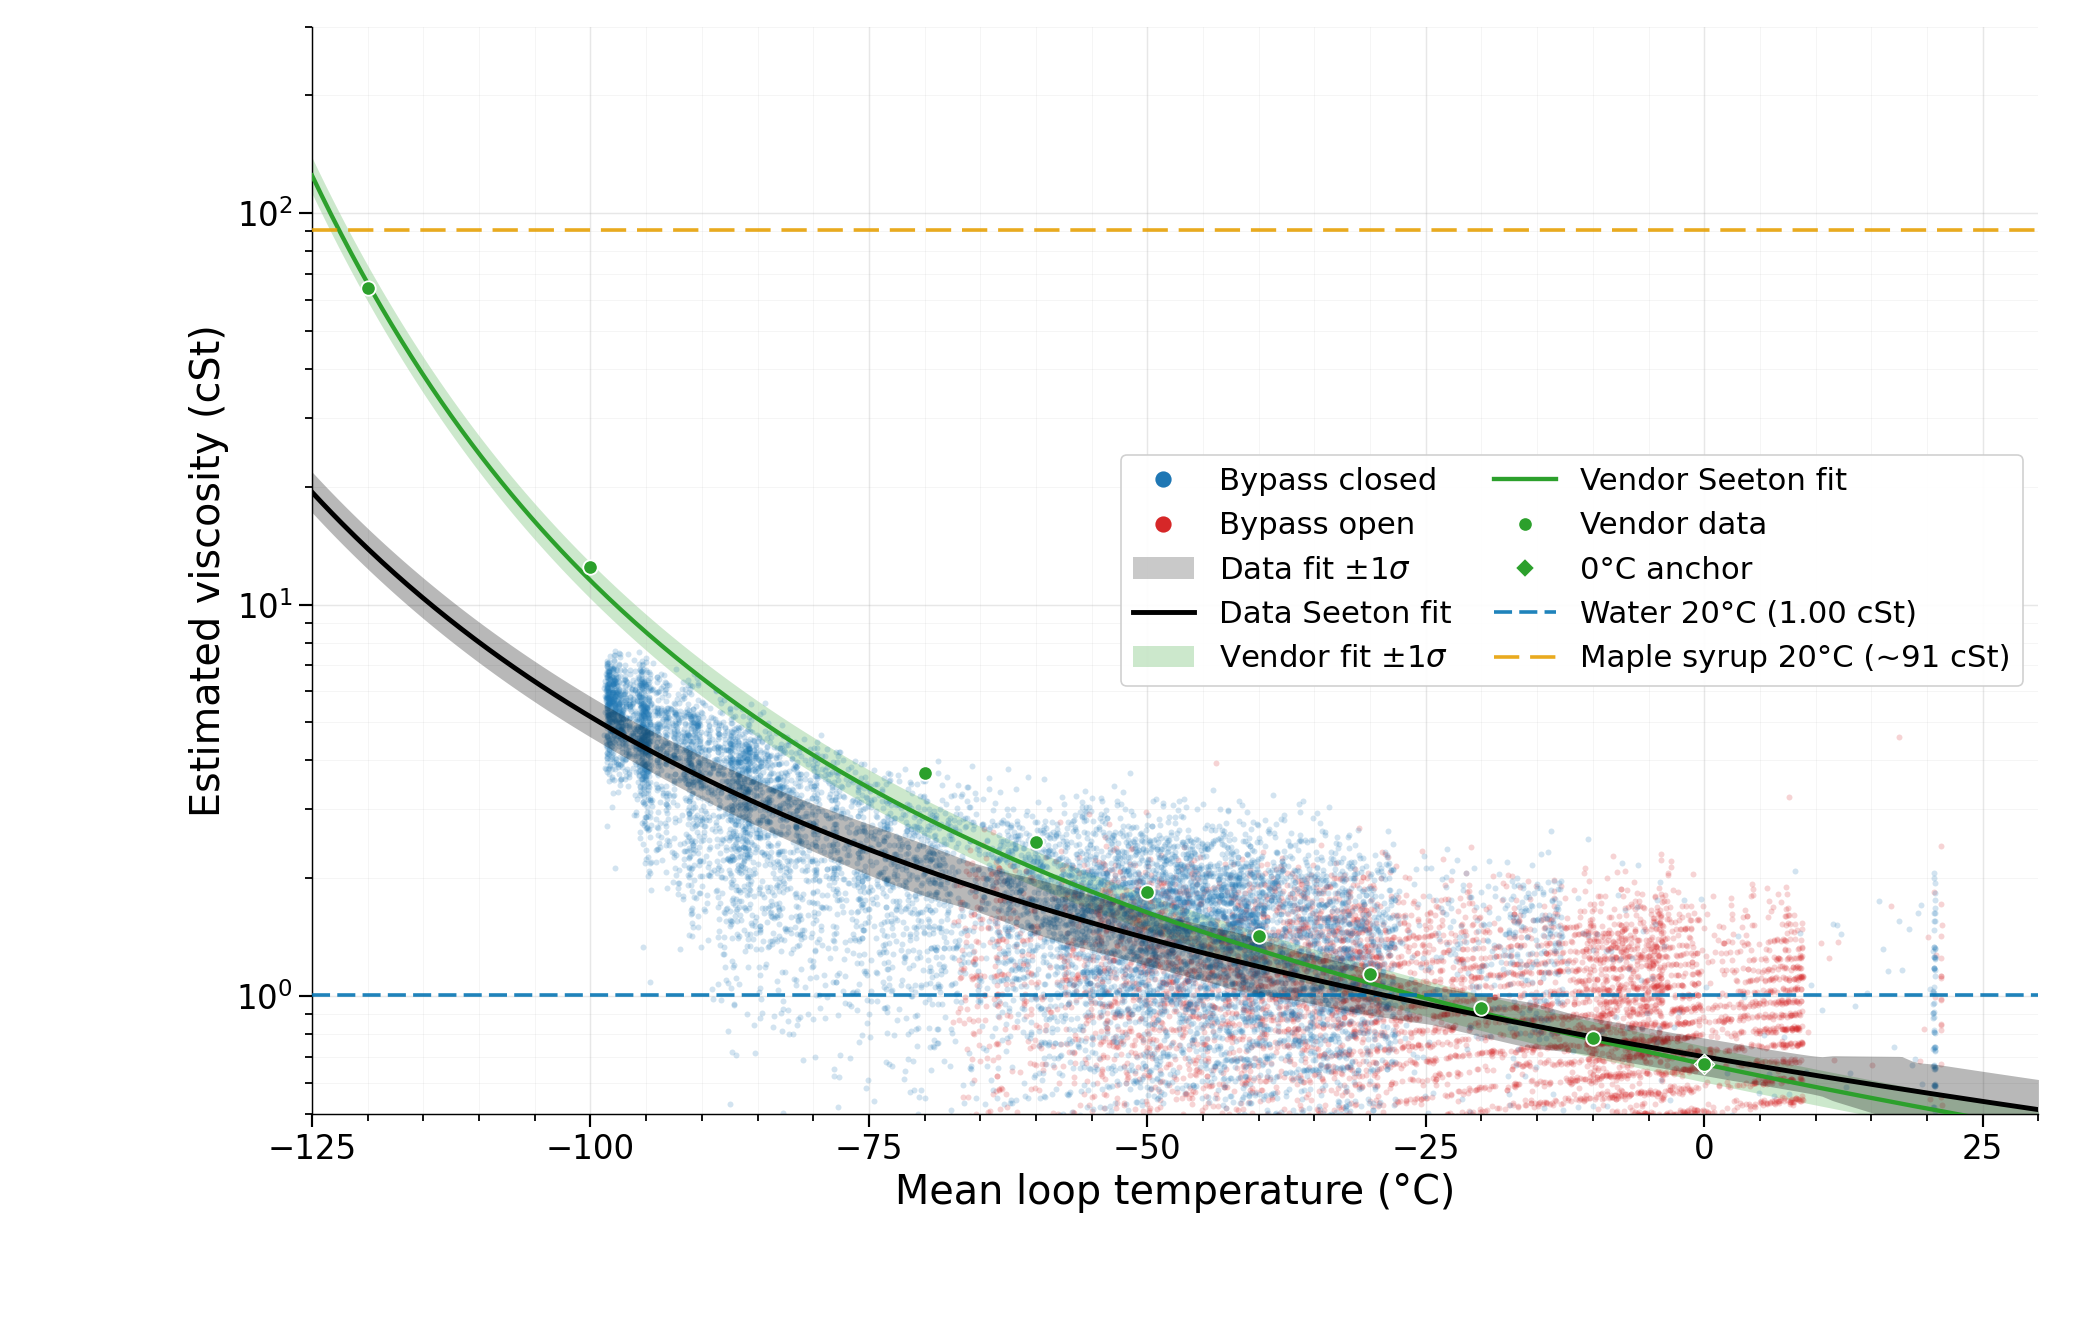

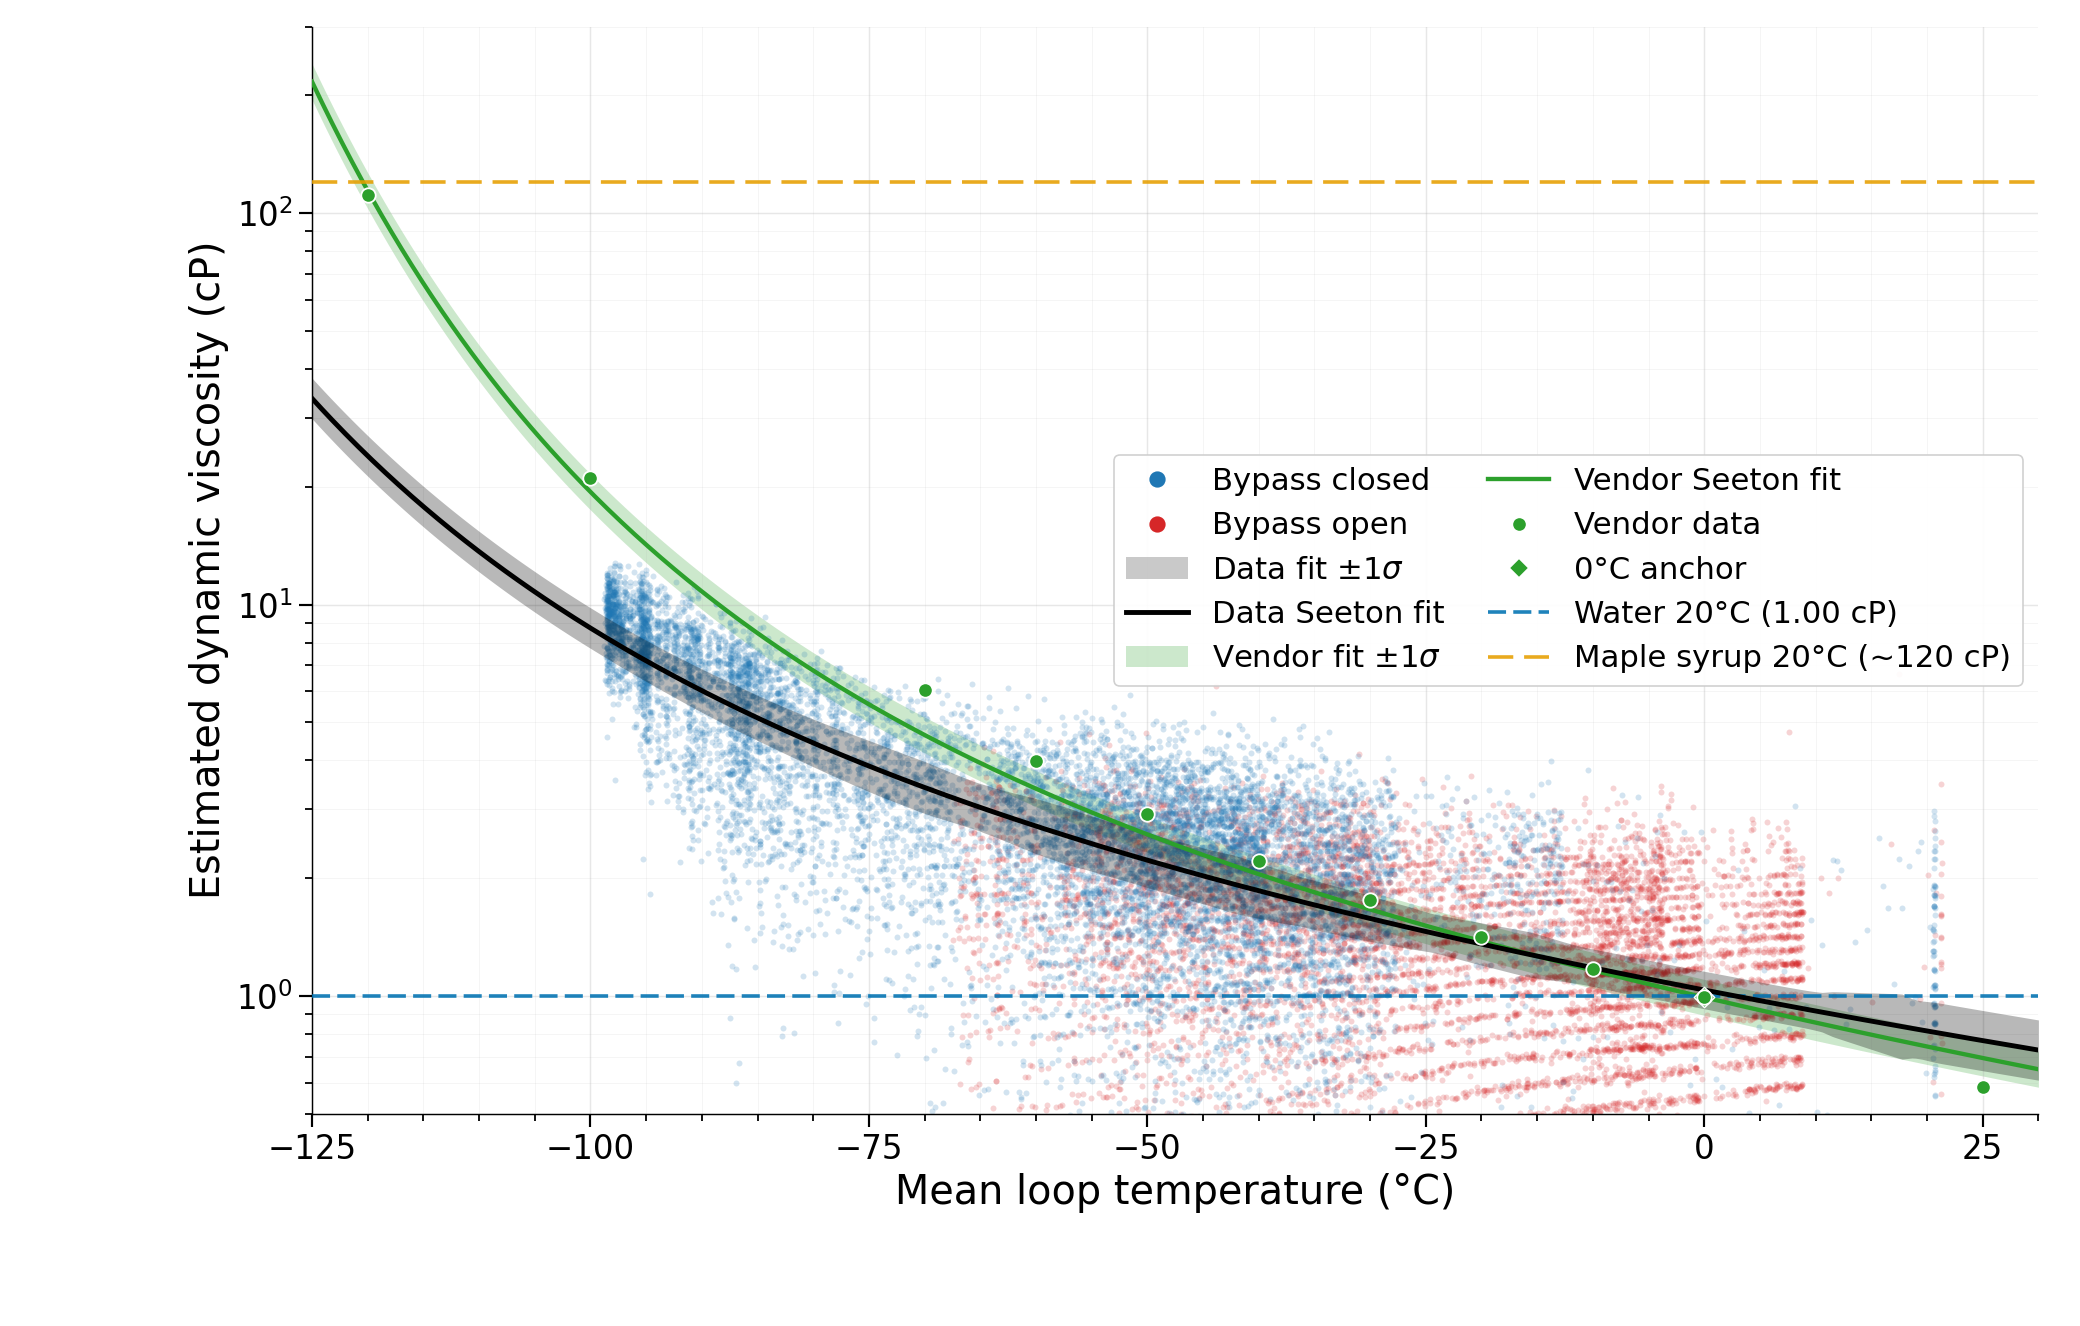

In [6]:
VISCOSITY_FLOW_CORRECTION_BIN_WIDTH_C = 5.0
VISCOSITY_FLOW_CORRECTION_MIN_GROUP_SAMPLES = 5
VISCOSITY_FLOW_CORRECTION_MIN_R2 = 0.55
VISCOSITY_ROLLING_HALF_WIDTH_C = 3.0
VISCOSITY_ROLLING_MIN_SAMPLES = 60
VISCOSITY_SEETON_FIT_BIN_WIDTH_C = 1.0
VISCOSITY_MIN_DELTA_P_BAR = 0.02
VISCOSITY_MIN_FLOW_LMIN = 0.05
VISCOSITY_MIN_PUMP_SPEED_RPM = 180.0
VISCOSITY_ANCHOR_TEMPERATURE_C = 0.0
VISCOSITY_ANCHOR_KINEMATIC_CST = 0.67
VISCOSITY_ANCHOR_HALF_WIDTH_C = 5.0
VISCOSITY_ANCHOR_MIN_SAMPLES = 10
VISCOSITY_ANCHOR_DENSITY_KG_M3 = float(hfe7200_density_kg_m3(VISCOSITY_ANCHOR_TEMPERATURE_C))
VISCOSITY_LATEST_RUN_KEYS = tuple(POWER_RUN_KEYS)

VISCOSITY_LABEL_FONTSIZE = 22
VISCOSITY_TICK_FONTSIZE = 18
VISCOSITY_LEGEND_FONTSIZE = 17
VISCOSITY_SCATTER_SIZE = 10.0
VISCOSITY_SCATTER_ALPHA = 0.20
VISCOSITY_ROLLING_LINEWIDTH = 2.7
VISCOSITY_BAND_EDGE_LINEWIDTH = 0.9
VISCOSITY_BAND_EDGE_ALPHA = 0.70
VISCOSITY_SPREAD_ALPHA = 0.14
VISCOSITY_SPREAD_BAND_LEGEND_ALPHA = 0.48
VISCOSITY_MEAN_BAND_ALPHA = 0.28
VISCOSITY_MIN_LOG_READING_SIGMA = 1.0e-4
VISCOSITY_LOG_YMIN = 0.5

VISCOSITY_LOG_YMAX = 300.0

VISCOSITY_TEMPERATURE_XLIM_C = (-125.0, 30.0)

VISCOSITY_TEMPERATURE_XTICKS_C = [-125, -100, -75, -50, -25, 0, 25]
VISCOSITY_FIGURE_ADJUST = dict(left=0.15, right=0.98, top=0.98, bottom=0.16)
VISCOSITY_STATE_MARKER = 'o'
VISCOSITY_STATE_COLORS = {'closed': '#1f77b4', 'open': '#d62728', 'not specified': '0.45'}
VISCOSITY_STATE_LABELS = {'closed': 'Bypass closed', 'open': 'Bypass open', 'not specified': 'Bypass not specified'}
VISCOSITY_STATE_SCATTER_SIZE = {'closed': 11.0, 'open': 11.0, 'not specified': 10.0}
VISCOSITY_STATE_SCATTER_ALPHA = {'closed': 0.20, 'open': 0.20, 'not specified': 0.17}
VISCOSITY_STATE_ZORDER = {'open': 1.4, 'not specified': 1.6, 'closed': 1.9}
VISCOSITY_VENDOR_COLOR = '#2ca02c'
VISCOSITY_REFERENCE_LINEWIDTH = 2.0
VISCOSITY_REFERENCE_ALPHA = 0.88
# Room-temperature reference fluids are plotted in cSt to match the HFE kinematic-viscosity axis.
# Water uses ISO/TR 3666:1998 at 20 C; maple syrup is a presentation reference value at 20 C.
MAPLE_SYRUP_20C_DYNAMIC_CP = 120.0
MAPLE_SYRUP_20C_DENSITY_G_ML = 1.325
VISCOSITY_REFERENCE_FLUIDS = [
    {
        'label': 'Water 20°C (1.00 cSt)',
        'kinematic_cSt': 1.0034,
        'color': '#0072B2',
        'linestyle': (0, (5, 2)),
    },
    {
        'label': 'Maple syrup 20°C (~91 cSt)',
        'kinematic_cSt': MAPLE_SYRUP_20C_DYNAMIC_CP / MAPLE_SYRUP_20C_DENSITY_G_ML,
        'color': '#E69F00',
        'linestyle': (0, (7, 3)),
    },
]
VISCOSITY_DYNAMIC_REFERENCE_FLUIDS = [
    {
        'label': 'Water 20°C (1.00 cP)',
        'dynamic_cP': 1.0016,
        'color': '#0072B2',
        'linestyle': (0, (5, 2)),
    },
    {
        'label': 'Maple syrup 20°C (~120 cP)',
        'dynamic_cP': MAPLE_SYRUP_20C_DYNAMIC_CP,
        'color': '#E69F00',
        'linestyle': (0, (7, 3)),
    },
]

VISCOSITY_ANCHOR_COLOR = VISCOSITY_VENDOR_COLOR
VISCOSITY_VENDOR_BAND_ALPHA = 0.24
VISCOSITY_VENDOR_MARKER_SIZE = 64.0
VISCOSITY_VENDOR_MARKER_EDGEWIDTH = 1.0
VISCOSITY_DEFAULT_FLOW_COEFFICIENT_STATE = 'closed'

VISCOSITY_FLOW_COEFFICIENT_WINDOWS = [
    {
        'label': 'Apr 22 closed speed sweep, -60 to -40 deg C',
        'log_key': '0422',
        'bypass_state': 'closed',
        'coefficient_state': 'closed',
        'temperature_min_C': -60.0,
        'temperature_max_C': -40.0,
        'use_for_model': True,
    },
    {
        'label': 'Apr 22 open speed sweep, -5 to 0 deg C',
        'log_key': '0422',
        'bypass_state': 'open',
        'coefficient_state': 'open',
        'temperature_min_C': -5.0,
        'temperature_max_C': 0.0,
        'use_for_model': True,
    },
    {
        'label': 'Apr 24 closed diagnostic, -100 to -95 deg C',
        'log_key': '0424',
        'bypass_state': 'closed',
        'coefficient_state': 'closed',
        'temperature_min_C': -100.0,
        'temperature_max_C': -95.0,
        'use_for_model': False,
    },
]


viscosity_latest_recirculation_samples = plot04b_samples.loc[
    plot04b_samples['log_key'].isin(VISCOSITY_LATEST_RUN_KEYS)
].copy()


def viscosity_proxy_basis(frame: pd.DataFrame, bypass_states: tuple[str, ...] | None = ('closed',)) -> pd.DataFrame:
    required_columns = [
        'TMI_C',
        'delta_p_bar_plot',
        'volume_flow_lmin_si',
        'density_kg_m3_si',
        'pump_speed_rpm',
        'bypass_state',
        'cmd_bucket_pct',
        'log_key',
    ]
    work = frame.dropna(subset=required_columns).copy()
    if bypass_states is not None:
        work = work.loc[work['bypass_state'].isin(bypass_states)].copy()
    work = work.loc[
        work['pump_speed_rpm'].ge(VISCOSITY_MIN_PUMP_SPEED_RPM)
        & work['delta_p_bar_plot'].gt(VISCOSITY_MIN_DELTA_P_BAR)
        & work['volume_flow_lmin_si'].gt(VISCOSITY_MIN_FLOW_LMIN)
        & work['density_kg_m3_si'].gt(0.0)
    ].copy()
    work['total_resistance_bar_per_lmin'] = work['delta_p_bar_plot'] / work['volume_flow_lmin_si']
    work['density_flow_kg_m3_lmin'] = work['density_kg_m3_si'] * work['volume_flow_lmin_si']
    bin_edges = np.arange(-105.0, 30.0 + VISCOSITY_FLOW_CORRECTION_BIN_WIDTH_C, VISCOSITY_FLOW_CORRECTION_BIN_WIDTH_C)
    work['flow_correction_tmi_bin'] = pd.cut(work['TMI_C'], bins=bin_edges, include_lowest=True)
    work = work.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['total_resistance_bar_per_lmin', 'density_flow_kg_m3_lmin', 'flow_correction_tmi_bin']
    )
    if work.empty:
        state_label = 'all bypass states' if bypass_states is None else ', '.join(bypass_states)
        raise RuntimeError(f'No viscosity-proxy samples were retained for {state_label}.')
    return work


def rolling_window_mean_sem_std(value, left, right, n):
    cumulative = np.concatenate([[0.0], np.cumsum(value)])
    cumulative_sq = np.concatenate([[0.0], np.cumsum(value * value)])
    sum_y = cumulative[right] - cumulative[left]
    sum_y2 = cumulative_sq[right] - cumulative_sq[left]
    with np.errstate(invalid='ignore', divide='ignore'):
        mean = sum_y / n
        sample_variance = (sum_y2 - (sum_y * sum_y) / n) / np.maximum(n - 1, 1)
        sample_std = np.sqrt(np.clip(sample_variance, 0.0, None))
        sem = sample_std / np.sqrt(np.maximum(n, 1))
    return mean, sem, sample_std


def viscosity_proxy_rolling_curve(
    work: pd.DataFrame,
    proxy_column: str,
    *,
    temperature_column: str = 'TMI_C',
    half_width_c: float = VISCOSITY_ROLLING_HALF_WIDTH_C,
    min_samples: int = VISCOSITY_ROLLING_MIN_SAMPLES,
    uncertainty_derivative_column: str | None = None,
    uncertainty_group_column: str | None = None,
    uncertainty_sigma_by_group: dict[str, float] | None = None,
) -> pd.DataFrame:
    required_columns = [temperature_column, proxy_column]
    if uncertainty_derivative_column is not None:
        required_columns.append(uncertainty_derivative_column)
    if uncertainty_group_column is not None:
        required_columns.append(uncertainty_group_column)

    rolling_basis = work[required_columns].dropna(subset=[temperature_column, proxy_column]).copy()
    rolling_basis = rolling_basis.loc[rolling_basis[proxy_column].gt(0.0)].copy()
    if rolling_basis.empty:
        return pd.DataFrame(columns=[
            'temperature_C', 'proxy_mean', 'proxy_sigma', 'proxy_std',
            'proxy_sem', 'proxy_cstate_sigma', 'sample_count',
        ])

    temperature = rolling_basis[temperature_column].to_numpy(float)
    value = rolling_basis[proxy_column].to_numpy(float)
    order = np.argsort(temperature)
    temperature = temperature[order]
    value = value[order]
    eval_temperature = np.unique(temperature)

    left = np.searchsorted(temperature, eval_temperature - float(half_width_c), side='left')
    right = np.searchsorted(temperature, eval_temperature + float(half_width_c), side='right')
    sample_count = right - left
    proxy_mean, proxy_sem, proxy_std = rolling_window_mean_sem_std(value, left, right, sample_count)

    cstate_sigma = np.zeros_like(proxy_sem)
    if (
        uncertainty_derivative_column is not None
        and uncertainty_group_column is not None
        and uncertainty_sigma_by_group
    ):
        derivative = pd.to_numeric(rolling_basis[uncertainty_derivative_column], errors='coerce').to_numpy(float)[order]
        groups = rolling_basis[uncertainty_group_column].astype(str).to_numpy()[order]
        cstate_variance = np.zeros_like(proxy_sem)
        for group_name, group_sigma in uncertainty_sigma_by_group.items():
            sigma = float(group_sigma)
            if not np.isfinite(sigma) or sigma <= 0.0:
                continue
            group_derivative = np.where(groups == str(group_name), derivative, 0.0)
            group_derivative = np.where(np.isfinite(group_derivative), group_derivative, 0.0)
            cumulative = np.concatenate([[0.0], np.cumsum(group_derivative)])
            derivative_sum = cumulative[right] - cumulative[left]
            with np.errstate(invalid='ignore', divide='ignore'):
                mean_derivative = derivative_sum / np.maximum(sample_count, 1)
            cstate_variance += (mean_derivative * sigma) ** 2
        cstate_sigma = np.sqrt(np.clip(cstate_variance, 0.0, None))

    proxy_sigma = np.sqrt(proxy_sem ** 2 + cstate_sigma ** 2)
    curve = pd.DataFrame({
        'temperature_C': eval_temperature,
        'proxy_mean': proxy_mean,
        'proxy_sigma': proxy_sigma,
        'proxy_std': proxy_std,
        'proxy_sem': proxy_sem,
        'proxy_cstate_sigma': cstate_sigma,
        'sample_count': sample_count,
    })
    curve = curve.loc[curve['sample_count'].ge(int(min_samples)) & curve['proxy_mean'].gt(0.0)].copy()
    if len(curve) < 3:
        raise RuntimeError(f'Not enough rolling viscosity-proxy points for {proxy_column}.')
    return curve.reset_index(drop=True)


def fit_flow_coefficient_window(work: pd.DataFrame, window: dict[str, object]) -> pd.DataFrame:
    selected = work.loc[
        work['log_key'].eq(str(window['log_key']))
        & work['bypass_state'].eq(str(window['bypass_state']))
        & work['TMI_C'].between(float(window['temperature_min_C']), float(window['temperature_max_C']))
    ].copy()
    if selected.empty:
        return pd.DataFrame()

    grouped = (
        selected.groupby(['flow_correction_tmi_bin', 'cmd_bucket_pct'], observed=True)
        .agg(
            group_sample_count=('total_resistance_bar_per_lmin', 'size'),
            temperature_C=('TMI_C', 'median'),
            temperature_min_C=('TMI_C', 'min'),
            temperature_max_C=('TMI_C', 'max'),
            total_resistance_bar_per_lmin=('total_resistance_bar_per_lmin', 'median'),
            density_flow_kg_m3_lmin=('density_flow_kg_m3_lmin', 'median'),
            flow_lmin=('volume_flow_lmin_si', 'median'),
            delta_p_bar=('delta_p_bar_plot', 'median'),
            pump_speed_rpm=('pump_speed_rpm', 'median'),
        )
        .reset_index()
    )
    grouped = grouped.loc[grouped['group_sample_count'].ge(VISCOSITY_FLOW_CORRECTION_MIN_GROUP_SAMPLES)].copy()
    rows = []
    for tmi_bin, group in grouped.groupby('flow_correction_tmi_bin', observed=True):
        if len(group) < 3 or group['density_flow_kg_m3_lmin'].nunique() < 3:
            continue
        x = group['density_flow_kg_m3_lmin'].to_numpy(float)
        y = group['total_resistance_bar_per_lmin'].to_numpy(float)
        slope, intercept = np.polyfit(x, y, 1)
        predicted = slope * x + intercept
        residual = y - predicted
        ss_res = float(np.sum(residual ** 2))
        ss_tot = float(np.sum((y - y.mean()) ** 2))
        x_centered = x - float(x.mean())
        x_denom = float(np.sum(x_centered ** 2))
        dof = max(len(x) - 2, 0)
        residual_std = np.sqrt(ss_res / dof) if dof > 0 else np.nan
        slope_sigma = residual_std / np.sqrt(x_denom) if dof > 0 and x_denom > 0.0 else np.nan
        intercept_sigma = (
            residual_std * np.sqrt(1.0 / len(x) + float(x.mean()) ** 2 / x_denom)
            if dof > 0 and x_denom > 0.0 else np.nan
        )
        rows.append({
            'window_label': str(window['label']),
            'log_key': str(window['log_key']),
            'bypass_state': str(window['bypass_state']),
            'coefficient_state': str(window['coefficient_state']),
            'use_for_model': bool(window['use_for_model']),
            'tmi_bin': tmi_bin,
            'temperature_C': float(group['temperature_C'].median()),
            'temperature_min_C': float(group['temperature_min_C'].min()),
            'temperature_max_C': float(group['temperature_max_C'].max()),
            'slope_bar_per_lmin_per_density_flow': float(slope),
            'slope_sigma_bar_per_lmin_per_density_flow': float(slope_sigma),
            'intercept_bar_per_lmin': float(intercept),
            'intercept_sigma_bar_per_lmin': float(intercept_sigma),
            'group_count': int(len(group)),
            'sample_count': int(group['group_sample_count'].sum()),
            'cmd_values': ', '.join(str(int(value)) for value in sorted(group['cmd_bucket_pct'].dropna().unique())),
            'r2': 1.0 - ss_res / ss_tot if ss_tot > 0.0 else np.nan,
        })
    return pd.DataFrame(rows)


def fit_flow_coefficient_windows(work: pd.DataFrame) -> pd.DataFrame:
    frames = [fit_flow_coefficient_window(work, window) for window in VISCOSITY_FLOW_COEFFICIENT_WINDOWS]
    frames = [frame for frame in frames if not frame.empty]
    if not frames:
        raise RuntimeError('No local speed-sweep windows produced a flow correction coefficient.')
    return pd.concat(frames, ignore_index=True)


def summarize_flow_coefficients(fit_diagnostics: pd.DataFrame) -> pd.DataFrame:
    valid = fit_diagnostics.loc[
        fit_diagnostics['use_for_model']
        & fit_diagnostics['slope_bar_per_lmin_per_density_flow'].gt(0.0)
        & fit_diagnostics['r2'].ge(VISCOSITY_FLOW_CORRECTION_MIN_R2)
    ].copy()
    if valid.empty:
        raise RuntimeError('No selected local speed-sweep fits passed the flow correction quality cuts.')

    rows = []
    for state, group in valid.groupby('coefficient_state', sort=True):
        slopes = group['slope_bar_per_lmin_per_density_flow'].to_numpy(float)
        weights = group['sample_count'].to_numpy(float)
        coefficient = float(np.average(slopes, weights=weights))
        weight_sum = float(np.sum(weights))
        normalized_weights = weights / weight_sum if weight_sum > 0.0 else np.full_like(weights, 1.0 / len(weights))

        slope_sigma = pd.to_numeric(
            group.get('slope_sigma_bar_per_lmin_per_density_flow', pd.Series(np.nan, index=group.index)),
            errors='coerce',
        ).to_numpy(float)
        slope_sigma = np.where(np.isfinite(slope_sigma) & (slope_sigma > 0.0), slope_sigma, 0.0)
        fit_sigma_component = float(np.sqrt(np.sum((normalized_weights * slope_sigma) ** 2)))

        effective_n = weight_sum ** 2 / float(np.sum(weights ** 2)) if np.sum(weights ** 2) > 0.0 else float(len(weights))
        if len(slopes) > 1 and effective_n > 1.0:
            weighted_variance = float(np.average((slopes - coefficient) ** 2, weights=weights))
            between_window_sigma = float(np.sqrt(weighted_variance / effective_n))
        else:
            between_window_sigma = 0.0
        coefficient_sigma = float(np.hypot(fit_sigma_component, between_window_sigma))
        rows.append({
            'coefficient_state': state,
            'flow_coefficient': coefficient,
            'flow_coefficient_sigma': coefficient_sigma,
            'fit_sigma_component': fit_sigma_component,
            'between_window_sigma': between_window_sigma,
            'effective_fit_count': effective_n,
            'fit_count': int(len(group)),
            'sample_count': int(group['sample_count'].sum()),
            'temperature_min_C': float(group['temperature_min_C'].min()),
            'temperature_max_C': float(group['temperature_max_C'].max()),
            'mean_r2': float(np.average(group['r2'], weights=group['sample_count'])),
            'source': '; '.join(group['window_label'].drop_duplicates()),
        })
    summary = pd.DataFrame(rows)
    if VISCOSITY_DEFAULT_FLOW_COEFFICIENT_STATE not in set(summary['coefficient_state']):
        raise RuntimeError(f'Missing default {VISCOSITY_DEFAULT_FLOW_COEFFICIENT_STATE} flow correction coefficient.')
    return summary


viscosity_flow_basis_all_states = viscosity_proxy_basis(
    viscosity_latest_recirculation_samples,
    bypass_states=None,
)
viscosity_flow_coefficient_fit_diagnostics = fit_flow_coefficient_windows(viscosity_flow_basis_all_states)
viscosity_flow_coefficient_summary = summarize_flow_coefficients(viscosity_flow_coefficient_fit_diagnostics)
viscosity_flow_coefficient_by_state = dict(zip(
    viscosity_flow_coefficient_summary['coefficient_state'],
    viscosity_flow_coefficient_summary['flow_coefficient'],
))
viscosity_flow_coefficient_sigma_by_state = dict(zip(
    viscosity_flow_coefficient_summary['coefficient_state'],
    viscosity_flow_coefficient_summary['flow_coefficient_sigma'],
))
viscosity_default_flow_coefficient = viscosity_flow_coefficient_by_state[VISCOSITY_DEFAULT_FLOW_COEFFICIENT_STATE]
viscosity_default_flow_coefficient_sigma = viscosity_flow_coefficient_sigma_by_state.get(
    VISCOSITY_DEFAULT_FLOW_COEFFICIENT_STATE,
    0.0,
)


def corrected_viscosity_samples(
    frame: pd.DataFrame,
    bypass_states: tuple[str, ...] | None,
    *,
    flow_coefficient_by_state: dict[str, float] | None = None,
    flow_coefficient_sigma_by_state: dict[str, float] | None = None,
) -> pd.DataFrame:
    work = viscosity_proxy_basis(frame, bypass_states=bypass_states)
    coefficient_by_state = viscosity_flow_coefficient_by_state if flow_coefficient_by_state is None else flow_coefficient_by_state
    coefficient_sigma_by_state = (
        viscosity_flow_coefficient_sigma_by_state
        if flow_coefficient_sigma_by_state is None
        else flow_coefficient_sigma_by_state
    )
    default_coefficient = coefficient_by_state.get(
        VISCOSITY_DEFAULT_FLOW_COEFFICIENT_STATE,
        viscosity_default_flow_coefficient,
    )
    default_coefficient_sigma = coefficient_sigma_by_state.get(
        VISCOSITY_DEFAULT_FLOW_COEFFICIENT_STATE,
        viscosity_default_flow_coefficient_sigma,
    )
    state_key = work['bypass_state'].astype(str)
    coefficient = state_key.map(coefficient_by_state).astype(float)
    coefficient = coefficient.fillna(default_coefficient)
    coefficient_sigma = state_key.map(coefficient_sigma_by_state).astype(float)
    coefficient_sigma = coefficient_sigma.fillna(default_coefficient_sigma)
    work['flow_correction_coefficient'] = coefficient
    work['flow_correction_coefficient_sigma'] = coefficient_sigma
    work['flow_dependent_resistance_bar_per_lmin'] = coefficient * work['density_flow_kg_m3_lmin']
    work['viscous_resistance_bar_per_lmin'] = (
        work['total_resistance_bar_per_lmin'] - work['flow_dependent_resistance_bar_per_lmin']
    )
    return work.loc[work['viscous_resistance_bar_per_lmin'].gt(0.0)].copy()


def viscosity_reference_proxy_from_band(
    work: pd.DataFrame,
    *,
    anchor_temperature_C: float,
    anchor_kinematic_cSt: float,
    half_width_C: float,
    min_samples: int,
    source_label: str,
    value_column: str = 'viscous_resistance_bar_per_lmin',
    temperature_column: str = 'TMI_C',
) -> tuple[float, pd.Series, pd.DataFrame]:
    anchor_samples = work.loc[
        work[temperature_column].between(anchor_temperature_C - half_width_C, anchor_temperature_C + half_width_C)
        & work[value_column].gt(0.0)
    ].copy()
    if len(anchor_samples) < int(min_samples):
        raise RuntimeError(
            f'Only {len(anchor_samples)} samples found for {source_label}; need at least {min_samples}.'
        )
    reference_value = float(anchor_samples[value_column].median())
    reference_row = pd.Series({
        'reference_temperature_C': float(anchor_samples[temperature_column].median()),
        'reference_value': reference_value,
        'reference_sample_count': int(len(anchor_samples)),
        'reference_mean': float(anchor_samples[value_column].mean()),
        'reference_std': float(anchor_samples[value_column].std(ddof=1)) if len(anchor_samples) > 1 else np.nan,
        'reference_sem': float(anchor_samples[value_column].std(ddof=1) / np.sqrt(len(anchor_samples))) if len(anchor_samples) > 1 else np.nan,
        'reference_anchor_temperature_C': float(anchor_temperature_C),
        'reference_anchor_kinematic_cSt': float(anchor_kinematic_cSt),
        'reference_band_half_width_C': float(half_width_C),
        'reference_source': source_label,
    })
    return reference_value, reference_row, anchor_samples


def viscosity_anchor_proxy_from_samples(
    work: pd.DataFrame,
    *,
    value_column: str = 'viscous_resistance_bar_per_lmin',
    temperature_column: str = 'TMI_C',
) -> tuple[float, pd.Series, pd.DataFrame]:
    return viscosity_reference_proxy_from_band(
        work,
        anchor_temperature_C=VISCOSITY_ANCHOR_TEMPERATURE_C,
        anchor_kinematic_cSt=VISCOSITY_ANCHOR_KINEMATIC_CST,
        half_width_C=VISCOSITY_ANCHOR_HALF_WIDTH_C,
        min_samples=VISCOSITY_ANCHOR_MIN_SAMPLES,
        source_label='sample median within anchor band',
        value_column=value_column,
        temperature_column=temperature_column,
    )


def apply_kinematic_viscosity_scale(
    samples: pd.DataFrame,
    reference_proxy: float,
    *,
    anchor_temperature_C: float,
    anchor_kinematic_cSt: float,
) -> pd.DataFrame:
    if reference_proxy <= 0.0:
        raise ValueError('reference_proxy must be positive.')
    anchor_density_kg_m3 = float(hfe7200_density_kg_m3(anchor_temperature_C))
    samples = samples.copy()
    viscosity_scale = (
        float(anchor_kinematic_cSt)
        * anchor_density_kg_m3
        / samples['density_kg_m3_si']
        / float(reference_proxy)
    )
    samples['estimated_viscosity_cSt'] = viscosity_scale * samples['viscous_resistance_bar_per_lmin']
    return samples


def viscosity_summary_from_samples(samples: pd.DataFrame, *, temperature_column: str) -> pd.DataFrame:
    return viscosity_proxy_rolling_curve(
        samples,
        'estimated_viscosity_cSt',
        temperature_column=temperature_column,
    ).rename(columns={
        'proxy_mean': 'viscosity_mean_cSt',
        'proxy_sigma': 'viscosity_sigma_cSt',
        'proxy_std': 'viscosity_std_cSt',
        'proxy_sem': 'viscosity_sem_cSt',
        'proxy_cstate_sigma': 'viscosity_cstate_sigma_cSt',
    })


def interpolate_viscosity_summary_mean(summary: pd.DataFrame, temperature_C: np.ndarray) -> np.ndarray:
    work = summary[['temperature_C', 'viscosity_mean_cSt']].dropna().sort_values('temperature_C')
    work = work.groupby('temperature_C', as_index=False)['viscosity_mean_cSt'].mean()
    if work.empty:
        return np.full_like(np.asarray(temperature_C, dtype=float), np.nan, dtype=float)
    return np.interp(
        np.asarray(temperature_C, dtype=float),
        work['temperature_C'].to_numpy(float),
        work['viscosity_mean_cSt'].to_numpy(float),
        left=np.nan,
        right=np.nan,
    )


def viscosity_summary_for_flow_coefficients(
    frame: pd.DataFrame,
    *,
    bypass_states: tuple[str, ...] | None,
    flow_coefficient_by_state: dict[str, float],
    flow_coefficient_sigma_by_state: dict[str, float],
    temperature_column: str,
    anchor_temperature_C: float,
    anchor_kinematic_cSt: float,
    reference_proxy_override: float | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, float, pd.Series, pd.DataFrame]:
    samples = corrected_viscosity_samples(
        frame,
        bypass_states=bypass_states,
        flow_coefficient_by_state=flow_coefficient_by_state,
        flow_coefficient_sigma_by_state=flow_coefficient_sigma_by_state,
    )
    if temperature_column not in samples.columns:
        raise KeyError(f'Missing temperature column {temperature_column!r}.')
    samples = samples.dropna(subset=[temperature_column]).copy()
    if samples.empty:
        raise RuntimeError(f'No viscosity samples have finite {temperature_column}.')

    if reference_proxy_override is None:
        reference_proxy, reference_row, reference_samples = viscosity_anchor_proxy_from_samples(
            samples,
            temperature_column=temperature_column,
        )
    else:
        reference_proxy = float(reference_proxy_override)
        reference_row = pd.Series({
            'reference_temperature_C': float(anchor_temperature_C),
            'reference_value': reference_proxy,
            'reference_sample_count': np.nan,
            'reference_mean': np.nan,
            'reference_std': np.nan,
            'reference_sem': np.nan,
            'reference_anchor_temperature_C': float(anchor_temperature_C),
            'reference_anchor_kinematic_cSt': float(anchor_kinematic_cSt),
            'reference_band_half_width_C': np.nan,
            'reference_source': 'provided reference proxy',
        })
        reference_samples = pd.DataFrame()

    samples = apply_kinematic_viscosity_scale(
        samples,
        reference_proxy,
        anchor_temperature_C=anchor_temperature_C,
        anchor_kinematic_cSt=anchor_kinematic_cSt,
    )
    summary = viscosity_summary_from_samples(samples, temperature_column=temperature_column)
    return samples, summary, reference_proxy, reference_row, reference_samples


def cstate_uncertainty_from_finite_difference(
    frame: pd.DataFrame,
    *,
    nominal_summary: pd.DataFrame,
    bypass_states: tuple[str, ...] | None,
    flow_coefficient_by_state: dict[str, float],
    flow_coefficient_sigma_by_state: dict[str, float],
    temperature_column: str,
    anchor_temperature_C: float,
    anchor_kinematic_cSt: float,
    reference_proxy_override: float | None = None,
) -> np.ndarray:
    nominal_temperature = nominal_summary['temperature_C'].to_numpy(float)
    nominal_mean = nominal_summary['viscosity_mean_cSt'].to_numpy(float)
    variance = np.zeros_like(nominal_mean, dtype=float)

    zero_sigma_by_state = {state: 0.0 for state in flow_coefficient_by_state}
    for state, sigma in flow_coefficient_sigma_by_state.items():
        sigma = float(sigma)
        if state not in flow_coefficient_by_state or not np.isfinite(sigma) or sigma <= 0.0:
            continue
        coefficient = float(flow_coefficient_by_state[state])
        plus_coefficients = dict(flow_coefficient_by_state)
        minus_coefficients = dict(flow_coefficient_by_state)
        plus_coefficients[state] = coefficient + sigma
        minus_coefficients[state] = max(coefficient - sigma, 0.0)

        _, plus_summary, *_ = viscosity_summary_for_flow_coefficients(
            frame,
            bypass_states=bypass_states,
            flow_coefficient_by_state=plus_coefficients,
            flow_coefficient_sigma_by_state=zero_sigma_by_state,
            temperature_column=temperature_column,
            anchor_temperature_C=anchor_temperature_C,
            anchor_kinematic_cSt=anchor_kinematic_cSt,
            reference_proxy_override=reference_proxy_override,
        )
        _, minus_summary, *_ = viscosity_summary_for_flow_coefficients(
            frame,
            bypass_states=bypass_states,
            flow_coefficient_by_state=minus_coefficients,
            flow_coefficient_sigma_by_state=zero_sigma_by_state,
            temperature_column=temperature_column,
            anchor_temperature_C=anchor_temperature_C,
            anchor_kinematic_cSt=anchor_kinematic_cSt,
            reference_proxy_override=reference_proxy_override,
        )

        plus_mean = interpolate_viscosity_summary_mean(plus_summary, nominal_temperature)
        minus_mean = interpolate_viscosity_summary_mean(minus_summary, nominal_temperature)
        delta = np.zeros_like(nominal_mean, dtype=float)
        both = np.isfinite(plus_mean) & np.isfinite(minus_mean)
        delta[both] = 0.5 * np.abs(plus_mean[both] - minus_mean[both])
        plus_only = np.isfinite(plus_mean) & ~np.isfinite(minus_mean)
        minus_only = ~np.isfinite(plus_mean) & np.isfinite(minus_mean)
        delta[plus_only] = np.abs(plus_mean[plus_only] - nominal_mean[plus_only])
        delta[minus_only] = np.abs(nominal_mean[minus_only] - minus_mean[minus_only])
        variance += delta ** 2

    return np.sqrt(np.clip(variance, 0.0, None))


def build_kinematic_viscosity_estimate(
    frame: pd.DataFrame,
    *,
    bypass_states: tuple[str, ...] | None,
    label: str,
    reference_proxy_override: float | None = None,
    reference_row_override: pd.Series | None = None,
    flow_coefficient_by_state_override: dict[str, float] | None = None,
    flow_coefficient_sigma_by_state_override: dict[str, float] | None = None,
    anchor_temperature_C: float = VISCOSITY_ANCHOR_TEMPERATURE_C,
    anchor_kinematic_cSt: float = VISCOSITY_ANCHOR_KINEMATIC_CST,
    temperature_column: str = 'TMI_C',
) -> dict[str, object]:
    coefficient_by_state = (
        dict(viscosity_flow_coefficient_by_state)
        if flow_coefficient_by_state_override is None
        else dict(flow_coefficient_by_state_override)
    )
    coefficient_sigma_by_state = (
        dict(viscosity_flow_coefficient_sigma_by_state)
        if flow_coefficient_sigma_by_state_override is None
        else dict(flow_coefficient_sigma_by_state_override)
    )
    samples, summary, reference_proxy, reference_row, reference_samples = viscosity_summary_for_flow_coefficients(
        frame,
        bypass_states=bypass_states,
        flow_coefficient_by_state=coefficient_by_state,
        flow_coefficient_sigma_by_state=coefficient_sigma_by_state,
        temperature_column=temperature_column,
        anchor_temperature_C=anchor_temperature_C,
        anchor_kinematic_cSt=anchor_kinematic_cSt,
        reference_proxy_override=reference_proxy_override,
    )
    if reference_row_override is not None:
        reference_row = reference_row_override.copy()

    reference_row = reference_row.copy()
    reference_row['reference_anchor_temperature_C'] = float(anchor_temperature_C)
    reference_row['reference_anchor_kinematic_cSt'] = float(anchor_kinematic_cSt)

    cstate_sigma = cstate_uncertainty_from_finite_difference(
        frame,
        nominal_summary=summary,
        bypass_states=bypass_states,
        flow_coefficient_by_state=coefficient_by_state,
        flow_coefficient_sigma_by_state=coefficient_sigma_by_state,
        temperature_column=temperature_column,
        anchor_temperature_C=anchor_temperature_C,
        anchor_kinematic_cSt=anchor_kinematic_cSt,
        reference_proxy_override=reference_proxy_override,
    )
    summary = summary.copy()
    summary['viscosity_cstate_sigma_cSt'] = cstate_sigma
    summary['viscosity_sigma_cSt'] = np.sqrt(summary['viscosity_sem_cSt'].to_numpy(float) ** 2 + cstate_sigma ** 2)

    return {
        'label': label,
        'bypass_states': bypass_states,
        'samples': samples,
        'summary': summary,
        'reference_proxy': reference_proxy,
        'reference_row': reference_row,
        'reference_samples': reference_samples,
        'flow_coefficient_by_state': coefficient_by_state,
        'flow_coefficient_sigma_by_state': coefficient_sigma_by_state,
        'temperature_column': temperature_column,
    }

def hfe7200_vendor_kinematic_from_anchor_cst(temperature_c, anchor_temperature_C, anchor_kinematic_cSt):
    raw = hfe7200_kinematic_viscosity_cst(temperature_c)
    raw_anchor = float(hfe7200_kinematic_viscosity_cst(anchor_temperature_C))
    return float(anchor_kinematic_cSt) * raw / raw_anchor


def hfe7200_vendor_kinematic_anchor_cst(temperature_c):
    return hfe7200_vendor_kinematic_from_anchor_cst(
        temperature_c,
        VISCOSITY_ANCHOR_TEMPERATURE_C,
        VISCOSITY_ANCHOR_KINEMATIC_CST,
    )


def rolling_curve_segments(summary: pd.DataFrame, *, gap_c: float = 2.5 * VISCOSITY_ROLLING_HALF_WIDTH_C):
    summary = summary.sort_values('temperature_C').reset_index(drop=True)
    if summary.empty:
        return []
    split_at = np.where(np.diff(summary['temperature_C'].to_numpy(float)) > gap_c)[0] + 1
    return [segment for segment in np.split(summary, split_at) if len(segment)]


def linear_band(center, spread):
    center = np.asarray(center, dtype=float)
    spread = np.asarray(spread, dtype=float)
    lower = np.maximum(center - spread, 0.0)
    upper = np.maximum(center + spread, 0.0)
    return lower, upper


def draw_log_spread_band(ax, temperature_c, center_cst, log_sigma, color, alpha=0.24, zorder=1.0):
    center_cst = np.asarray(center_cst, dtype=float)
    ax.fill_between(
        temperature_c,
        center_cst * np.exp(-log_sigma),
        center_cst * np.exp(log_sigma),
        color=color,
        alpha=alpha,
        linewidth=0.0,
        zorder=zorder,
    )



def rounded_temperature_limits(*values, pad_c: float = 3.0, step_c: float = 5.0, fallback=(-105.0, 25.0)):
    finite_values = []
    for value in values:
        array = np.asarray(value, dtype=float).ravel()
        array = array[np.isfinite(array)]
        if len(array):
            finite_values.append(array)
    if not finite_values:
        return fallback
    combined = np.concatenate(finite_values)
    lower = step_c * np.floor((float(np.nanmin(combined)) - pad_c) / step_c)
    upper = step_c * np.ceil((float(np.nanmax(combined)) + pad_c) / step_c)
    if lower >= upper:
        return fallback
    return float(lower), float(upper)


def set_kinematic_viscosity_ylim(
    ax,
    core_values: list[np.ndarray],
    scatter_values: np.ndarray | None = None,
    *,
    log_scale: bool = False,
):
    finite_core = [np.asarray(values, dtype=float) for values in core_values if len(values)]
    if log_scale:
        finite_core = [values[np.isfinite(values) & (values > 0.0)] for values in finite_core]
    else:
        finite_core = [values[np.isfinite(values) & (values >= 0.0)] for values in finite_core]
    finite_core = [values for values in finite_core if len(values)]
    if not finite_core:
        return
    core = np.concatenate(finite_core)
    upper_candidates = [float(np.nanmax(core))]
    lower_candidates = [float(np.nanmin(core))]
    if scatter_values is not None:
        scatter = np.asarray(scatter_values, dtype=float)
        if log_scale:
            scatter = scatter[np.isfinite(scatter) & (scatter > 0.0)]
        else:
            scatter = scatter[np.isfinite(scatter) & (scatter >= 0.0)]
        if len(scatter):
            upper_candidates.append(float(np.nanpercentile(scatter, 99.5)))
            if log_scale:
                lower_candidates.append(float(np.nanpercentile(scatter, 0.5)))
    upper = max(upper_candidates)
    if log_scale:
        lower = VISCOSITY_LOG_YMIN
        ax.set_ylim(lower, VISCOSITY_LOG_YMAX)
    else:
        ax.set_ylim(0.0, upper * 1.08 if upper > 0.0 else 1.0)


def bypass_state_order(states) -> list[str]:
    observed = {str(state) for state in states}
    preferred = ['closed', 'open', 'not specified']
    return [state for state in preferred if state in observed] + sorted(observed.difference(preferred))


def flow_coefficient_reference_text(flow_coefficient_by_state: dict[str, float] | None = None) -> str:
    coefficient_by_state = viscosity_flow_coefficient_by_state if flow_coefficient_by_state is None else flow_coefficient_by_state
    parts = []
    for state in ['closed', 'open']:
        if state in coefficient_by_state:
            parts.append(f'C_{state} = {coefficient_by_state[state]:.3e}')
    return ', '.join(parts)


def viscosity_temperature_standard_uncertainty_C(temperature_c, temperature_column: str):
    temperature = np.asarray(temperature_c, dtype=float)
    if temperature_column == 'temperature_c_si':
        uncertainty = flow_meter_temperature_standard_uncertainty_C(temperature)
    elif temperature_column == LOOP_MEAN_TEMPERATURE_COL:
        uncertainty = thm_calibration_standard_uncertainty_C(temperature) / np.sqrt(len(LOOP_TC_TEMPERATURE_COLUMNS))
    else:
        uncertainty = thm_calibration_standard_uncertainty_C(temperature)
    return float(uncertainty) if np.ndim(uncertainty) == 0 else uncertainty


def seeton_log_slope_per_C(evaluator, temperature_C, step_C: float = 0.05) -> np.ndarray:
    temperature = np.asarray(temperature_C, dtype=float)
    step = float(step_C)
    upper = evaluator(temperature + step)
    lower = evaluator(temperature - step)
    return (np.log(upper) - np.log(lower)) / (2.0 * step)


def fit_seeton_viscosity_weighted(temperature_c, viscosity_cst, log_sigma):
    temperature_c = np.asarray(temperature_c, dtype=float)
    temperature_k = temperature_c + 273.15
    viscosity_cst = np.asarray(viscosity_cst, dtype=float)
    log_sigma = np.asarray(log_sigma, dtype=float)
    valid = (
        np.isfinite(temperature_c)
        & np.isfinite(temperature_k)
        & np.isfinite(viscosity_cst)
        & np.isfinite(log_sigma)
        & (temperature_k > 0.0)
    )
    valid &= viscosity_cst > 0.0
    valid &= log_sigma > 0.0
    temperature_c = temperature_c[valid]
    temperature_k = temperature_k[valid]
    viscosity_cst = viscosity_cst[valid]
    log_sigma = np.maximum(log_sigma[valid], VISCOSITY_MIN_LOG_READING_SIGMA)
    if len(temperature_c) < 3:
        raise RuntimeError('Need at least three valid points for the weighted Seeton fit.')

    high_start_cst = max(2.0 * float(np.max(viscosity_cst)), 1.0)
    transformed_viscosity = seeton_viscosity_transform(viscosity_cst)
    slope, intercept = np.polyfit(np.log(temperature_k), transformed_viscosity, 1)
    initial_guess = np.array([float(intercept), float(-slope)])

    def fitted_viscosity(params, new_temperature_c=temperature_c):
        coefficient_a, coefficient_b = params
        return evaluate_seeton_viscosity(new_temperature_c, coefficient_a, coefficient_b, high_start_cst)

    def log_residual(params):
        return np.log(fitted_viscosity(params)) - np.log(viscosity_cst)

    def weighted_log_residual(params):
        return log_residual(params) / log_sigma

    result = least_squares(weighted_log_residual, initial_guess)
    coefficient_a, coefficient_b = result.x

    def evaluate(new_temperature_c):
        return evaluate_seeton_viscosity(new_temperature_c, coefficient_a, coefficient_b, high_start_cst)

    residual = np.log(evaluate(temperature_c)) - np.log(viscosity_cst)
    weighted_residual = residual / log_sigma
    dof = max(len(temperature_c) - 2, 1)
    params = {
        'A': float(coefficient_a),
        'B': float(coefficient_b),
        'log_rmse': float(np.sqrt(np.mean(residual ** 2))),
        'weighted_log_rmse': float(np.sqrt(np.sum(weighted_residual ** 2) / dof)),
    }
    return params, evaluate


def interpolate_fit_band_log_sigma(fit_basis: pd.DataFrame, temperature_C: np.ndarray) -> np.ndarray:
    work = fit_basis[['temperature_C', 'fit_band_log_sigma']].dropna().sort_values('temperature_C')
    if work.empty:
        return np.zeros_like(np.asarray(temperature_C, dtype=float))
    return np.interp(
        np.asarray(temperature_C, dtype=float),
        work['temperature_C'].to_numpy(float),
        work['fit_band_log_sigma'].to_numpy(float),
        left=float(work['fit_band_log_sigma'].iloc[0]),
        right=float(work['fit_band_log_sigma'].iloc[-1]),
    )


def fit_viscosity_summary_seeton(
    summary: pd.DataFrame,
    *,
    temperature_column: str,
) -> tuple[dict[str, object], object, pd.DataFrame]:
    required = ['temperature_C', 'viscosity_mean_cSt', 'viscosity_sigma_cSt']
    if 'sample_count' in summary.columns:
        required.append('sample_count')
    work = summary[required].dropna(subset=['temperature_C', 'viscosity_mean_cSt']).copy()
    work = work.loc[work['viscosity_mean_cSt'].gt(0.0)].copy()
    if work.empty:
        raise RuntimeError('No positive viscosity summary points are available for the Seeton fit.')
    work['viscosity_sigma_cSt'] = work['viscosity_sigma_cSt'].fillna(0.0).clip(lower=0.0)
    if 'sample_count' not in work.columns:
        work['sample_count'] = np.nan
    work['temperature_sigma_C'] = viscosity_temperature_standard_uncertainty_C(
        work['temperature_C'].to_numpy(float),
        temperature_column,
    )

    bin_width = float(VISCOSITY_SEETON_FIT_BIN_WIDTH_C)
    work['fit_bin_C'] = bin_width * np.floor(work['temperature_C'] / bin_width)
    fit_basis = (
        work.groupby('fit_bin_C', as_index=False)
        .agg(
            temperature_C=('temperature_C', 'median'),
            viscosity_cSt=('viscosity_mean_cSt', 'median'),
            viscosity_sigma_cSt=('viscosity_sigma_cSt', lambda values: float(np.sqrt(np.nanmean(np.square(values))))),
            temperature_sigma_C=('temperature_sigma_C', lambda values: float(np.sqrt(np.nanmean(np.square(values))))),
            sample_count=('viscosity_mean_cSt', 'size'),
            rolling_sample_count_median=('sample_count', 'median'),
            rolling_sample_count_min=('sample_count', 'min'),
            rolling_sample_count_max=('sample_count', 'max'),
        )
        .dropna(subset=['temperature_C', 'viscosity_cSt'])
    )
    fit_basis = fit_basis.loc[fit_basis['viscosity_cSt'].gt(0.0)].copy()
    if len(fit_basis) < 3:
        raise RuntimeError('Need at least three binned viscosity points for the Seeton fit.')

    initial_params, initial_evaluator = fit_seeton_viscosity(
        fit_basis['temperature_C'].to_numpy(float),
        fit_basis['viscosity_cSt'].to_numpy(float),
    )
    fit_temperature = fit_basis['temperature_C'].to_numpy(float)
    fit_viscosity = fit_basis['viscosity_cSt'].to_numpy(float)
    fit_viscosity_sigma = fit_basis['viscosity_sigma_cSt'].to_numpy(float)
    fit_temperature_sigma = fit_basis['temperature_sigma_C'].to_numpy(float)
    log_viscosity_sigma = np.divide(
        fit_viscosity_sigma,
        fit_viscosity,
        out=np.zeros_like(fit_viscosity_sigma),
        where=fit_viscosity > 0.0,
    )
    initial_log_slope = seeton_log_slope_per_C(initial_evaluator, fit_temperature)
    log_temperature_sigma = np.abs(initial_log_slope) * fit_temperature_sigma
    reading_log_sigma = np.sqrt(log_viscosity_sigma ** 2 + log_temperature_sigma ** 2)
    reading_log_sigma = np.maximum(reading_log_sigma, VISCOSITY_MIN_LOG_READING_SIGMA)

    params, evaluator = fit_seeton_viscosity_weighted(
        fit_temperature,
        fit_viscosity,
        reading_log_sigma,
    )
    final_log_slope = seeton_log_slope_per_C(evaluator, fit_temperature)
    fit_basis['log_viscosity_sigma'] = log_viscosity_sigma
    fit_basis['log_temperature_sigma'] = np.abs(final_log_slope) * fit_temperature_sigma
    fit_basis['reading_log_sigma'] = np.maximum(
        np.sqrt(fit_basis['log_viscosity_sigma'] ** 2 + fit_basis['log_temperature_sigma'] ** 2),
        VISCOSITY_MIN_LOG_READING_SIGMA,
    )
    fit_basis['fit_weight'] = 1.0 / np.square(fit_basis['reading_log_sigma'])
    fitted_basis = evaluator(fit_basis['temperature_C'].to_numpy(float))
    log_residual = np.log(fitted_basis) - np.log(fit_basis['viscosity_cSt'].to_numpy(float))
    params = dict(params)
    params['log_rmse'] = float(np.sqrt(np.mean(log_residual ** 2)))
    fit_basis['fit_band_log_sigma'] = np.sqrt(params['log_rmse'] ** 2 + fit_basis['reading_log_sigma'] ** 2)
    params['fit_count'] = int(len(fit_basis))
    params['temperature_min_C'] = float(fit_basis['temperature_C'].min())
    params['temperature_max_C'] = float(fit_basis['temperature_C'].max())
    params['reading_log_sigma_min'] = float(fit_basis['reading_log_sigma'].min())
    params['reading_log_sigma_max'] = float(fit_basis['reading_log_sigma'].max())
    params['fit_weight_min'] = float(fit_basis['fit_weight'].min())
    params['fit_weight_max'] = float(fit_basis['fit_weight'].max())
    params['summary_points_per_bin_min'] = int(fit_basis['sample_count'].min())
    params['summary_points_per_bin_max'] = int(fit_basis['sample_count'].max())
    params['rolling_sample_count_median_min'] = float(fit_basis['rolling_sample_count_median'].min())
    params['rolling_sample_count_median_max'] = float(fit_basis['rolling_sample_count_median'].max())
    params['fit_band_log_sigma_min'] = float(fit_basis['fit_band_log_sigma'].min())
    params['fit_band_log_sigma_max'] = float(fit_basis['fit_band_log_sigma'].max())
    return params, evaluator, fit_basis


def hfe7200_plot01_density_fit_kg_m3(temperature_C):
    return density_linear_model(
        temperature_C,
        density_fit_rho20_kg_m3,
        density_fit_alpha_kg_m3_per_C,
    )


def hfe7200_kinematic_cst_to_dynamic_cp(kinematic_cSt, temperature_C):
    return np.asarray(kinematic_cSt, dtype=float) * hfe7200_plot01_density_fit_kg_m3(temperature_C) / 1000.0


def plot_kinematic_viscosity_estimate(
    result: dict[str, object],
    *,
    filename: str,
    x_label: str = 'Pump inlet temperature (°C)',
    xlim: tuple[float, float] | None = VISCOSITY_TEMPERATURE_XLIM_C,
    reference_fluids: list[dict[str, object]] | None = None,
    reference_value_key: str = 'kinematic_cSt',
    viscosity_transform=None,
    y_label: str = 'Estimated viscosity (cSt)',
    viscosity_unit: str = 'cSt',
    log_y: bool = True,
):
    samples = result['samples']
    summary = result['summary']
    reference_row = result['reference_row']
    temperature_column = str(result.get('temperature_column', 'TMI_C'))
    reference_fluids = VISCOSITY_REFERENCE_FLUIDS if reference_fluids is None else reference_fluids

    def convert_viscosity(kinematic_cSt, temperature_C):
        values = np.asarray(kinematic_cSt, dtype=float)
        if viscosity_transform is None:
            return values
        return np.asarray(viscosity_transform(values, temperature_C), dtype=float)

    fig, ax = plt.subplots(figsize=(16.0, 10.2))

    for state in bypass_state_order(samples['bypass_state'].dropna().astype(str)):
        state_frame = samples.loc[samples['bypass_state'].astype(str).eq(state)]
        state_viscosity = convert_viscosity(
            state_frame['estimated_viscosity_cSt'].to_numpy(float),
            state_frame[temperature_column].to_numpy(float),
        )
        ax.scatter(
            state_frame[temperature_column],
            state_viscosity,
            color=VISCOSITY_STATE_COLORS.get(state, '0.45'),
            s=VISCOSITY_STATE_SCATTER_SIZE.get(state, VISCOSITY_SCATTER_SIZE),
            alpha=VISCOSITY_STATE_SCATTER_ALPHA.get(state, VISCOSITY_SCATTER_ALPHA),
            marker=VISCOSITY_STATE_MARKER,
            linewidths=0.0,
            zorder=VISCOSITY_STATE_ZORDER.get(state, 1.5),
        )

    viscosity_fit_params, viscosity_fit_evaluator, viscosity_fit_basis = fit_viscosity_summary_seeton(
        summary,
        temperature_column=temperature_column,
    )
    result['seeton_fit_params'] = viscosity_fit_params
    result['seeton_fit_basis'] = viscosity_fit_basis

    anchor_temperature_C = float(reference_row.get('reference_anchor_temperature_C', VISCOSITY_ANCHOR_TEMPERATURE_C))
    anchor_kinematic_cSt = float(reference_row.get('reference_anchor_kinematic_cSt', VISCOSITY_ANCHOR_KINEMATIC_CST))
    if xlim is None:
        xlim = rounded_temperature_limits(
            samples[temperature_column].to_numpy(float),
            summary['temperature_C'].to_numpy(float),
            np.array([anchor_temperature_C]),
        )
    fit_temperature_grid_C = np.linspace(float(xlim[0]), float(xlim[1]), 520)
    vendor_temperature_grid_C = np.linspace(float(xlim[0]), float(xlim[1]), 520)
    fit_kinematic_cSt = viscosity_fit_evaluator(fit_temperature_grid_C)
    fit_band_log_sigma = interpolate_fit_band_log_sigma(viscosity_fit_basis, fit_temperature_grid_C)
    fit_lower_cSt = fit_kinematic_cSt * np.exp(-fit_band_log_sigma)
    fit_upper_cSt = fit_kinematic_cSt * np.exp(fit_band_log_sigma)
    fit_viscosity = convert_viscosity(fit_kinematic_cSt, fit_temperature_grid_C)
    fit_lower = convert_viscosity(fit_lower_cSt, fit_temperature_grid_C)
    fit_upper = convert_viscosity(fit_upper_cSt, fit_temperature_grid_C)
    ax.fill_between(
        fit_temperature_grid_C,
        fit_lower,
        fit_upper,
        color='black',
        alpha=VISCOSITY_MEAN_BAND_ALPHA,
        linewidth=0.0,
        zorder=2.2,
    )
    ax.plot(
        fit_temperature_grid_C,
        fit_viscosity,
        color='black',
        lw=VISCOSITY_ROLLING_LINEWIDTH,
        zorder=3.0,
    )
    vendor_kinematic_cSt = hfe7200_vendor_kinematic_from_anchor_cst(
        vendor_temperature_grid_C, anchor_temperature_C, anchor_kinematic_cSt,
    )
    vendor_log_sigma = float(hfe7200_seeton_params['log_rmse'])
    vendor_lower_cSt = vendor_kinematic_cSt * np.exp(-vendor_log_sigma)
    vendor_upper_cSt = vendor_kinematic_cSt * np.exp(vendor_log_sigma)
    vendor_viscosity = convert_viscosity(vendor_kinematic_cSt, vendor_temperature_grid_C)
    vendor_lower = convert_viscosity(vendor_lower_cSt, vendor_temperature_grid_C)
    vendor_upper = convert_viscosity(vendor_upper_cSt, vendor_temperature_grid_C)
    draw_log_spread_band(
        ax,
        vendor_temperature_grid_C,
        vendor_viscosity,
        0.0,
        VISCOSITY_VENDOR_COLOR,
        alpha=0.0,
        zorder=1.0,
    )
    ax.fill_between(
        vendor_temperature_grid_C,
        vendor_lower,
        vendor_upper,
        color=VISCOSITY_VENDOR_COLOR,
        alpha=VISCOSITY_VENDOR_BAND_ALPHA,
        linewidth=0.0,
        zorder=1.0,
    )
    ax.plot(
        vendor_temperature_grid_C,
        vendor_viscosity,
        color=VISCOSITY_VENDOR_COLOR,
        lw=2.4,
        ls='-',
        zorder=2.6,
    )
    vendor_points = hfe7200_viscosity_points.loc[
        hfe7200_viscosity_points['temperature_c'].between(float(xlim[0]), float(xlim[1]))
    ].copy()
    vendor_point_viscosity = convert_viscosity(
        vendor_points['kinematic_viscosity_cst'].to_numpy(float),
        vendor_points['temperature_c'].to_numpy(float),
    )
    ax.scatter(
        vendor_points['temperature_c'],
        vendor_point_viscosity,
        s=VISCOSITY_VENDOR_MARKER_SIZE,
        marker='o',
        color=VISCOSITY_VENDOR_COLOR,
        edgecolors='white',
        linewidths=VISCOSITY_VENDOR_MARKER_EDGEWIDTH,
        zorder=4.2,
    )
    anchor_viscosity = float(convert_viscosity(
        np.array([anchor_kinematic_cSt]),
        np.array([anchor_temperature_C]),
    )[0])
    ax.scatter(
        [anchor_temperature_C],
        [anchor_viscosity],
        s=64,
        marker='D',
        color=VISCOSITY_ANCHOR_COLOR,
        edgecolors='white',
        linewidths=0.8,
        zorder=3.5,
    )

    reference_fluid_values = np.array([
        fluid[reference_value_key] for fluid in reference_fluids
    ], dtype=float)
    for fluid in reference_fluids:
        ax.axhline(
            fluid[reference_value_key],
            color=fluid['color'],
            lw=VISCOSITY_REFERENCE_LINEWIDTH,
            ls=fluid['linestyle'],
            alpha=VISCOSITY_REFERENCE_ALPHA,
            zorder=2.75,
        )

    ax.set_xlim(*xlim)

    ax.set_xticks(VISCOSITY_TEMPERATURE_XTICKS_C)
    if log_y:
        ax.set_yscale('log')
    set_kinematic_viscosity_ylim(
        ax,
        [
            fit_lower,
            fit_upper,
            fit_viscosity,
            vendor_viscosity,
            vendor_lower,
            vendor_upper,
            vendor_point_viscosity,
            reference_fluid_values,
        ],
        scatter_values=convert_viscosity(
            samples['estimated_viscosity_cSt'].to_numpy(float),
            samples[temperature_column].to_numpy(float),
        ),
        log_scale=log_y,
    )

    ax.set_xlabel(x_label, fontsize=VISCOSITY_LABEL_FONTSIZE)
    ax.set_ylabel(y_label, fontsize=VISCOSITY_LABEL_FONTSIZE)
    style_axis(ax)
    ax.tick_params(axis='both', which='major', labelsize=VISCOSITY_TICK_FONTSIZE)

    legend_handles = []
    for state in bypass_state_order(samples['bypass_state'].dropna().astype(str)):
        legend_handles.append(Line2D(
            [0], [0], marker=VISCOSITY_STATE_MARKER, color='none',
            markerfacecolor=VISCOSITY_STATE_COLORS.get(state, '0.45'),
            markeredgecolor=VISCOSITY_STATE_COLORS.get(state, '0.45'),
            markersize=8.0, label=VISCOSITY_STATE_LABELS.get(state, f'Bypass {state}')
        ))
    legend_handles.extend([
        Patch(
            facecolor='0.25', edgecolor='none', linewidth=0.0,
            alpha=VISCOSITY_MEAN_BAND_ALPHA, label=r'Data fit $\pm 1\sigma$',
        ),
        Line2D([0], [0], color='black', lw=VISCOSITY_ROLLING_LINEWIDTH, label='Data Seeton fit'),
        Patch(
            facecolor=VISCOSITY_VENDOR_COLOR, edgecolor='none', linewidth=0.0,
            alpha=VISCOSITY_VENDOR_BAND_ALPHA, label=r'Vendor fit $\pm 1\sigma$',
        ),
        Line2D([0], [0], color=VISCOSITY_VENDOR_COLOR, lw=2.4, ls='-', label='Vendor Seeton fit'),
        Line2D(
            [0], [0], marker='o', linestyle='None', color='none',
            markerfacecolor=VISCOSITY_VENDOR_COLOR, markeredgecolor='white',
            markeredgewidth=VISCOSITY_VENDOR_MARKER_EDGEWIDTH, markersize=8.0,
            label='Vendor data',
        ),
        Line2D(
            [0], [0], marker='D', color='none', markerfacecolor=VISCOSITY_ANCHOR_COLOR,
            markeredgecolor='white', markersize=8.0,
            label=f'{anchor_temperature_C:.0f}°C anchor',
        ),
    ])
    legend_handles.extend([
        Line2D(
            [0], [0], color=fluid['color'], lw=VISCOSITY_REFERENCE_LINEWIDTH,
            ls=fluid['linestyle'], alpha=VISCOSITY_REFERENCE_ALPHA,
            label=fluid['label'],
        )
        for fluid in reference_fluids
    ])
    legend = ax.legend(handles=legend_handles, loc='center right', fontsize=VISCOSITY_LEGEND_FONTSIZE, frameon=True, framealpha=0.92, ncols=2, columnspacing=1.4, handletextpad=0.8)
    legend.get_frame().set_linewidth(0.9)

    fig.subplots_adjust(**VISCOSITY_FIGURE_ADJUST)
    output_path = save_figure(fig, filename)
    return fig, ax, output_path


viscosity_02_result = build_kinematic_viscosity_estimate(
    viscosity_latest_recirculation_samples,
    bypass_states=None,
    label='all bypass states, loop mean temperature',
    temperature_column=LOOP_MEAN_TEMPERATURE_COL,
)
viscosity_proxy_samples = viscosity_02_result['samples']
viscosity_summary = viscosity_02_result['summary']
viscosity_reference_row = viscosity_02_result['reference_row']

fig, ax, plot02_path = plot_kinematic_viscosity_estimate(
    viscosity_02_result,
    filename='02_hfe_apparent_viscosity_index_vs_loop_mean_temperature.png',
    x_label='Mean loop temperature (°C)',
    xlim=VISCOSITY_TEMPERATURE_XLIM_C,
)
plot02_xmin_C, plot02_xmax_C = ax.get_xlim()
fig_cp, ax_cp, plot02cp_path = plot_kinematic_viscosity_estimate(
    viscosity_02_result,
    filename='02cp_hfe_apparent_dynamic_viscosity_index_vs_loop_mean_temperature.png',
    x_label='Mean loop temperature (°C)',
    xlim=VISCOSITY_TEMPERATURE_XLIM_C,
    reference_fluids=VISCOSITY_DYNAMIC_REFERENCE_FLUIDS,
    reference_value_key='dynamic_cP',
    viscosity_transform=hfe7200_kinematic_cst_to_dynamic_cp,
    y_label='Estimated dynamic viscosity (cP)',
    viscosity_unit='cP',
)
plot02cp_xmin_C, plot02cp_xmax_C = ax_cp.get_xlim()
viscosity_seeton_fit_params = viscosity_02_result['seeton_fit_params']
viscosity_seeton_fit_basis = viscosity_02_result['seeton_fit_basis']

print('Plot 02 model: Delta P / Q - C_state*rho*Q, with state-specific C from local speed sweeps')
print(f"Latest recirculation run keys used: {', '.join(VISCOSITY_LATEST_RUN_KEYS)}")
print(f"Plot 02 retained corrected samples = {len(viscosity_proxy_samples):,}")
print(f"Plot 02 rolling summary points = {len(viscosity_summary):,}")
print(f"Plot 02 Seeton fit points = {len(viscosity_seeton_fit_basis):,}")
print(
    'Plot 02 Seeton fit: '
    f"A = {viscosity_seeton_fit_params['A']:.3f}, "
    f"B = {viscosity_seeton_fit_params['B']:.4f}, "
    f"log residual 1sigma = {viscosity_seeton_fit_params['log_rmse']:.3f}, "
    f"combined band log 1sigma = {viscosity_seeton_fit_params['fit_band_log_sigma_min']:.3f}-"
    f"{viscosity_seeton_fit_params['fit_band_log_sigma_max']:.3f}"
)
print(
    'Plot 02 fit weighting: '
    f"1 deg C bins = {viscosity_seeton_fit_params['fit_count']}, "
    f"summary points/bin = {viscosity_seeton_fit_params['summary_points_per_bin_min']}-"
    f"{viscosity_seeton_fit_params['summary_points_per_bin_max']}, "
    f"rolling samples/bin median = {viscosity_seeton_fit_params['rolling_sample_count_median_min']:.0f}-"
    f"{viscosity_seeton_fit_params['rolling_sample_count_median_max']:.0f}, "
    f"reading log sigma = {viscosity_seeton_fit_params['reading_log_sigma_min']:.3f}-"
    f"{viscosity_seeton_fit_params['reading_log_sigma_max']:.3f}, "
    f"fit weight = {viscosity_seeton_fit_params['fit_weight_min']:.1f}-"
    f"{viscosity_seeton_fit_params['fit_weight_max']:.1f}"
)
print(
    'Plot 02 fit curve range: '
    f"{plot02_xmin_C:.2f} to {plot02_xmax_C:.2f} deg C"
)
print(
    'Plot 02cp dynamic conversion: '
    f"mu = nu*rho(T), rho from Plot 01 measured density fit; "
    f"rho20 = {density_fit_rho20_kg_m3:.1f} kg/m^3, "
    f"alpha = {density_fit_alpha_kg_m3_per_C:.4f} kg/m^3/K, "
    f"curve range = {plot02cp_xmin_C:.2f} to {plot02cp_xmax_C:.2f} deg C"
)
print(
    'Plot 02 anchor: '
    f"{viscosity_reference_row['reference_source']}, "
    f"median loop T = {viscosity_reference_row['reference_temperature_C']:.2f} deg C, "
    f"n = {int(viscosity_reference_row['reference_sample_count'])}, "
    f"nu_anchor = {VISCOSITY_ANCHOR_KINEMATIC_CST:.2f} cSt at {VISCOSITY_ANCHOR_TEMPERATURE_C:.0f} deg C, "
    f"TCs = {', '.join(LOOP_TC_TEMPERATURE_COLUMNS)}"
)
print(
    'Plot 02 loop-mean range: '
    f"{viscosity_proxy_samples[LOOP_MEAN_TEMPERATURE_COL].min():.2f} to "
    f"{viscosity_proxy_samples[LOOP_MEAN_TEMPERATURE_COL].max():.2f} deg C"
)

display(viscosity_flow_coefficient_summary.round(8))
display(viscosity_flow_coefficient_fit_diagnostics.round(6))
display(viscosity_reference_row.to_frame(name='plot_02_anchor'))
display(viscosity_seeton_fit_basis.head())
display(viscosity_summary.head())
plt.show()


### Warmup-Cycle Preparation for Plots 03 and 03b

This cell prepares the below -100°C warmup-cycle selection and transition statistics reused by the 03-series figures.


In [7]:
freezing_source = full_run_frames['0424'].copy()
freezing_all = freezing_source.dropna(subset=['time_s', 'THM_C']).copy()
freezing_all = freezing_all.sort_values('time_s').drop_duplicates(subset='time_s').reset_index(drop=True)
freezing_all['run_elapsed_min'] = freezing_all['time_s'] / 60.0
freezing_all['source_row_index'] = freezing_all.index
plot03_time_origin_min = 60.0
analysis_time_start_min = 55.0
analysis_time_cutoff_min = 155.0
if len(freezing_all) < 5:
    raise RuntimeError('At least five THM samples are needed to compute dT/dt.')

freezing_all['dTHM_dt_C_per_min'] = np.gradient(
    freezing_all['THM_C'].to_numpy(float),
    freezing_all['run_elapsed_min'].to_numpy(float),
)

from scipy.signal import savgol_filter

transition_smoothing_window = min(21, len(freezing_all) if len(freezing_all) % 2 == 1 else len(freezing_all) - 1)
transition_smoothing_window = max(5, transition_smoothing_window)
if transition_smoothing_window % 2 == 0:
    transition_smoothing_window -= 1
freezing_all['THM_transition_smooth_C'] = savgol_filter(
    freezing_all['THM_C'].to_numpy(float),
    transition_smoothing_window,
    2,
    mode='interp',
)
freezing_all['dTHM_dt_transition_C_per_min'] = np.gradient(
    freezing_all['THM_transition_smooth_C'].to_numpy(float),
    freezing_all['run_elapsed_min'].to_numpy(float),
)

analysis_window_mask = freezing_all['run_elapsed_min'].between(analysis_time_start_min, analysis_time_cutoff_min, inclusive='both')
below_100_mask = analysis_window_mask & freezing_all['THM_C'].lt(-100.0)
plot03_minimum_threshold_C = -120.0
plot03_min_warmup_samples = 8
plot03_min_warmup_span_C = 20.0
# Keep only full warmup branches; late partial reheating excursions should not be counted as separate cycles.

freezing_all['below100_segment'] = below_100_mask.ne(below_100_mask.shift(fill_value=False)).cumsum()

plot03_cooldown_warmup_rows = []
plot03_cooldown_warmup_summary_rows = []


def plot03_numeric_median(frame: pd.DataFrame, column: str) -> float:
    if column not in frame.columns:
        return np.nan
    values = pd.to_numeric(frame[column], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    return float(values.median()) if len(values) else np.nan


def plot03_minus100_boundary_row(
    colder_row: pd.Series,
    warmer_row: pd.Series,
    segment_id: int,
    crossing_type: str,
) -> pd.Series | None:
    threshold_c = -100.0
    colder_temperature_C = float(colder_row['THM_C'])
    warmer_temperature_C = float(warmer_row['THM_C'])
    if not (colder_temperature_C < threshold_c <= warmer_temperature_C):
        return None
    fraction = (threshold_c - colder_temperature_C) / (warmer_temperature_C - colder_temperature_C)
    boundary = colder_row.copy()
    for column in (
        'time_s',
        'run_elapsed_min',
        'dTHM_dt_C_per_min',
        'THM_transition_smooth_C',
        'dTHM_dt_transition_C_per_min',
    ):
        if column not in boundary.index or column not in warmer_row.index:
            continue
        try:
            cold_value = float(colder_row[column])
            warm_value = float(warmer_row[column])
        except (TypeError, ValueError):
            continue
        if np.isfinite(cold_value) and np.isfinite(warm_value):
            boundary[column] = float(cold_value + fraction * (warm_value - cold_value))
    boundary['THM_C'] = threshold_c
    boundary['below100_segment'] = int(segment_id)
    boundary['source_row_index'] = np.nan
    boundary['interpolated_threshold_sample'] = True
    boundary['threshold_crossing_type'] = crossing_type
    return boundary


for segment_id, below_segment in freezing_all.loc[below_100_mask].groupby('below100_segment', sort=True):
    below_segment = below_segment.sort_values('run_elapsed_min').copy()
    if below_segment.empty:
        continue
    segment_min_C = float(below_segment['THM_C'].min())
    if segment_min_C >= plot03_minimum_threshold_C:
        continue

    boundary_rows = []
    first_index = int(below_segment.index.min())
    last_index = int(below_segment.index.max())
    if first_index > 0:
        boundary_row = plot03_minus100_boundary_row(
            below_segment.loc[first_index],
            freezing_all.loc[first_index - 1],
            int(segment_id),
            'down_to_below_minus100',
        )
        if boundary_row is not None and analysis_time_start_min <= float(boundary_row['run_elapsed_min']) <= analysis_time_cutoff_min:
            boundary_rows.append(boundary_row)
    if last_index < len(freezing_all) - 1:
        boundary_row = plot03_minus100_boundary_row(
            below_segment.loc[last_index],
            freezing_all.loc[last_index + 1],
            int(segment_id),
            'up_to_minus100',
        )
        if boundary_row is not None and analysis_time_start_min <= float(boundary_row['run_elapsed_min']) <= analysis_time_cutoff_min:
            boundary_rows.append(boundary_row)

    segment_rows = pd.concat(
        [below_segment, pd.DataFrame(boundary_rows)],
        ignore_index=True,
        sort=False,
    ).sort_values('run_elapsed_min').reset_index(drop=True)
    segment_rows['interpolated_threshold_sample'] = segment_rows['interpolated_threshold_sample'].fillna(False).astype(bool)
    segment_rows['threshold_crossing_type'] = segment_rows['threshold_crossing_type'].fillna('raw_csv_sample')

    cold_min_pos = int(np.nanargmin(segment_rows['THM_C'].to_numpy(float)))
    cold_min_elapsed_min = float(segment_rows.loc[cold_min_pos, 'run_elapsed_min'])
    cycle_number = len(plot03_cooldown_warmup_summary_rows) + 1
    segment_rows['minus100_cycle_number'] = cycle_number
    segment_rows['cycle_phase'] = np.where(
        segment_rows['run_elapsed_min'].le(cold_min_elapsed_min + 1e-12),
        'cooldown',
        'warmup',
    )
    segment_rows['elapsed_from_60_min'] = segment_rows['run_elapsed_min'] - plot03_time_origin_min
    segment_rows['time_since_segment_start_min'] = segment_rows['run_elapsed_min'] - float(segment_rows['run_elapsed_min'].iloc[0])
    segment_rows['time_since_cold_min_min'] = segment_rows['run_elapsed_min'] - cold_min_elapsed_min
    segment_rows['cycle_min_C'] = segment_min_C
    segment_rows['THM_uncertainty_C'] = thm_calibration_standard_uncertainty_C(segment_rows['THM_C'])

    cooldown_phase = segment_rows.loc[segment_rows['cycle_phase'].eq('cooldown')]
    warmup_phase = segment_rows.loc[segment_rows['cycle_phase'].eq('warmup')]
    plot03_cooldown_warmup_summary_rows.append({
        'minus100_cycle_number': cycle_number,
        'below100_segment': int(segment_id),
        'start_elapsed_min': float(segment_rows['run_elapsed_min'].iloc[0]),
        'cold_min_elapsed_min': cold_min_elapsed_min,
        'end_elapsed_min': float(segment_rows['run_elapsed_min'].iloc[-1]),
        'duration_min': float(segment_rows['run_elapsed_min'].iloc[-1] - segment_rows['run_elapsed_min'].iloc[0]),
        'cooldown_duration_min': float(cold_min_elapsed_min - segment_rows['run_elapsed_min'].iloc[0]),
        'warmup_duration_min': float(segment_rows['run_elapsed_min'].iloc[-1] - cold_min_elapsed_min),
        'start_THM_C': float(segment_rows['THM_C'].iloc[0]),
        'cold_min_THM_C': segment_min_C,
        'end_THM_C': float(segment_rows['THM_C'].iloc[-1]),
        'raw_csv_samples': int((~segment_rows['interpolated_threshold_sample']).sum()),
        'cooldown_samples': int(len(cooldown_phase)),
        'warmup_samples': int(len(warmup_phase)),
        'cooldown_rate_median_C_per_min': plot03_numeric_median(cooldown_phase, 'dTHM_dt_C_per_min'),
        'warmup_rate_median_C_per_min': plot03_numeric_median(warmup_phase, 'dTHM_dt_C_per_min'),
        'median_TMI_C': plot03_numeric_median(segment_rows, 'TMI_C'),
        'median_density_kg_m3': plot03_numeric_median(segment_rows, 'density_kg_m3_si'),
        'median_mass_flow_kgmin': plot03_numeric_median(segment_rows, 'mass_flow_kgmin_si'),
        'median_volume_flow_lmin': plot03_numeric_median(segment_rows, 'volume_flow_lmin_si'),
        'median_delta_p_bar': plot03_numeric_median(segment_rows, 'delta_p_bar_recomputed'),
        'median_pump_cmd_pct': plot03_numeric_median(segment_rows, 'pump_cmd_pct'),
    })
    plot03_cooldown_warmup_rows.append(segment_rows)

if not plot03_cooldown_warmup_rows:
    raise RuntimeError(f'No below -100 C cooldown/warmup cycles reached THM < {plot03_minimum_threshold_C:.0f} C.')

plot03_cooldown_warmup_samples = pd.concat(plot03_cooldown_warmup_rows, ignore_index=True, sort=False)
plot03_cooldown_warmup_summary = pd.DataFrame(plot03_cooldown_warmup_summary_rows)
if 'PROCESSED_HFE_MEASUREMENTS_DIR' not in globals():
    PROCESSED_HFE_MEASUREMENTS_DIR = REPO_ROOT / 'data' / 'processed' / 'HFE_measurements'
    PROCESSED_HFE_MEASUREMENTS_DIR.mkdir(parents=True, exist_ok=True)
plot03_cooldown_warmup_samples_path = PROCESSED_HFE_MEASUREMENTS_DIR / 'apr24_minus100_cooldown_warmup_samples.csv'
plot03_cooldown_warmup_summary_path = PROCESSED_HFE_MEASUREMENTS_DIR / 'apr24_minus100_cooldown_warmup_summary.csv'
plot03_cooldown_warmup_samples.to_csv(plot03_cooldown_warmup_samples_path, index=False)
plot03_cooldown_warmup_summary.to_csv(plot03_cooldown_warmup_summary_path, index=False)
plot03_cycle_rows = []
plot03_cycle_number = 1
for _, below_segment in freezing_all.loc[below_100_mask].groupby('below100_segment', sort=True):
    below_segment = below_segment.sort_values('run_elapsed_min').copy()
    if below_segment.empty:
        continue
    segment_min_C = float(below_segment['THM_C'].min())
    if segment_min_C >= plot03_minimum_threshold_C:
        continue

    coldest_position = int(np.argmin(below_segment['THM_C'].to_numpy(float)))
    warmup_search = below_segment.iloc[coldest_position:].copy().reset_index(drop=True)
    warming_mask = warmup_search['dTHM_dt_transition_C_per_min'].gt(0.0)
    warmup_search['warming_run_id'] = warming_mask.ne(warming_mask.shift(fill_value=False)).cumsum()

    for _, warmup_phase in warmup_search.loc[warming_mask].groupby('warming_run_id', sort=True):
        warmup_phase = warmup_phase.copy()
        phase_span_C = float(warmup_phase['THM_C'].max() - warmup_phase['THM_C'].min())
        if len(warmup_phase) < plot03_min_warmup_samples or phase_span_C < plot03_min_warmup_span_C:
            continue
        physical_warmup = warmup_phase.loc[warmup_phase['dTHM_dt_C_per_min'].gt(0.0)].copy()
        if physical_warmup.empty:
            continue
        physical_warmup['warmup_segment'] = plot03_cycle_number
        physical_warmup['warmup_cycle_number'] = plot03_cycle_number
        physical_warmup['cycle_min_C'] = float(warmup_phase['THM_C'].min())
        plot03_cycle_rows.append(physical_warmup)
        plot03_cycle_number += 1

if not plot03_cycle_rows:
    raise RuntimeError(f'No plot 03 warmup cycles reached THM < {plot03_minimum_threshold_C:.0f}°C.')
warmup = pd.concat(plot03_cycle_rows, ignore_index=True)
plot03_excluded_cycles = {1, 2}
warmup = warmup.loc[~warmup['warmup_cycle_number'].isin(plot03_excluded_cycles)].copy()

thm_calibration = freezing_source.attrs.get('tc_calibration_applied', {}).get('THM_C')
thm_calibration_note = 'not found in dataframe attrs'
if thm_calibration is not None:
    thm_gain, thm_offset_c, thm_cal_type = thm_calibration
    thm_calibration_note = f'gain={thm_gain:.6f}, offset={thm_offset_c:.3f}°C, type={thm_cal_type}'


def warmup_rate_change_point(samples: pd.DataFrame, derivative_column: str) -> tuple[dict[str, float], pd.DataFrame]:
    warming = samples.loc[samples[derivative_column].gt(0.0)].copy()
    if warming.empty:
        raise RuntimeError('No positive dTHM/dt samples retained for the apparent freezing estimate.')
    bin_width_c = 2.0
    bin_edges = np.arange(
        bin_width_c * np.floor(float(warming['THM_C'].min()) / bin_width_c),
        bin_width_c * np.ceil(float(warming['THM_C'].max()) / bin_width_c) + bin_width_c,
        bin_width_c,
    )
    warming['temperature_bin'] = pd.cut(warming['THM_C'], bins=bin_edges, include_lowest=True)
    binned = (
        warming.groupby('temperature_bin', observed=True)
        .agg(
            temperature_C=('THM_C', 'median'),
            warmup_rate_C_per_min=(derivative_column, 'median'),
            sample_count=(derivative_column, 'size'),
        )
        .reset_index(drop=True)
        .dropna()
    )
    binned = binned.loc[binned['sample_count'].ge(8)].reset_index(drop=True)
    if len(binned) < 8:
        raise RuntimeError('Not enough binned warmup samples for the apparent freezing estimate.')

    candidates = np.arange(
        np.ceil((float(binned['temperature_C'].min()) + bin_width_c) * 2.0) / 2.0,
        np.floor((float(binned['temperature_C'].max()) - bin_width_c) * 2.0) / 2.0 + 0.25,
        0.5,
    )
    split_rows = []
    for candidate in candidates:
        colder = binned.loc[binned['temperature_C'].lt(candidate)]
        warmer = binned.loc[binned['temperature_C'].ge(candidate)]
        if len(colder) < 4 or len(warmer) < 4:
            continue
        colder_weights = np.sqrt(colder['sample_count'].to_numpy(float))
        warmer_weights = np.sqrt(warmer['sample_count'].to_numpy(float))
        colder_rate = colder['warmup_rate_C_per_min'].to_numpy(float)
        warmer_rate = warmer['warmup_rate_C_per_min'].to_numpy(float)
        colder_mean = float(np.average(colder_rate, weights=colder_weights))
        warmer_mean = float(np.average(warmer_rate, weights=warmer_weights))
        weighted_sse = float(
            np.sum(colder_weights * (colder_rate - colder_mean) ** 2)
            + np.sum(warmer_weights * (warmer_rate - warmer_mean) ** 2)
        )
        split_rows.append({
            'weighted_sse': weighted_sse,
            'transition_temperature_C': float(candidate),
            'colder_warmup_rate_C_per_min': colder_mean,
            'warmer_warmup_rate_C_per_min': warmer_mean,
            'colder_bin_count': int(len(colder)),
            'warmer_bin_count': int(len(warmer)),
        })
    if not split_rows:
        raise RuntimeError('No valid warmup-rate split found for the apparent freezing estimate.')
    best = min(split_rows, key=lambda row: row['weighted_sse'])
    return best, binned


def bootstrap_warmup_rate_change_point(samples: pd.DataFrame, derivative_column: str, n_bootstrap: int = 500) -> tuple[dict[str, float], np.ndarray, pd.DataFrame]:
    best, binned = warmup_rate_change_point(samples, derivative_column)
    rng = np.random.default_rng(12345)
    bootstrapped = []
    for _ in range(n_bootstrap):
        resampled = samples.sample(frac=1.0, replace=True, random_state=int(rng.integers(0, 1_000_000_000)))
        try:
            bootstrapped.append(warmup_rate_change_point(resampled, derivative_column)[0]['transition_temperature_C'])
        except RuntimeError:
            continue
    bootstrapped = np.asarray(bootstrapped, dtype=float)
    if len(bootstrapped) < 10:
        raise RuntimeError('Too few bootstrap samples for the apparent freezing estimate uncertainty.')
    best['transition_mean_C'] = float(np.mean(bootstrapped))
    best['transition_sigma_C'] = float(np.std(bootstrapped, ddof=1))
    best['transition_bootstrap_count'] = int(len(bootstrapped))
    return best, bootstrapped, binned


apparent_freezing_estimate, apparent_freezing_bootstrap_C, apparent_freezing_binned_rates = bootstrap_warmup_rate_change_point(
    warmup,
    'dTHM_dt_transition_C_per_min',
)
apparent_freezing_mean_C = apparent_freezing_estimate['transition_mean_C']
apparent_freezing_sigma_C = apparent_freezing_estimate['transition_sigma_C']
transition_low_C = apparent_freezing_mean_C - apparent_freezing_sigma_C
transition_high_C = apparent_freezing_mean_C + apparent_freezing_sigma_C
warmup['in_transition_band'] = warmup['THM_C'].between(transition_low_C, transition_high_C)

warmup['warmup_original_cycle_number'] = warmup['warmup_segment'].astype(int)
plot03_display_cycle_numbers = {
    original_cycle_number: display_cycle_number
    for display_cycle_number, original_cycle_number in enumerate(
        sorted(warmup['warmup_original_cycle_number'].dropna().unique()),
        start=1,
    )
}
warmup['warmup_cycle_number'] = warmup['warmup_original_cycle_number'].map(plot03_display_cycle_numbers).astype(int)
plot03_cycle_count = int(warmup['warmup_cycle_number'].nunique())


def find_cycle_phase_transition_candidate(segment: pd.DataFrame) -> dict[str, object] | None:
    segment = segment.sort_values('run_elapsed_min').reset_index(drop=True)
    if len(segment) < 8:
        return None
    smooth_rate = segment['dTHM_dt_transition_C_per_min'].to_numpy(float)
    thm = segment['THM_C'].to_numpy(float)
    local_candidates = []
    for sample_index in range(2, len(segment) - 2):
        if not (-126.0 <= thm[sample_index] <= -112.0):
            continue
        if not (smooth_rate[sample_index] <= smooth_rate[sample_index - 1] and smooth_rate[sample_index] <= smooth_rate[sample_index + 1]):
            continue
        future_stop = min(len(segment), sample_index + max(4, int(0.45 * len(segment))))
        future_rise = float(np.nanmax(smooth_rate[sample_index:future_stop]) - smooth_rate[sample_index])
        prior_start = max(0, sample_index - max(4, int(0.25 * len(segment))))
        prior_drop = float(np.nanmax(smooth_rate[prior_start:sample_index + 1]) - smooth_rate[sample_index])
        clear_candidate = future_rise >= 30.0 and prior_drop >= 2.0 and -122.5 <= thm[sample_index] <= -115.5
        possible_candidate = future_rise >= 20.0 and prior_drop >= 1.0
        if not (clear_candidate or possible_candidate):
            continue
        confidence = 'clear' if clear_candidate else 'possible'
        score = future_rise + 0.5 * prior_drop + (5.0 if confidence == 'clear' else 0.0)
        local_candidates.append((score, confidence, sample_index, future_rise, prior_drop))
    if not local_candidates:
        return None
    _, confidence, sample_index, future_rise, prior_drop = max(local_candidates, key=lambda candidate: candidate[0])
    sample = segment.iloc[sample_index]
    return {
        'run_elapsed_min': float(sample['run_elapsed_min']),
        'THM_C': float(sample['THM_C']),
        'dTHM_dt_C_per_min': float(sample['dTHM_dt_C_per_min']),
        'dTHM_dt_transition_C_per_min': float(sample['dTHM_dt_transition_C_per_min']),
        'confidence': confidence,
        'future_rate_rise_C_per_min': future_rise,
        'prior_rate_drop_C_per_min': prior_drop,
        'selection_note': 'local dTHM/dt minimum before sustained rise',
    }


def transition_candidate_from_sample(sample: pd.Series, confidence: str, selection_note: str) -> dict[str, object]:
    return {
        'run_elapsed_min': float(sample['run_elapsed_min']),
        'THM_C': float(sample['THM_C']),
        'dTHM_dt_C_per_min': float(sample['dTHM_dt_C_per_min']),
        'dTHM_dt_transition_C_per_min': float(sample['dTHM_dt_transition_C_per_min']),
        'confidence': confidence,
        'future_rate_rise_C_per_min': np.nan,
        'prior_rate_drop_C_per_min': np.nan,
        'selection_note': selection_note,
    }


def find_cycle_low_rate_other_transition_candidate(
    segment: pd.DataFrame,
    target_rate_C_per_min: float,
    before_time_min: float | None = None,
) -> dict[str, object] | None:
    search = segment.sort_values('run_elapsed_min').reset_index(drop=True).copy()
    if before_time_min is not None:
        before_main = search.loc[search['run_elapsed_min'].lt(before_time_min - 0.02)].copy()
        if len(before_main) >= 3:
            search = before_main
    search = search.loc[
        np.isfinite(search['dTHM_dt_transition_C_per_min'])
        & search['dTHM_dt_transition_C_per_min'].between(0.0, 8.0)
    ].copy()
    if search.empty:
        return None
    smooth_rate = search['dTHM_dt_transition_C_per_min'].to_numpy(float)
    local_minimum_positions = [
        sample_index
        for sample_index in range(1, len(search) - 1)
        if smooth_rate[sample_index] <= smooth_rate[sample_index - 1]
        and smooth_rate[sample_index] <= smooth_rate[sample_index + 1]
    ]
    candidate_pool = search.iloc[local_minimum_positions].copy() if local_minimum_positions else search.copy()
    candidate_pool['target_score'] = candidate_pool['dTHM_dt_transition_C_per_min'].sub(target_rate_C_per_min).abs()
    candidate_sample = candidate_pool.sort_values(['target_score', 'run_elapsed_min']).iloc[0]
    return transition_candidate_from_sample(
        candidate_sample,
        'other',
        f'other transition near {target_rate_C_per_min:g} °C/min',
    )


plot03_other_transition_cycles = {1, 2, 14, 16, 17, 19}
plot03_other_transition_note = 'other transition'
plot03_low_rate_other_transition_targets_C_per_min = {
    3: 2.0,
    4: 1.0,
    5: 2.5,
    6: 2.0,
    7: 2.0,
    8: 4.0,
    9: 2.0,
    10: 4.0,
    11: 3.0,
    12: 5.0,
    13: 5.0,
    18: 5.0,
    20: 5.0,
}
plot03_manual_transition_overrides = {
    9: {'confidence': 'clear', 'selection_note': 'clear visual dTHM/dt transition from review'},
    13: {'mode': 'post_peak_local_minimum_after_transition_band', 'confidence': 'clear', 'selection_note': 'manual review: clear post-peak dTHM/dt minimum'},
}
plot03_phase_transition_rows = []
for cycle_number, cycle_segment in warmup.groupby('warmup_cycle_number', sort=True):
    cycle_number = int(cycle_number)
    cycle_segment = cycle_segment.sort_values('run_elapsed_min').copy()
    original_cycle_number = int(cycle_segment['warmup_original_cycle_number'].iloc[0])
    transition_candidate = find_cycle_phase_transition_candidate(cycle_segment)
    manual_override = plot03_manual_transition_overrides.get(original_cycle_number)
    if manual_override is not None:
        if manual_override.get('mode') == 'nearest_temperature':
            target_temperature_C = float(manual_override['temperature_C'])
            candidate_sample = cycle_segment.loc[(cycle_segment['THM_C'] - target_temperature_C).abs().idxmin()]
            transition_candidate = transition_candidate_from_sample(
                candidate_sample,
                manual_override['confidence'],
                manual_override['selection_note'],
            )
        elif manual_override.get('mode') == 'max_smoothed_rate_in_transition_band':
            candidate_window = cycle_segment.loc[cycle_segment['THM_C'].between(transition_low_C, transition_high_C)].copy()
            if candidate_window.empty:
                candidate_window = cycle_segment.copy()
            candidate_sample = candidate_window.loc[candidate_window['dTHM_dt_transition_C_per_min'].idxmax()]
            transition_candidate = transition_candidate_from_sample(
                candidate_sample,
                manual_override['confidence'],
                manual_override['selection_note'],
            )
        elif manual_override.get('mode') == 'post_peak_local_minimum_after_transition_band':
            cycle_for_search = cycle_segment.sort_values('run_elapsed_min').reset_index(drop=True)
            candidate_window = cycle_for_search.loc[cycle_for_search['THM_C'].between(transition_low_C, transition_high_C)].copy()
            if candidate_window.empty:
                candidate_window = cycle_for_search.copy()
            peak_position = int(candidate_window['dTHM_dt_transition_C_per_min'].idxmax())
            smooth_rate = cycle_for_search['dTHM_dt_transition_C_per_min'].to_numpy(float)
            local_minimum_positions = [
                sample_index
                for sample_index in range(peak_position + 1, len(cycle_for_search) - 1)
                if smooth_rate[sample_index] <= smooth_rate[sample_index - 1]
                and smooth_rate[sample_index] <= smooth_rate[sample_index + 1]
            ]
            if local_minimum_positions:
                candidate_sample = cycle_for_search.iloc[local_minimum_positions[0]]
            else:
                after_peak = cycle_for_search.iloc[peak_position + 1:].copy()
                candidate_sample = after_peak.loc[after_peak['dTHM_dt_transition_C_per_min'].idxmin()] if not after_peak.empty else cycle_for_search.iloc[peak_position]
            transition_candidate = transition_candidate_from_sample(
                candidate_sample,
                manual_override['confidence'],
                manual_override['selection_note'],
            )
        elif transition_candidate is not None:
            transition_candidate['confidence'] = manual_override['confidence']
            transition_candidate['selection_note'] = manual_override['selection_note']
    if transition_candidate is not None:
        transition_candidate['warmup_cycle_number'] = cycle_number
        if cycle_number in plot03_other_transition_cycles:
            transition_candidate['confidence'] = 'other'
            transition_candidate['selection_note'] = plot03_other_transition_note
        plot03_phase_transition_rows.append(transition_candidate)
    low_rate_target = plot03_low_rate_other_transition_targets_C_per_min.get(cycle_number)
    if low_rate_target is not None:
        before_time_min = transition_candidate['run_elapsed_min'] if transition_candidate is not None else None
        other_transition_candidate = find_cycle_low_rate_other_transition_candidate(
            cycle_segment,
            low_rate_target,
            before_time_min=before_time_min,
        )
        if other_transition_candidate is not None:
            other_transition_candidate['warmup_cycle_number'] = cycle_number
            plot03_phase_transition_rows.append(other_transition_candidate)

plot03_phase_transition_candidates = pd.DataFrame(plot03_phase_transition_rows)
plot03_cycles_without_transition = sorted(
    set(warmup['warmup_cycle_number'].dropna().astype(int).unique())
    - set(plot03_phase_transition_candidates['warmup_cycle_number'].astype(int).tolist())
)
plot03_time_origin_min = 60.0
plot03_elapsed_time_col = 'elapsed_from_60_min'
warmup[plot03_elapsed_time_col] = warmup['run_elapsed_min'] - plot03_time_origin_min
if not plot03_phase_transition_candidates.empty:
    plot03_phase_transition_candidates[plot03_elapsed_time_col] = plot03_phase_transition_candidates['run_elapsed_min'] - plot03_time_origin_min


def transition_temperature_statistics(values: pd.Series) -> tuple[float, float, float, float, float, int]:
    finite_values = values.replace([np.inf, -np.inf], np.nan).dropna().to_numpy(float)
    if finite_values.size == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan, 0
    mean_C = float(np.mean(finite_values))
    spread_sigma_C = float(np.std(finite_values, ddof=1)) if finite_values.size > 1 else 0.0
    calibration_sigma_C = float(thm_calibration_standard_uncertainty_C(mean_C))
    extrapolation_sigma_C = float(thm_extrapolation_model_uncertainty_C(mean_C))
    total_sigma_C = float(np.sqrt(spread_sigma_C ** 2 + calibration_sigma_C ** 2))
    return mean_C, spread_sigma_C, calibration_sigma_C, extrapolation_sigma_C, total_sigma_C, int(finite_values.size)


(
    plot03_main_transition_mean_C,
    plot03_main_transition_spread_sigma_C,
    plot03_main_transition_calibration_sigma_C,
    plot03_main_transition_extrapolation_sigma_C,
    plot03_main_transition_total_sigma_C,
    plot03_main_transition_count,
) = transition_temperature_statistics(
    plot03_phase_transition_candidates.loc[
        plot03_phase_transition_candidates['confidence'].isin(['clear', 'possible']),
        'THM_C',
    ]
)
(
    plot03_other_transition_mean_C,
    plot03_other_transition_spread_sigma_C,
    plot03_other_transition_calibration_sigma_C,
    plot03_other_transition_extrapolation_sigma_C,
    plot03_other_transition_total_sigma_C,
    plot03_other_transition_count,
) = transition_temperature_statistics(
    plot03_phase_transition_candidates.loc[
        plot03_phase_transition_candidates['confidence'].eq('other'),
        'THM_C',
    ]
)
plot03_rate_axis_max_C_per_min = 40.0
plot03_legend_fontsize = 18
plot03_annotation_fontsize = 14
plot03_value_box_fontsize = 14

print(f'Prepared warmup samples below -100°C between {analysis_time_start_min:.1f} and {analysis_time_cutoff_min:.1f} min, restricted to segments with THM_min < {plot03_minimum_threshold_C:.0f}°C: {len(warmup):,}')
print(f'Physical warmup cycles retained for plots 03 and 03b: {plot03_cycle_count:,}')
if plot03_excluded_cycles:
    print('Excluded original warmup cycles: ' + ', '.join(str(cycle) for cycle in sorted(plot03_excluded_cycles)))


Prepared warmup samples below -100°C between 55.0 and 155.0 min, restricted to segments with THM_min < -120°C: 1,125
Physical warmup cycles retained for plots 03 and 03b: 20
Excluded original warmup cycles: 1, 2


## 03. Low-Rate Heat-Exchanger Cold Crystallization

This focused diagnostic shows the cold-crystallization state visible as the low-rate peak immediately before the sudden decrease in `dTHM/dt` below `10 °C/min`. Ambiguous shoulders are left unmarked.


Saved analysis/notebooks/HFE_measurements_plots/03_hfe_low_rate_transition.png


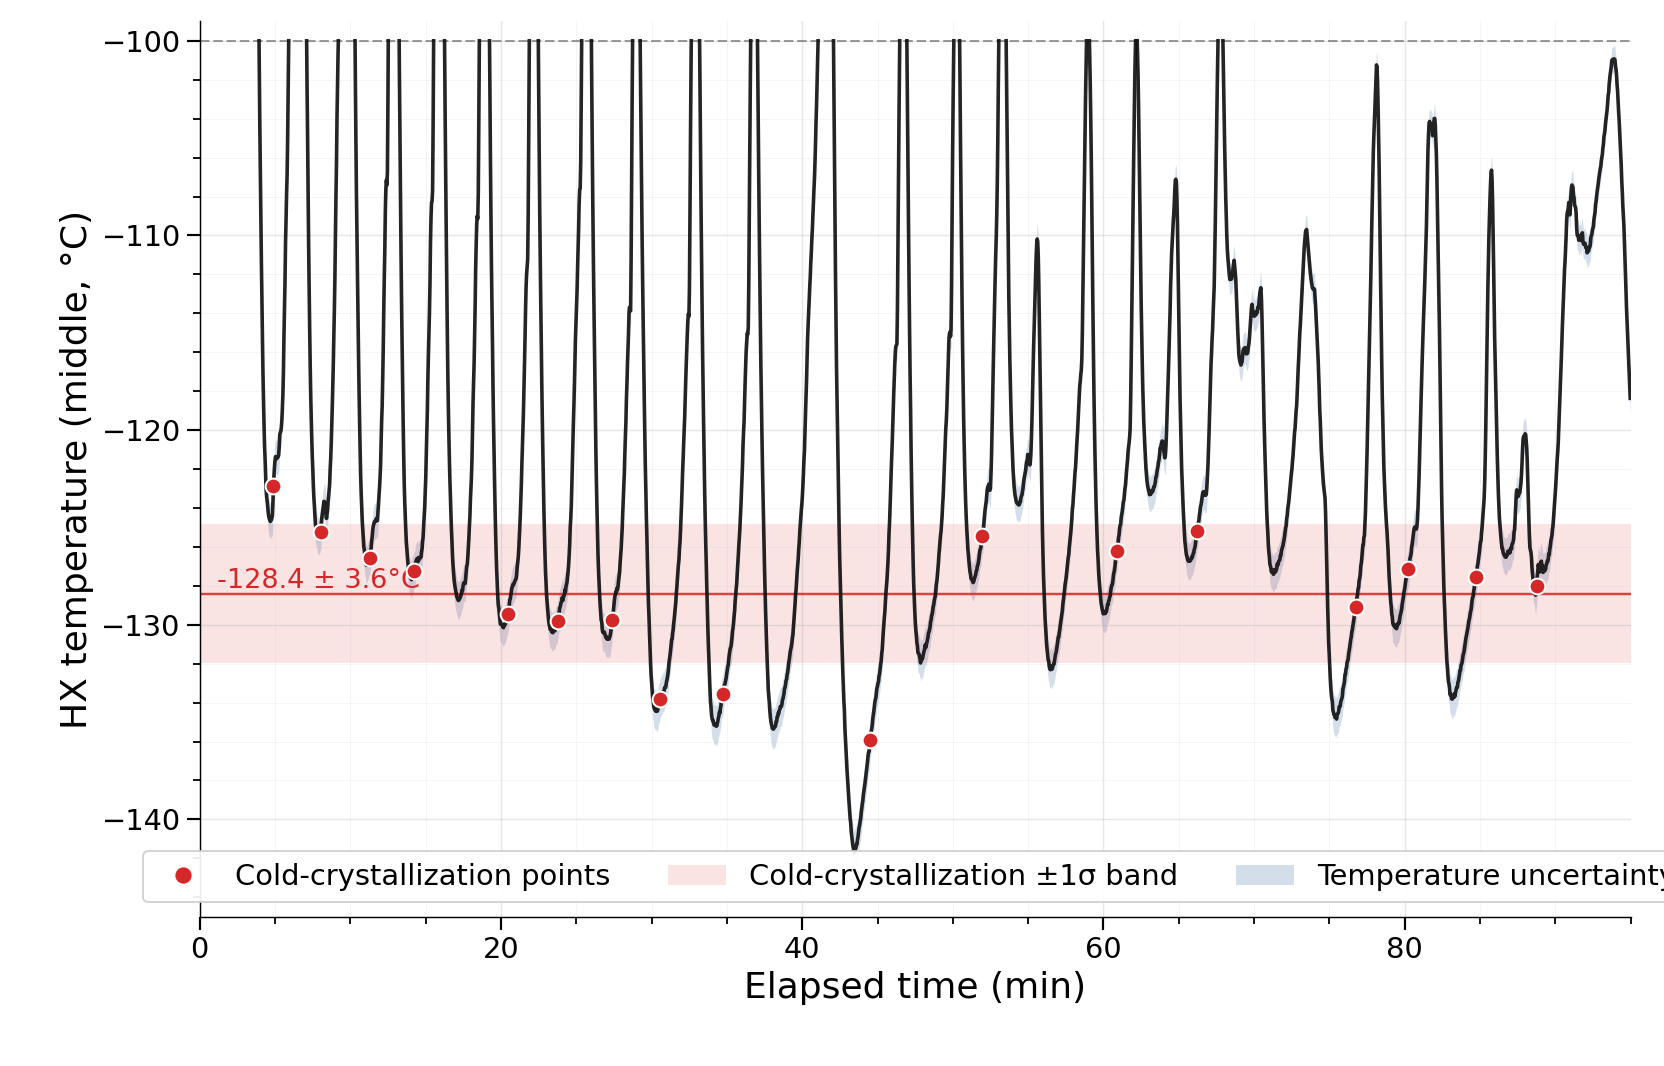

,display_cycle_number,original_cycle_number,elapsed_time_min,calibrated_THM_C,smoothed_warmup_rate_C_per_min,selection_note
0,1,3,4.90,-122.89,7.49,cold crystallization peak before sudden low-ra...
1,2,4,8.03,-125.25,2.65,cold crystallization peak before sudden low-ra...
2,3,5,11.28,-126.58,4.19,cold crystallization peak before sudden low-ra...
3,4,6,14.21,-127.26,2.08,cold crystallization peak before sudden low-ra...
4,6,8,20.45,-129.46,3.95,cold crystallization peak before sudden low-ra...
5,7,9,23.76,-129.78,3.05,earlier higher cold crystallization peak befor...
6,8,10,27.39,-129.73,4.15,cold crystallization peak before sudden low-ra...
7,9,11,30.56,-133.80,2.46,cold crystallization peak before sudden low-ra...
8,10,12,34.74,-133.56,4.69,shallow cold crystallization peak before rate ...
9,12,14,44.51,-135.93,6.42,cold crystallization peak before sudden low-ra...


Plot 03 marker-selection rate smoothing: Savitzky-Golay order 2, 31 samples (1.08 min)
Plot 03 displayed THM trace uses unsmoothed calibrated samples with interpolated -100°C endpoints
Plot 03 selected cold-crystallization cycles: 17
Plot 03 cycles shown without a cold-crystallization marker: 5, 11, 13, 15, 16, 18, 20, 24
Plot 03 cold crystallization mean ± total 1σ: -128.40 ± 3.57 °C (spread=3.44 °C, THM cal/extrap=0.95 °C, extrap model=0.93 °C)
Plot 03 HX temperature plot uses 18 below -100°C cooldown/warmup segments with pointwise 1σ THM uncertainty bands; mean band half-width=0.89 °C
Temporary plot 03 review diagnostic saved to /tmp/hfe_03_diagnostics/03_low_rate_review_facets.png


In [8]:
plot03a_rate_axis_max_C_per_min = 10.0
plot03a_transition_color = 'tab:red'
plot03a_trace_color = '0.05'
plot03a_rate_smoothing_window = min(31, len(freezing_all) if len(freezing_all) % 2 == 1 else len(freezing_all) - 1)
plot03a_rate_smoothing_window = max(5, plot03a_rate_smoothing_window)
if plot03a_rate_smoothing_window % 2 == 0:
    plot03a_rate_smoothing_window -= 1
plot03a_rate_smoothing_span_min = plot03a_rate_smoothing_window * float(np.nanmedian(np.diff(freezing_all['run_elapsed_min'].to_numpy(float))))
freezing_all['THM_plot03a_smooth_C'] = savgol_filter(
    freezing_all['THM_C'].to_numpy(float),
    plot03a_rate_smoothing_window,
    2,
    mode='interp',
)
freezing_all['dTHM_dt_plot03a_C_per_min'] = np.gradient(
    freezing_all['THM_plot03a_smooth_C'].to_numpy(float),
    freezing_all['run_elapsed_min'].to_numpy(float),
)
plot03a_rate_lookup = freezing_all[['time_s', 'dTHM_dt_plot03a_C_per_min']].copy()
plot03a_review_targets = pd.DataFrame([
    {'warmup_cycle_number': 1, 'target_elapsed_min': 4.90, 'selection_note': 'cold crystallization peak before sudden low-rate decrease'},
    {'warmup_cycle_number': 2, 'target_elapsed_min': 8.03, 'selection_note': 'cold crystallization peak before sudden low-rate decrease'},
    {'warmup_cycle_number': 3, 'target_elapsed_min': 11.28, 'selection_note': 'cold crystallization peak before sudden low-rate decrease'},
    {'warmup_cycle_number': 4, 'target_elapsed_min': 14.21, 'selection_note': 'cold crystallization peak before sudden low-rate decrease'},
    {'warmup_cycle_number': 6, 'target_elapsed_min': 20.45, 'selection_note': 'cold crystallization peak before sudden low-rate decrease'},
    {'warmup_cycle_number': 7, 'target_elapsed_min': 23.76, 'selection_note': 'earlier higher cold crystallization peak before sudden low-rate decrease'},
    {'warmup_cycle_number': 8, 'target_elapsed_min': 27.39, 'selection_note': 'cold crystallization peak before sudden low-rate decrease'},
    {'warmup_cycle_number': 9, 'target_elapsed_min': 30.56, 'selection_note': 'cold crystallization peak before sudden low-rate decrease'},
    {'warmup_cycle_number': 10, 'target_elapsed_min': 34.74, 'selection_note': 'shallow cold crystallization peak before rate decrease'},
    {'warmup_cycle_number': 12, 'target_elapsed_min': 44.51, 'selection_note': 'cold crystallization peak before sudden low-rate decrease'},
    {'warmup_cycle_number': 14, 'target_elapsed_min': 51.94, 'selection_note': 'cold crystallization peak before sudden low-rate decrease'},
    {'warmup_cycle_number': 17, 'target_elapsed_min': 60.90, 'selection_note': 'earlier local cold crystallization peak before sudden low-rate decrease'},
    {'warmup_cycle_number': 19, 'target_elapsed_min': 66.23, 'selection_note': 'cold crystallization peak before sudden low-rate decrease'},
    {'warmup_cycle_number': 21, 'target_elapsed_min': 76.76, 'selection_note': 'shallow cold crystallization peak before rate decrease'},
    {'warmup_cycle_number': 22, 'target_elapsed_min': 80.22, 'selection_note': 'cold crystallization peak before sudden low-rate decrease'},
    {'warmup_cycle_number': 23, 'target_elapsed_min': 84.71, 'selection_note': 'shallow cold crystallization peak before rate decrease'},
    {'warmup_cycle_number': 25, 'target_elapsed_min': 88.76, 'selection_note': 'late cold crystallization peak before rate decrease near -128°C'},
])

plot03a_supplemental_warmup_windows = pd.DataFrame([
    {
        'warmup_cycle_number': 100,
        'warmup_original_cycle_number': 100,
        'elapsed_min_start': 54.10,
        'elapsed_min_stop': 55.65,
    },
    {
        'warmup_cycle_number': 101,
        'warmup_original_cycle_number': 23,
        'elapsed_min_start': 62.95,
        'elapsed_min_stop': 64.80,
    },
    {
        'warmup_cycle_number': 102,
        'warmup_original_cycle_number': 24,
        'elapsed_min_start': 70.95,
        'elapsed_min_stop': 73.60,
    },
    {
        'warmup_cycle_number': 103,
        'warmup_original_cycle_number': 25,
        'elapsed_min_start': 86.45,
        'elapsed_min_stop': 87.95,
    },
    {
        'warmup_cycle_number': 104,
        'warmup_original_cycle_number': 26,
        'elapsed_min_start': 88.55,
        'elapsed_min_stop': 90.00,
    },
])
plot03a_warmup = warmup.copy()
plot03a_warmup = plot03a_warmup.merge(plot03a_rate_lookup, on='time_s', how='left')
plot03a_warmup['dTHM_dt_transition_C_per_min'] = plot03a_warmup['dTHM_dt_plot03a_C_per_min'].combine_first(
    plot03a_warmup['dTHM_dt_transition_C_per_min']
)
for _, supplemental_row in plot03a_supplemental_warmup_windows.iterrows():
    supplemental_segment = freezing_all.loc[
        freezing_all['run_elapsed_min'].sub(plot03_time_origin_min).between(
            float(supplemental_row['elapsed_min_start']),
            float(supplemental_row['elapsed_min_stop']),
            inclusive='both',
        )
        & freezing_all['THM_C'].lt(-100.0)
        & freezing_all['dTHM_dt_plot03a_C_per_min'].gt(0.0)
    ].sort_values('run_elapsed_min').copy()
    if supplemental_segment.empty:
        raise RuntimeError(
            f'No supplemental plot 03 warmup samples found for cycle {int(supplemental_row["warmup_cycle_number"])}.'
        )
    supplemental_segment[plot03_elapsed_time_col] = supplemental_segment['run_elapsed_min'] - plot03_time_origin_min
    supplemental_segment['dTHM_dt_transition_C_per_min'] = supplemental_segment['dTHM_dt_plot03a_C_per_min']
    supplemental_segment['warmup_cycle_number'] = int(supplemental_row['warmup_cycle_number'])
    supplemental_segment['warmup_original_cycle_number'] = int(supplemental_row['warmup_original_cycle_number'])
    supplemental_segment['cycle_min_C'] = float(supplemental_segment['THM_C'].min())
    plot03a_warmup = pd.concat([plot03a_warmup, supplemental_segment], ignore_index=True, sort=False)

plot03a_warmup['plot03a_source_cycle_number'] = plot03a_warmup['warmup_cycle_number'].astype(int)
plot03a_cycle_order = (
    plot03a_warmup.groupby('plot03a_source_cycle_number', sort=True)
    .agg(cycle_start_min=('run_elapsed_min', 'min'))
    .sort_values('cycle_start_min')
    .reset_index()
)
plot03a_cycle_number_map = {
    int(source_cycle_number): display_cycle_number
    for display_cycle_number, source_cycle_number in enumerate(plot03a_cycle_order['plot03a_source_cycle_number'], start=1)
}
plot03a_warmup['warmup_cycle_number'] = plot03a_warmup['plot03a_source_cycle_number'].map(plot03a_cycle_number_map).astype(int)



def select_plot03a_low_rate_sample(segment: pd.DataFrame, target_elapsed_min: float) -> pd.Series:
    segment = segment.sort_values('run_elapsed_min').copy()
    candidate_pool = segment.loc[
        np.isfinite(segment['dTHM_dt_transition_C_per_min'])
        & segment['dTHM_dt_transition_C_per_min'].gt(0.0)
        & segment['dTHM_dt_transition_C_per_min'].lt(plot03a_rate_axis_max_C_per_min)
    ].copy()
    if candidate_pool.empty:
        raise RuntimeError('No low-rate samples were available for a reviewed plot 03 cold-crystallization target.')
    candidate_pool['target_distance_min'] = candidate_pool[plot03_elapsed_time_col].sub(target_elapsed_min).abs()
    selected_sample = candidate_pool.sort_values('target_distance_min').iloc[0]
    if float(selected_sample['target_distance_min']) > 0.15:
        raise RuntimeError(
            f'Plot 03 cold-crystallization target at {target_elapsed_min:.2f} min did not match a nearby low-rate sample.'
        )
    return selected_sample


plot03a_transition_rows = []
for _, target_row in plot03a_review_targets.iterrows():
    selected_sample = select_plot03a_low_rate_sample(plot03a_warmup, float(target_row['target_elapsed_min']))
    cycle_number = int(selected_sample['warmup_cycle_number'])
    plot03a_transition_rows.append({
        'warmup_cycle_number': cycle_number,
        'warmup_original_cycle_number': int(selected_sample['warmup_original_cycle_number']),
        'run_elapsed_min': float(selected_sample['run_elapsed_min']),
        plot03_elapsed_time_col: float(selected_sample[plot03_elapsed_time_col]),
        'THM_C': float(selected_sample['THM_C']),
        'dTHM_dt_transition_C_per_min': float(selected_sample['dTHM_dt_transition_C_per_min']),
        'selection_note': str(target_row['selection_note']),
    })

plot03a_low_rate_transitions = pd.DataFrame(plot03a_transition_rows).sort_values('warmup_cycle_number').reset_index(drop=True)
if plot03a_low_rate_transitions.empty:
    raise RuntimeError('No reviewed cold-crystallization points were selected for plot 03.')

(
    plot03a_transition_mean_C,
    plot03a_transition_spread_sigma_C,
    plot03a_transition_calibration_sigma_C,
    plot03a_transition_extrapolation_sigma_C,
    plot03a_transition_total_sigma_C,
    plot03a_transition_count,
) = transition_temperature_statistics(plot03a_low_rate_transitions['THM_C'])

plot03a_selected_cycles = set(plot03a_low_rate_transitions['warmup_cycle_number'].astype(int))
plot03a_omitted_cycles = sorted(
    set(plot03a_warmup['warmup_cycle_number'].dropna().astype(int).unique()) - plot03a_selected_cycles
)

plot03a_diagnostic_dir = Path('/tmp/hfe_03_diagnostics')
plot03a_diagnostic_dir.mkdir(parents=True, exist_ok=True)
plot03a_diagnostic_path = plot03a_diagnostic_dir / '03_low_rate_review_facets.png'
plot03a_cycle_groups = list(plot03a_warmup.groupby('warmup_cycle_number', sort=True))
plot03a_diag_rows = int(np.ceil(len(plot03a_cycle_groups) / 4.0))
fig_diag, diag_axes = plt.subplots(plot03a_diag_rows, 4, figsize=(18.0, 2.6 * plot03a_diag_rows), sharey=True)
diag_axes = np.asarray(diag_axes).reshape(-1)
plot03a_transition_lookup = plot03a_low_rate_transitions.set_index('warmup_cycle_number')
for axis, (cycle_number, segment) in zip(diag_axes, plot03a_cycle_groups):
    cycle_number = int(cycle_number)
    segment = segment.sort_values('run_elapsed_min').copy()
    low_rate_trace = segment['dTHM_dt_transition_C_per_min'].where(
        segment['dTHM_dt_transition_C_per_min'].between(0.0, plot03a_rate_axis_max_C_per_min, inclusive='both')
    )
    axis.plot(segment[plot03_elapsed_time_col], low_rate_trace, color='black', lw=1.15)
    if cycle_number in plot03a_transition_lookup.index:
        transition = plot03a_transition_lookup.loc[cycle_number]
        axis.scatter(
            transition[plot03_elapsed_time_col],
            transition['dTHM_dt_transition_C_per_min'],
            s=45,
            facecolors='white',
            edgecolors=plot03a_transition_color,
            linewidths=1.5,
            zorder=4,
        )
        axis.annotate(
            f'{cycle_number}',
            (transition[plot03_elapsed_time_col], transition['dTHM_dt_transition_C_per_min']),
            xytext=(3, 3),
            textcoords='offset points',
            fontsize=8,
        )
    else:
        axis.text(0.04, 0.88, 'no visible peak', transform=axis.transAxes, fontsize=8, color='0.35')
    axis.set_title(f'Cycle {cycle_number}', fontsize=9)
    axis.set_ylim(0.0, plot03a_rate_axis_max_C_per_min)
    axis.grid(alpha=0.25)
for axis in diag_axes[len(plot03a_cycle_groups):]:
    axis.set_visible(False)
for axis in diag_axes[-4:]:
    axis.set_xlabel('Elapsed time from 60 min')
for axis in diag_axes[::4]:
    axis.set_ylabel('dTHM/dt (°C/min)')
fig_diag.tight_layout()
fig_diag.savefig(plot03a_diagnostic_path, dpi=180, bbox_inches='tight')
plt.close(fig_diag)


if 'plot03_cooldown_warmup_samples' not in globals():
    raise RuntimeError('Run the warmup-cycle preparation cell before plot 03 so below -100 C CSV-backed samples are available.')
plot03a_temperature_segment_ids = sorted(
    plot03_cooldown_warmup_samples['below100_segment'].dropna().astype(int).unique()
)
plot03a_temperature_segments = []

for segment_id in plot03a_temperature_segment_ids:
    temperature_segment = plot03_cooldown_warmup_samples.loc[
        plot03_cooldown_warmup_samples['below100_segment'].eq(int(segment_id))
    ].sort_values('run_elapsed_min').copy()
    if temperature_segment.empty:
        continue
    temperature_segment[plot03_elapsed_time_col] = temperature_segment['run_elapsed_min'] - plot03_time_origin_min
    if 'THM_uncertainty_C' not in temperature_segment.columns:
        temperature_segment['THM_uncertainty_C'] = thm_calibration_standard_uncertainty_C(temperature_segment['THM_C'])
    plot03a_temperature_segments.append(temperature_segment)
plot03a_temperature_uncertainty_mean_C = float(
    np.nanmean([segment['THM_uncertainty_C'].mean() for segment in plot03a_temperature_segments])
) if plot03a_temperature_segments else np.nan

fig, ax_temp = plt.subplots(figsize=SINGLE_FIGSIZE, constrained_layout=False)

plot03_temperature_uncertainty_color = '#4c78a8'
plot03_temperature_line_color = '0.05'
plot03_transition_band_color = 'tab:red'

for temperature_segment in plot03a_temperature_segments:
    time_values = temperature_segment[plot03_elapsed_time_col].to_numpy(float)
    thm_values = temperature_segment['THM_C'].to_numpy(float)
    thm_uncertainty = temperature_segment['THM_uncertainty_C'].to_numpy(float)
    ax_temp.fill_between(
        time_values,
        thm_values - thm_uncertainty,
        thm_values + thm_uncertainty,
        color=plot03_temperature_uncertainty_color,
        alpha=0.24,
        linewidth=0,
        zorder=1,
        rasterized=True,
    )
    ax_temp.plot(
        time_values,
        thm_values,
        color=plot03_temperature_line_color,
        lw=2.0,
        alpha=0.90,
        zorder=3,
        rasterized=True,
    )

ax_temp.scatter(
    plot03a_low_rate_transitions[plot03_elapsed_time_col],
    plot03a_low_rate_transitions['THM_C'],
    s=76,
    marker='o',
    facecolors=plot03_transition_band_color,
    edgecolors='white',
    linewidths=1.1,
    zorder=6,
    label='_nolegend_',
)

ax_temp.axhline(-100.0, color='0.45', lw=1.05, linestyle=(0, (5, 2)), alpha=0.75, label='_nolegend_')
ax_temp.axhspan(
    plot03a_transition_mean_C - plot03a_transition_total_sigma_C,
    plot03a_transition_mean_C + plot03a_transition_total_sigma_C,
    color=plot03_transition_band_color,
    alpha=0.13,
    linewidth=0,
    label='_nolegend_',
)
ax_temp.axhline(
    plot03a_transition_mean_C,
    color=plot03_transition_band_color,
    lw=1.35,
    alpha=0.86,
    label='_nolegend_',
)
ax_temp.text(
    0.012,
    plot03a_transition_mean_C,
    f'{plot03a_transition_mean_C:.1f} ± {plot03a_transition_total_sigma_C:.1f}°C',
    transform=ax_temp.get_yaxis_transform(),
    fontsize=15,
    color=plot03_transition_band_color,
    va='bottom',
    ha='left',
    clip_on=False,
)

style_axis(ax_temp)
ax_temp.set_ylabel('HX temperature (middle, °C)', fontsize=20)
ax_temp.set_xlabel('Elapsed time (min)', fontsize=20)
ax_temp.set_xlim(0.0, analysis_time_cutoff_min - plot03_time_origin_min)
y_min = 5.0 * np.floor((float(plot03a_warmup['THM_C'].min()) - 2.0) / 5.0)
ax_temp.set_ylim(y_min, -99.0)
ax_temp.tick_params(axis='both', which='major', labelsize=16, length=7, width=1.2)

plot03_legend_handles = [
    Line2D(
        [0],
        [0],
        marker='o',
        color='none',
        markerfacecolor=plot03_transition_band_color,
        markeredgecolor=plot03_transition_band_color,
        markersize=8.0,
        linestyle='None',
        label='Cold-crystallization points',
    ),
    Patch(
        facecolor=plot03_transition_band_color,
        alpha=0.13,
        edgecolor='none',
        label='Cold-crystallization ±1σ band',
    ),
    Patch(
        facecolor=plot03_temperature_uncertainty_color,
        alpha=0.24,
        edgecolor='none',
        label='Temperature uncertainty',
    ),
]
ax_temp.legend(handles=plot03_legend_handles, loc='lower center', fontsize=16, ncols=3, frameon=True, framealpha=0.92)

fig.subplots_adjust(left=0.12, right=0.98, top=0.98, bottom=0.14)
save_figure(fig, '03_hfe_low_rate_transition.png')
plt.show()

plot03a_review_display = plot03a_low_rate_transitions[[
    'warmup_cycle_number',
    'warmup_original_cycle_number',
    plot03_elapsed_time_col,
    'THM_C',
    'dTHM_dt_transition_C_per_min',
    'selection_note',
]].rename(columns={
    'warmup_cycle_number': 'display_cycle_number',
    'warmup_original_cycle_number': 'original_cycle_number',
    plot03_elapsed_time_col: 'elapsed_time_min',
    'THM_C': 'calibrated_THM_C',
    'dTHM_dt_transition_C_per_min': 'smoothed_warmup_rate_C_per_min',
})
display(plot03a_review_display.round({
    'elapsed_time_min': 2,
    'calibrated_THM_C': 2,
    'smoothed_warmup_rate_C_per_min': 2,
}))
print(
    f'Plot 03 marker-selection rate smoothing: Savitzky-Golay order 2, '
    f'{plot03a_rate_smoothing_window} samples ({plot03a_rate_smoothing_span_min:.2f} min)'
)
print('Plot 03 displayed THM trace uses unsmoothed calibrated samples with interpolated -100°C endpoints')
print(f'Plot 03 selected cold-crystallization cycles: {plot03a_transition_count}')
print('Plot 03 cycles shown without a cold-crystallization marker: ' + ', '.join(str(cycle) for cycle in plot03a_omitted_cycles))
print(
    f'Plot 03 cold crystallization mean ± total 1σ: {plot03a_transition_mean_C:.2f} ± {plot03a_transition_total_sigma_C:.2f} °C '
    f'(spread={plot03a_transition_spread_sigma_C:.2f} °C, '
    f'THM cal/extrap={plot03a_transition_calibration_sigma_C:.2f} °C, '
    f'extrap model={plot03a_transition_extrapolation_sigma_C:.2f} °C)'
)
print(
    f'Plot 03 HX temperature plot uses {len(plot03a_temperature_segments)} below -100°C cooldown/warmup segments '
    f'with pointwise 1σ THM uncertainty bands; mean band half-width={plot03a_temperature_uncertainty_mean_C:.2f} °C'
)
print(f'Temporary plot 03 review diagnostic saved to {plot03a_diagnostic_path}')


## 03b. Warmup 03-Marker Rise Versus Cycle Minimum

This diagnostic reuses the reviewed cold-crystallization marker positions from plot 03 and tests whether they appear at a fixed absolute THM or after a nearly fixed temperature rise from the coldest point of each warmup cycle.


Saved analysis/notebooks/HFE_measurements_plots/03b_hfe_warmup_marker_rise_vs_thm_min.png


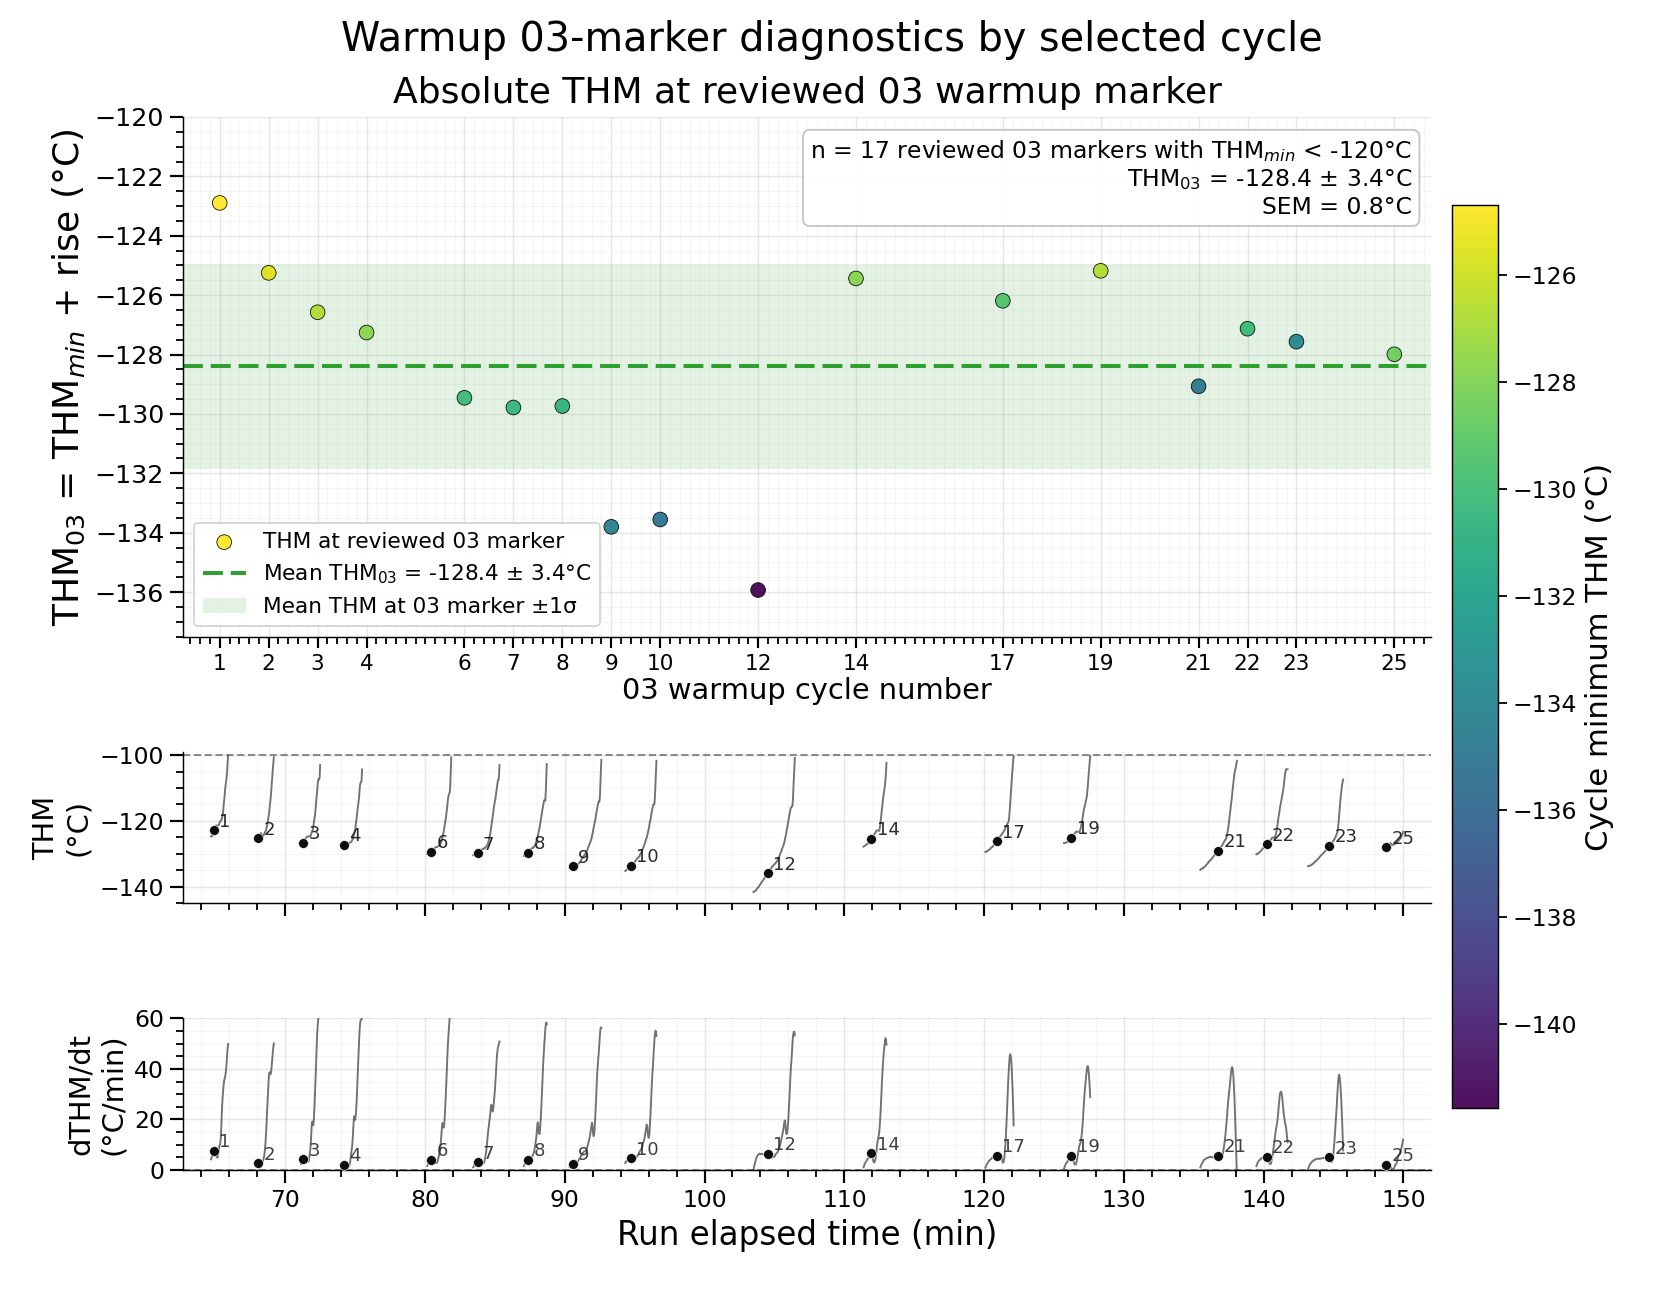

,plot03_cycle_number,warmup_original_cycle_number,cycle_time_min,plot03_marker_time_min,cycle_thm_min_C,temperature_rise_to_change_C,plot03_marker_THM_C,plot03_marker_rate_C_per_min,selection_note
0,1,3,64.69,64.90,-124.70,1.80,-122.89,7.49,cold crystallization peak before sudden low-ra...
1,2,4,67.93,68.04,-125.53,0.28,-125.25,2.65,cold crystallization peak before sudden low-ra...
2,3,5,71.14,71.28,-126.80,0.23,-126.58,4.19,cold crystallization peak before sudden low-ra...
3,4,6,74.07,74.21,-127.69,0.43,-127.26,2.08,cold crystallization peak before sudden low-ra...
4,6,8,80.17,80.45,-130.15,0.69,-129.46,3.95,cold crystallization peak before sudden low-ra...
5,7,9,83.45,83.76,-130.41,0.62,-129.78,3.05,earlier higher cold crystallization peak befor...
6,8,10,87.07,87.39,-130.73,1.00,-129.73,4.15,cold crystallization peak before sudden low-ra...
7,9,11,90.35,90.56,-134.45,0.64,-133.80,2.46,cold crystallization peak before sudden low-ra...
8,10,12,94.33,94.74,-135.20,1.64,-133.56,4.69,shallow cold crystallization peak before rate ...
9,12,14,103.50,104.51,-141.58,5.64,-135.93,6.42,cold crystallization peak before sudden low-ra...


Plot 03b warmup cycles with THM_min < -120°C and reviewed 03 markers: 17
THM_min range: -141.58 to -124.70 °C
Temperature rise from cycle minimum to 03 marker: 2.10 ± 2.02 °C
Absolute THM at 03 marker: -128.40 ± 3.44 °C; SEM = 0.83 °C


In [9]:
plot03d_minimum_threshold_C = -120.0
plot03d_warmup_cycles = plot03a_warmup.copy()
if plot03d_warmup_cycles.empty:
    raise RuntimeError('Plot 03b requires warmup cycles from plot 03.')
if plot03a_low_rate_transitions.empty:
    raise RuntimeError('Plot 03b requires reviewed marker positions from plot 03.')

plot03d_warmup_cycles['cycle_id'] = plot03d_warmup_cycles['warmup_cycle_number'].astype(int)
plot03d_warmup_cycles['cycle_thm_min_C'] = plot03d_warmup_cycles.groupby('cycle_id')['cycle_min_C'].transform('min')
plot03d_warmup_cycles['dTHM_dt_smooth_C_per_min'] = plot03d_warmup_cycles['dTHM_dt_transition_C_per_min']

plot03d_cycle_meta = (
    plot03d_warmup_cycles.groupby('warmup_cycle_number', sort=True)
    .agg(
        cycle_id=('cycle_id', 'first'),
        cycle_time_min=('run_elapsed_min', 'min'),
        cycle_time_end_min=('run_elapsed_min', 'max'),
        cycle_thm_min_C=('cycle_thm_min_C', 'first'),
        cycle_sample_count=('THM_C', 'size'),
        cycle_thm_span_C=('THM_C', lambda values: float(values.max() - values.min())),
    )
    .reset_index()
)

plot03d_marker_positions = plot03a_low_rate_transitions.rename(columns={
    'run_elapsed_min': 'slope_change_time_min',
    'THM_C': 'slope_change_thm_C',
    'dTHM_dt_transition_C_per_min': 'slope_change_rate_C_per_min',
}).copy()
plot03d_change_points = plot03d_marker_positions.merge(
    plot03d_cycle_meta,
    on='warmup_cycle_number',
    how='left',
    validate='one_to_one',
)
missing_plot03d_cycles = plot03d_change_points.loc[
    plot03d_change_points['cycle_id'].isna(),
    'warmup_cycle_number',
].astype(int).tolist()
if missing_plot03d_cycles:
    raise RuntimeError(f'Plot 03b could not match plot 03 marker cycles: {missing_plot03d_cycles}')

plot03d_change_points = plot03d_change_points.loc[
    plot03d_change_points['cycle_thm_min_C'].lt(plot03d_minimum_threshold_C)
].copy()
if plot03d_change_points.empty:
    raise RuntimeError(f'No plot 03b warmup cycles reached THM < {plot03d_minimum_threshold_C:.0f}°C.')

plot03d_change_points['cycle_id'] = plot03d_change_points['cycle_id'].astype(int)
plot03d_change_points = plot03d_change_points.sort_values('warmup_cycle_number').reset_index(drop=True)
plot03d_change_points['warmup_cycle_order'] = plot03d_change_points['warmup_cycle_number'].astype(int)
plot03d_change_points['temperature_rise_to_change_C'] = (
    plot03d_change_points['slope_change_thm_C'] - plot03d_change_points['cycle_thm_min_C']
)
plot03d_change_points['piecewise_improvement_pct'] = np.nan

plot03d_rise_mean_C = float(plot03d_change_points['temperature_rise_to_change_C'].mean())
plot03d_rise_sigma_C = float(plot03d_change_points['temperature_rise_to_change_C'].std(ddof=1))
plot03d_transition_mean_C = float(plot03d_change_points['slope_change_thm_C'].mean())
plot03d_transition_sigma_C = float(plot03d_change_points['slope_change_thm_C'].std(ddof=1))
plot03d_transition_sem_C = float(plot03d_transition_sigma_C / np.sqrt(len(plot03d_change_points)))

fig = plt.figure(figsize=(12.8, 10.0), constrained_layout=False)
grid = fig.add_gridspec(
    3,
    1,
    height_ratios=[3.6, 1.05, 1.05],
    hspace=0.42,
)
ax_main = fig.add_subplot(grid[0, 0])
ax_thm = fig.add_subplot(grid[1, 0])
ax_rate = fig.add_subplot(grid[2, 0], sharex=ax_thm)

cycle_min = plot03d_change_points['cycle_thm_min_C'].to_numpy(float)
cycle_norm = mpl.colors.Normalize(vmin=float(cycle_min.min()), vmax=float(cycle_min.max()))
cycle_cmap = plt.get_cmap('viridis')

main_scatter = ax_main.scatter(
    plot03d_change_points['warmup_cycle_order'],
    plot03d_change_points['slope_change_thm_C'],
    c=plot03d_change_points['cycle_thm_min_C'],
    cmap=cycle_cmap,
    norm=cycle_norm,
    s=66,
    alpha=0.94,
    edgecolors='black',
    linewidths=0.45,
    zorder=5,
    rasterized=True,
    label='THM at reviewed 03 marker',
)
transition_band = ax_main.axhspan(
    plot03d_transition_mean_C - plot03d_transition_sigma_C,
    plot03d_transition_mean_C + plot03d_transition_sigma_C,
    color='tab:green',
    alpha=0.13,
    linewidth=0,
    label='Mean THM at 03 marker ±1σ',
)
transition_line = ax_main.axhline(
    plot03d_transition_mean_C,
    color='tab:green',
    lw=2.2,
    linestyle=(0, (5, 2)),
    label=f'Mean THM$_{{03}}$ = {plot03d_transition_mean_C:.1f} ± {plot03d_transition_sigma_C:.1f}°C',
)

style_axis(ax_main)
ax_main.set_title('Absolute THM at reviewed 03 warmup marker', fontsize=DISSERTATION_TITLE_FONTSIZE, pad=8)
ax_main.set_xlabel('03 warmup cycle number', fontsize=max(DISSERTATION_LABEL_FONTSIZE - 4, 11), labelpad=2)
ax_main.set_ylabel('THM$_{03}$ = THM$_{min}$ + rise (°C)', fontsize=DISSERTATION_LABEL_FONTSIZE)
plot03d_x_values = plot03d_change_points['warmup_cycle_order'].to_numpy(int)
ax_main.set_xlim(max(0.25, float(plot03d_x_values.min()) - 0.75), float(plot03d_x_values.max()) + 0.75)
ax_main.set_xticks(plot03d_x_values)
ax_main.tick_params(axis='x', which='major', labelsize=max(DISSERTATION_TICK_FONTSIZE - 4, 9), length=6)
ax_main.tick_params(axis='y', which='major', labelsize=max(DISSERTATION_TICK_FONTSIZE - 2, 10))
transition_y_min = 2.5 * np.floor((float(plot03d_change_points['slope_change_thm_C'].min()) - 1.0) / 2.5)
transition_y_max = 2.5 * np.ceil((float(plot03d_change_points['slope_change_thm_C'].max()) + 1.0) / 2.5)
ax_main.set_ylim(transition_y_min, transition_y_max)
ax_main.text(
    0.985,
    0.96,
    f'n = {len(plot03d_change_points)} reviewed 03 markers with THM$_{{min}}$ < {plot03d_minimum_threshold_C:.0f}°C\n'
    f'THM$_{{03}}$ = {plot03d_transition_mean_C:.1f} ± {plot03d_transition_sigma_C:.1f}°C\n'
    f'SEM = {plot03d_transition_sem_C:.1f}°C',
    transform=ax_main.transAxes,
    va='top',
    ha='right',
    fontsize=max(DISSERTATION_LEGEND_FONTSIZE - 2, 10),
    bbox=dict(facecolor='white', edgecolor='0.75', alpha=0.92, boxstyle='round,pad=0.3'),
)
main_legend = ax_main.legend(
    handles=[main_scatter, transition_line, transition_band],
    loc='lower left',
    fontsize=max(DISSERTATION_LEGEND_FONTSIZE - 3, 10),
    frameon=True,
    framealpha=0.92,
)
main_legend.get_frame().set_linewidth(0.9)

plot03d_residual_color = '0.05'
for _, row in plot03d_change_points.iterrows():
    cycle = plot03d_warmup_cycles.loc[plot03d_warmup_cycles['cycle_id'].eq(row['cycle_id'])].copy()
    if cycle.empty:
        continue
    cycle = cycle.sort_values('run_elapsed_min')
    color = cycle_cmap(cycle_norm(float(row['cycle_thm_min_C'])))
    ax_thm.plot(
        cycle['run_elapsed_min'],
        cycle['THM_C'],
        color=plot03d_residual_color,
        lw=1.05,
        alpha=0.58,
        rasterized=True,
    )
    ax_thm.scatter(
        row['slope_change_time_min'],
        row['slope_change_thm_C'],
        s=30,
        color=plot03d_residual_color,
        edgecolors='white',
        linewidths=0.35,
        zorder=5,
        rasterized=True,
    )
    ax_thm.annotate(
        f'{int(row["warmup_cycle_order"])}',
        (row['slope_change_time_min'], row['slope_change_thm_C']),
        xytext=(3, 2),
        textcoords='offset points',
        fontsize=max(DISSERTATION_LEGEND_FONTSIZE - 5, 8),
        color=plot03d_residual_color,
        alpha=0.88,
    )
    ax_rate.plot(
        cycle['run_elapsed_min'],
        cycle['dTHM_dt_smooth_C_per_min'],
        color=plot03d_residual_color,
        lw=1.05,
        alpha=0.58,
        rasterized=True,
    )
    slope_change_rate = float(row['slope_change_rate_C_per_min'])
    ax_rate.scatter(
        row['slope_change_time_min'],
        slope_change_rate,
        s=30,
        color=plot03d_residual_color,
        edgecolors='white',
        linewidths=0.35,
        zorder=5,
        rasterized=True,
    )
    ax_rate.annotate(
        f'{int(row["warmup_cycle_order"])}',
        (row['slope_change_time_min'], slope_change_rate),
        xytext=(3, 2),
        textcoords='offset points',
        fontsize=max(DISSERTATION_LEGEND_FONTSIZE - 5, 8),
        color='0.15',
        alpha=0.88,
    )

ax_thm.axhline(-100.0, color='0.35', lw=1.0, linestyle=(0, (4, 2)), alpha=0.75)
ax_rate.axhline(0.0, color='0.35', lw=1.0, linestyle=(0, (4, 2)), alpha=0.75)
for axis in (ax_thm, ax_rate):
    style_axis(axis)
    axis.tick_params(axis='both', which='major', labelsize=max(DISSERTATION_TICK_FONTSIZE - 3, 10))
ax_thm.tick_params(axis='x', labelbottom=False)
ax_thm.set_ylabel('THM\n(°C)', fontsize=max(DISSERTATION_LABEL_FONTSIZE - 4, 10))
ax_rate.set_ylabel('dTHM/dt\n(°C/min)', fontsize=max(DISSERTATION_LABEL_FONTSIZE - 4, 10))
ax_rate.set_xlabel('Run elapsed time (min)', fontsize=max(DISSERTATION_LABEL_FONTSIZE - 2, 12))
ax_thm.set_xlim(plot03d_change_points['cycle_time_min'].min() - 2.0, plot03d_change_points['cycle_time_end_min'].max() + 2.0)
selected_cycle_ids = plot03d_change_points['cycle_id']
selected_cycle_samples = plot03d_warmup_cycles.loc[plot03d_warmup_cycles['cycle_id'].isin(selected_cycle_ids)].copy()
cycle_y_min = 5.0 * np.floor((selected_cycle_samples['THM_C'].min() - 1.0) / 5.0)
ax_thm.set_ylim(cycle_y_min, -99.0)
rate_values = selected_cycle_samples['dTHM_dt_smooth_C_per_min'].replace([np.inf, -np.inf], np.nan).dropna().to_numpy(float)
if rate_values.size:
    rate_y_min = min(0.0, 1.0 * np.floor((float(np.nanpercentile(rate_values, 1.0)) - 0.2) / 1.0))
    rate_y_max = max(1.0, 1.0 * np.ceil((float(np.nanpercentile(rate_values, 99.0)) + 0.2) / 1.0))
    ax_rate.set_ylim(rate_y_min, rate_y_max)

cbar = fig.colorbar(main_scatter, ax=[ax_main, ax_thm, ax_rate], pad=0.02, fraction=0.035)
cbar.set_label('Cycle minimum THM (°C)', fontsize=max(DISSERTATION_LABEL_FONTSIZE - 3, 11))
cbar.ax.tick_params(labelsize=max(DISSERTATION_TICK_FONTSIZE - 3, 10), length=5, width=1.0)

fig.suptitle('Warmup 03-marker diagnostics by selected cycle', fontsize=DISSERTATION_TITLE_FONTSIZE + 2, y=0.985)
fig.subplots_adjust(left=0.11, right=0.86, top=0.91, bottom=0.10)
save_figure(fig, '03b_hfe_warmup_marker_rise_vs_thm_min.png')
plt.show()

plot03d_display_columns = [
    'warmup_cycle_order',
    'warmup_original_cycle_number',
    'cycle_time_min',
    'slope_change_time_min',
    'cycle_thm_min_C',
    'temperature_rise_to_change_C',
    'slope_change_thm_C',
    'slope_change_rate_C_per_min',
    'selection_note',
]
plot03d_cycle_origin_table = plot03d_change_points[plot03d_display_columns].copy()
plot03d_cycle_origin_table = plot03d_cycle_origin_table.rename(columns={
    'warmup_cycle_order': 'plot03_cycle_number',
    'slope_change_time_min': 'plot03_marker_time_min',
    'slope_change_thm_C': 'plot03_marker_THM_C',
    'slope_change_rate_C_per_min': 'plot03_marker_rate_C_per_min',
})
display(plot03d_cycle_origin_table.round({
    'cycle_time_min': 2,
    'plot03_marker_time_min': 2,
    'cycle_thm_min_C': 2,
    'temperature_rise_to_change_C': 2,
    'plot03_marker_THM_C': 2,
    'plot03_marker_rate_C_per_min': 2,
}))

print(f'Plot 03b warmup cycles with THM_min < {plot03d_minimum_threshold_C:.0f}°C and reviewed 03 markers: {len(plot03d_change_points)}')
print(f'THM_min range: {plot03d_change_points["cycle_thm_min_C"].min():.2f} to {plot03d_change_points["cycle_thm_min_C"].max():.2f} °C')
print(f'Temperature rise from cycle minimum to 03 marker: {plot03d_rise_mean_C:.2f} ± {plot03d_rise_sigma_C:.2f} °C')
print(f'Absolute THM at 03 marker: {plot03d_transition_mean_C:.2f} ± {plot03d_transition_sigma_C:.2f} °C; SEM = {plot03d_transition_sem_C:.2f} °C')


## 04. April 24 Recirculation Overview With LN Scale Weight

Full-log overview for the latest recirculation run, using rolling trends and local spread bands for the measured operating variables.


Saved analysis/notebooks/HFE_measurements_plots/04_hfe_apr24_recirculation_overview.png
Plot 04 Apr 24 overview: 9,467 samples, bypass marker at 57.99 min, x max 300 min, loop mean TCs = TFO, TTI, TTO, TMI, displayed TCs = TFO, TTI, TTO, TMI, THI, THM
Plot 04 uncertainty bands: THM 1σ = 0.06-1.09 °C; loop-mean 1σ = 0.029-0.037 °C; density 1σ = 0.067-0.084 kg/m³


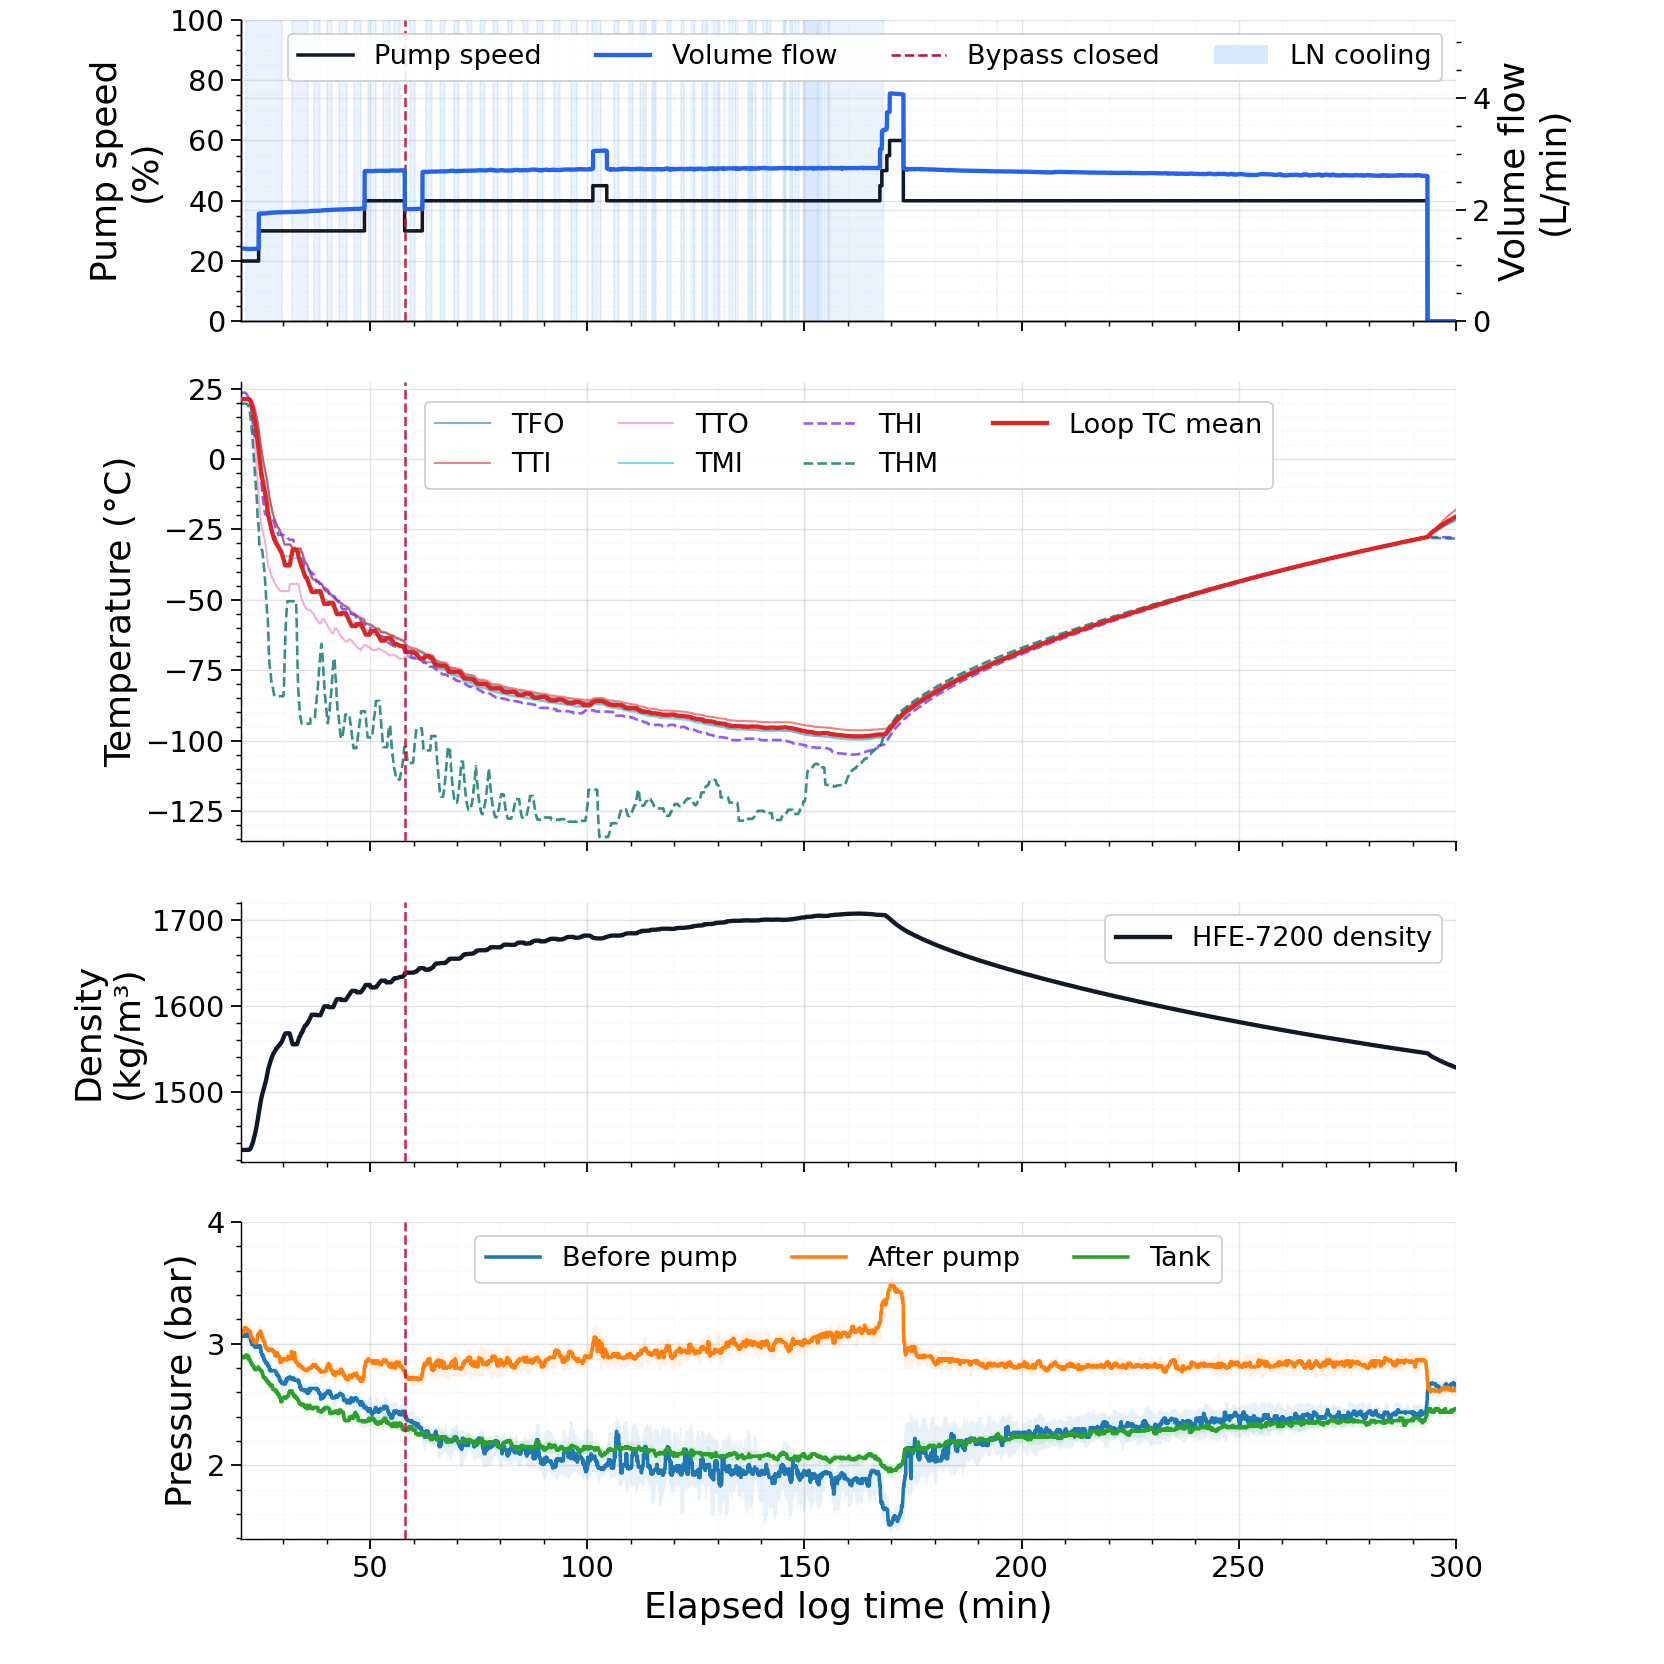

In [10]:
APR24_OVERVIEW_RUN_KEY = '0424'
APR24_OVERVIEW_FILENAME = '04_hfe_apr24_recirculation_overview.png'
APR24_OVERVIEW_FIGSIZE = (SINGLE_FIGSIZE[0], 12.8)
APR24_OVERVIEW_XMAX_MIN = 300.0
APR24_OVERVIEW_BAND_ALPHA = 0.13
APR24_OVERVIEW_LINEWIDTH = max(DISSERTATION_LINEWIDTH - 0.45, 1.8)
APR24_OVERVIEW_MAIN_LINEWIDTH = DISSERTATION_LINEWIDTH
APR24_OVERVIEW_LABEL_FONTSIZE = DISSERTATION_LABEL_FONTSIZE
APR24_OVERVIEW_TICK_FONTSIZE = DISSERTATION_TICK_FONTSIZE
APR24_OVERVIEW_LEGEND_FONTSIZE = DISSERTATION_LEGEND_FONTSIZE
APR24_OVERVIEW_GRID_ALPHA_MAJOR = 0.34
APR24_OVERVIEW_GRID_ALPHA_MINOR = 0.14
APR24_EXTRA_TEMPERATURE_COLUMNS = ('THI_C', 'THM_C')
APR24_TYPE_T_LOW_ANCHOR_C = -195.8
APR24_TYPE_T_LOW_ANCHOR_U_C = 0.049
APR24_DENSITY_TEMP_COEFF_KG_M3_PER_C = 2.3026
APR24_TC_NOISE_SIGMA_C = {
    'TFO_C': 0.0445,
    'TTI_C': 0.0444,
    'TTO_C': 0.0445,
    'TMI_C': 0.0445,
    'THM_C': 0.0440,
    'THI_C': 0.0475,
}


def apply_overview_grid(ax):
    ax.minorticks_on()
    ax.grid(True, which='major', alpha=APR24_OVERVIEW_GRID_ALPHA_MAJOR, linewidth=0.8)
    ax.grid(True, which='minor', alpha=APR24_OVERVIEW_GRID_ALPHA_MINOR, linestyle=':', linewidth=0.6)
    ax.tick_params(axis='both', which='major', labelsize=APR24_OVERVIEW_TICK_FONTSIZE, length=5.5, width=1.0)
    ax.tick_params(axis='both', which='minor', length=3.0, width=0.8)


def apply_overview_twin_axis_style(ax):
    ax.minorticks_on()
    ax.tick_params(axis='both', which='major', labelsize=APR24_OVERVIEW_TICK_FONTSIZE, length=5.5, width=1.0)
    ax.tick_params(axis='both', which='minor', length=3.0, width=0.8)


def overview_window_samples(frame: pd.DataFrame, window_min: float) -> int:
    time_min = finite_numeric(frame, 't_min').sort_values()
    positive_dt = time_min.diff().dropna()
    positive_dt = positive_dt.loc[positive_dt.gt(0.0)]
    median_dt_min = float(positive_dt.median()) if not positive_dt.empty else 1.0 / 30.0
    samples = max(5, int(round(float(window_min) / median_dt_min)))
    if samples % 2 == 0:
        samples += 1
    return samples


def rolling_quantile_band(frame: pd.DataFrame, column: str, *, window_min: float, min_fraction: float = 0.25) -> pd.DataFrame:
    series = finite_numeric(frame, column).replace([np.inf, -np.inf], np.nan)
    window = overview_window_samples(frame, window_min)
    min_periods = max(3, int(np.ceil(window * min_fraction)))
    rolling = series.rolling(window, center=True, min_periods=min_periods)
    stats = pd.DataFrame({
        'center': rolling.median(),
        'lower': rolling.quantile(0.16),
        'upper': rolling.quantile(0.84),
    }, index=frame.index)
    stats = stats.interpolate(limit_direction='both')
    return stats


def two_point_anchor_standard_uncertainty_C(temperature_c, lower_c: float, upper_c: float, lower_u_C: float, upper_u_C: float):
    temperature = np.asarray(temperature_c, dtype=float)
    anchor_span_C = upper_c - lower_c
    lower_term = ((upper_c - temperature) / anchor_span_C * lower_u_C) ** 2
    upper_term = ((temperature - lower_c) / anchor_span_C * upper_u_C) ** 2
    uncertainty = np.sqrt(lower_term + upper_term)
    return float(uncertainty) if uncertainty.ndim == 0 else uncertainty


def overview_tc_standard_uncertainty_C(column: str, temperature_c):
    temperature = np.asarray(temperature_c, dtype=float)
    noise_term = APR24_TC_NOISE_SIGMA_C.get(column, THM_RECOMMENDED_U_NOISE_C) ** 2
    if column in LOOP_TC_TEMPERATURE_COLUMNS:
        calibration = two_point_anchor_standard_uncertainty_C(
            temperature,
            APR24_TYPE_T_LOW_ANCHOR_C,
            THM_CALIBRATION_ROOM_ANCHOR_C,
            APR24_TYPE_T_LOW_ANCHOR_U_C,
            THM_CALIBRATION_U_ROOM_C,
        )
        model_term = np.zeros_like(temperature, dtype=float)
    else:
        calibration = two_point_anchor_standard_uncertainty_C(
            temperature,
            THM_CALIBRATION_LOW_ANCHOR_C,
            THM_CALIBRATION_ROOM_ANCHOR_C,
            THM_CALIBRATION_U_LOW_ANCHOR_C,
            THM_CALIBRATION_U_ROOM_C,
        )
        model_term = (THM_EXTRAPOLATION_MODEL_FRACTION * np.maximum(0.0, THM_CALIBRATION_LOW_ANCHOR_C - temperature)) ** 2
    uncertainty = np.sqrt(calibration**2 + noise_term + model_term)
    return float(uncertainty) if uncertainty.ndim == 0 else uncertainty


def prepare_apr24_overview_frame(frame: pd.DataFrame) -> tuple[pd.DataFrame, tuple[str, ...], tuple[str, ...]]:
    work = frame.copy().sort_values('time_s').reset_index(drop=True)
    loop_temp_cols = tuple(column for column in LOOP_TC_TEMPERATURE_COLUMNS if column in work.columns)
    if not loop_temp_cols:
        raise RuntimeError('No loop thermocouple columns found for the April 24 overview.')

    extra_temp_cols = tuple(
        column for column in APR24_EXTRA_TEMPERATURE_COLUMNS
        if column in work.columns and column not in loop_temp_cols
    )
    display_temp_cols = loop_temp_cols + extra_temp_cols

    loop_temperatures = pd.concat([finite_numeric(work, column) for column in loop_temp_cols], axis=1)
    loop_temperatures.columns = loop_temp_cols
    finite_count = loop_temperatures.notna().sum(axis=1)
    work['overview_loop_mean_C'] = loop_temperatures.mean(axis=1).where(finite_count.eq(len(loop_temp_cols)))

    for column in display_temp_cols:
        work[f'{column}_sigma_C'] = overview_tc_standard_uncertainty_C(column, finite_numeric(work, column).to_numpy(float))

    loop_sigma_squared = pd.concat(
        [finite_numeric(work, f'{column}_sigma_C') ** 2 for column in loop_temp_cols],
        axis=1,
    )
    work['overview_loop_mean_sigma_C'] = np.sqrt(loop_sigma_squared.sum(axis=1)) / len(loop_temp_cols)
    work.loc[~finite_count.eq(len(loop_temp_cols)), 'overview_loop_mean_sigma_C'] = np.nan
    work['overview_reference_density_kg_m3'] = hfe7200_density_kg_m3(work['overview_loop_mean_C'].to_numpy(float))
    work['overview_reference_density_sigma_kg_m3'] = (
        APR24_DENSITY_TEMP_COEFF_KG_M3_PER_C * work['overview_loop_mean_sigma_C']
    )
    return work, loop_temp_cols, display_temp_cols


def finite_values(*values) -> np.ndarray:
    arrays = []
    for value in values:
        array = np.asarray(value, dtype=float).ravel()
        array = array[np.isfinite(array)]
        if len(array):
            arrays.append(array)
    return np.concatenate(arrays) if arrays else np.array([], dtype=float)


def set_robust_ylim(ax, *values, include_zero: bool = False, pad_fraction: float = 0.08, lower_quantile: float = 0.002, upper_quantile: float = 0.998):
    combined = finite_values(*values)
    if include_zero:
        combined = np.concatenate([combined, np.array([0.0])]) if len(combined) else np.array([0.0])
    if not len(combined):
        return
    low = float(np.nanquantile(combined, lower_quantile))
    high = float(np.nanquantile(combined, upper_quantile))
    if not np.isfinite(low) or not np.isfinite(high):
        return
    if np.isclose(low, high):
        span = max(abs(high), 1.0)
        low -= 0.5 * span
        high += 0.5 * span
    span = high - low
    ax.set_ylim(low - pad_fraction * span, high + pad_fraction * span)


def visible_series(values: pd.Series | np.ndarray, visible_mask: pd.Series) -> pd.Series:
    series = pd.Series(values, index=visible_mask.index)
    return series.loc[visible_mask]


def plot_rolling_series(
    ax,
    frame: pd.DataFrame,
    column: str,
    *,
    color: str,
    label: str,
    window_min: float,
    lw: float = APR24_OVERVIEW_LINEWIDTH,
    alpha: float = 1.0,
    zorder: float = 2.5,
    band: bool = True,
    band_alpha: float = APR24_OVERVIEW_BAND_ALPHA,
    linestyle: str = '-',
):
    stats = rolling_quantile_band(frame, column, window_min=window_min)
    x = finite_numeric(frame, 't_min').to_numpy(float)
    center = stats['center'].to_numpy(float)
    lower = stats['lower'].to_numpy(float)
    upper = stats['upper'].to_numpy(float)
    if band:
        ax.fill_between(x, lower, upper, color=color, alpha=band_alpha, linewidth=0.0, zorder=zorder - 0.5)
    line, = ax.plot(x, center, color=color, lw=lw, alpha=alpha, zorder=zorder, label=label, linestyle=linestyle)
    return line, stats


def plot_rolling_uncertainty_series(
    ax,
    frame: pd.DataFrame,
    column: str,
    sigma_column: str,
    *,
    color: str,
    label: str,
    window_min: float,
    lw: float = APR24_OVERVIEW_LINEWIDTH,
    alpha: float = 1.0,
    zorder: float = 2.5,
    band_alpha: float = APR24_OVERVIEW_BAND_ALPHA,
    linestyle: str = '-',
):
    center_stats = rolling_quantile_band(frame, column, window_min=window_min)
    sigma_stats = rolling_quantile_band(frame, sigma_column, window_min=window_min)
    x = finite_numeric(frame, 't_min').to_numpy(float)
    center = center_stats['center'].to_numpy(float)
    sigma = sigma_stats['center'].to_numpy(float)
    band_stats = pd.DataFrame({
        'center': center_stats['center'],
        'lower': center_stats['center'] - sigma_stats['center'],
        'upper': center_stats['center'] + sigma_stats['center'],
    }, index=frame.index)
    ax.fill_between(x, center - sigma, center + sigma, color=color, alpha=band_alpha, linewidth=0.0, zorder=zorder - 0.5)
    line, = ax.plot(x, center, color=color, lw=lw, alpha=alpha, zorder=zorder, label=label, linestyle=linestyle)
    return line, band_stats


def plot_apr24_overview(frame: pd.DataFrame, *, bypass_closed_time_min: float):
    work, loop_temp_cols, display_temp_cols = prepare_apr24_overview_frame(frame)
    t_min_series = finite_numeric(work, 't_min')
    t_min = t_min_series.to_numpy(float)
    visible_mask = t_min_series.le(APR24_OVERVIEW_XMAX_MIN)
    x_min = float(np.nanmin(t_min))

    fig, axes = plt.subplots(
        4, 1,
        figsize=APR24_OVERVIEW_FIGSIZE,
        sharex=True,
        constrained_layout=False,
        gridspec_kw={'height_ratios': [0.95, 1.45, 0.82, 1.0]},
    )
    fig.subplots_adjust(left=0.145, right=0.875, top=0.988, bottom=0.075, hspace=0.18)

    ax_cmd = axes[0]
    command = finite_numeric(work, 'pump_cmd_pct')
    command_line = ax_cmd.step(
        t_min,
        command.to_numpy(float),
        where='mid',
        color='#111827',
        lw=APR24_OVERVIEW_LINEWIDTH,
        label='Pump speed',
    )[0]
    valve_open = finite_numeric(work, 'valve').fillna(0.0).ge(0.5).to_numpy(bool)
    ax_cmd.fill_between(t_min, 0.0, 100.0, where=valve_open, color='#60a5fa', alpha=0.13, step='mid')
    ax_cmd.set_ylabel('Pump speed\n(%)', fontsize=APR24_OVERVIEW_LABEL_FONTSIZE)
    ax_cmd.set_ylim(0.0, 100.0)
    apply_overview_grid(ax_cmd)

    ax_cmd_flow = ax_cmd.twinx()
    volume_line, volume_stats = plot_rolling_series(
        ax_cmd_flow,
        work,
        'volume_flow_lmin_si',
        color='#2563eb',
        label='Volume flow',
        window_min=1.0,
        lw=APR24_OVERVIEW_MAIN_LINEWIDTH,
        band_alpha=0.10,
    )
    ax_cmd_flow.set_ylabel('Volume flow\n(L/min)', fontsize=APR24_OVERVIEW_LABEL_FONTSIZE)
    visible_volume = finite_values(
        visible_series(volume_stats['lower'], visible_mask),
        visible_series(volume_stats['upper'], visible_mask),
        finite_numeric(work, 'volume_flow_lmin_si').loc[visible_mask],
    )
    volume_upper = float(np.nanmax(visible_volume)) if len(visible_volume) else 4.0
    ax_cmd_flow.set_ylim(0.0, max(5.0, 1.32 * volume_upper))
    apply_overview_twin_axis_style(ax_cmd_flow)

    command_handles = [
        command_line,
        volume_line,
        Line2D([0], [0], color='#be123c', lw=1.4, ls='--', label='Bypass closed'),
        Patch(facecolor='#60a5fa', edgecolor='none', alpha=0.24, label='LN cooling'),
    ]
    ax_cmd.legend(handles=command_handles, loc='upper right', fontsize=APR24_OVERVIEW_LEGEND_FONTSIZE, frameon=True, framealpha=0.92, ncols=4)

    ax_temp = axes[1]
    temp_styles = {
        'THI_C': {'color': '#7c3aed', 'linestyle': '--', 'alpha': 0.82, 'lw': 1.45, 'zorder': 2.1},
        'THM_C': {'color': '#0f766e', 'linestyle': '--', 'alpha': 0.82, 'lw': 1.45, 'zorder': 2.1},
    }
    loop_colors = plt.cm.tab10(np.linspace(0.0, 1.0, max(len(loop_temp_cols), 1)))
    temp_stats = []
    for color, column in zip(loop_colors, loop_temp_cols):
        line, stats = plot_rolling_uncertainty_series(
            ax_temp,
            work,
            column,
            f'{column}_sigma_C',
            color=color,
            label=tc_display_name(column),
            window_min=4.0,
            lw=1.15,
            alpha=0.56,
            zorder=2.0,
            band_alpha=0.055,
        )
        temp_stats.append(stats)
    for column in APR24_EXTRA_TEMPERATURE_COLUMNS:
        if column not in display_temp_cols:
            continue
        style = temp_styles[column]
        line, stats = plot_rolling_uncertainty_series(
            ax_temp,
            work,
            column,
            f'{column}_sigma_C',
            color=style['color'],
            label=tc_display_name(column),
            window_min=4.0,
            lw=style['lw'],
            alpha=style['alpha'],
            zorder=style['zorder'],
            band_alpha=0.055,
            linestyle=style['linestyle'],
        )
        temp_stats.append(stats)
    mean_line, mean_temp_stats = plot_rolling_uncertainty_series(
        ax_temp,
        work,
        'overview_loop_mean_C',
        'overview_loop_mean_sigma_C',
        color='#dc2626',
        label='Loop TC mean',
        window_min=2.0,
        lw=APR24_OVERVIEW_MAIN_LINEWIDTH,
        zorder=3.2,
        band_alpha=0.14,
    )
    ax_temp.set_ylabel('Temperature (°C)', fontsize=APR24_OVERVIEW_LABEL_FONTSIZE)
    set_robust_ylim(
        ax_temp,
        visible_series(mean_temp_stats['lower'], visible_mask),
        visible_series(mean_temp_stats['upper'], visible_mask),
        *[visible_series(stats['lower'], visible_mask) for stats in temp_stats],
        *[visible_series(stats['upper'], visible_mask) for stats in temp_stats],
        pad_fraction=0.04,
    )
    apply_overview_grid(ax_temp)
    ax_temp.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, 0.985),
        fontsize=APR24_OVERVIEW_LEGEND_FONTSIZE,
        ncols=4,
        frameon=True,
        framealpha=0.92,
    )

    ax_density = axes[2]
    density_line, density_stats = plot_rolling_uncertainty_series(
        ax_density,
        work,
        'overview_reference_density_kg_m3',
        'overview_reference_density_sigma_kg_m3',
        color='#111827',
        label='HFE-7200 density',
        window_min=2.0,
        lw=APR24_OVERVIEW_MAIN_LINEWIDTH,
        band_alpha=0.18,
    )
    ax_density.set_ylabel('Density\n(kg/m³)', fontsize=APR24_OVERVIEW_LABEL_FONTSIZE)
    set_robust_ylim(
        ax_density,
        visible_series(density_stats['lower'], visible_mask),
        visible_series(density_stats['upper'], visible_mask),
        pad_fraction=0.05,
    )
    apply_overview_grid(ax_density)
    ax_density.legend(loc='best', fontsize=APR24_OVERVIEW_LEGEND_FONTSIZE, frameon=True, framealpha=0.92)

    ax_pressure = axes[3]
    pressure_specs = [
        ('pump_pressure_before_bar_abs', '#1f77b4', 'Before pump'),
        ('pump_pressure_after_bar_abs', '#ff7f0e', 'After pump'),
        ('pump_pressure_tank_bar_abs', '#2ca02c', 'Tank'),
    ]
    pressure_stats = []
    for column, color, label in pressure_specs:
        line, stats = plot_rolling_series(
            ax_pressure,
            work,
            column,
            color=color,
            label=label,
            window_min=1.0,
            lw=APR24_OVERVIEW_LINEWIDTH,
            zorder=2.4,
            band_alpha=0.10,
        )
        pressure_stats.extend([
            visible_series(stats['lower'], visible_mask),
            visible_series(stats['upper'], visible_mask),
        ])
    ax_pressure.set_ylabel('Pressure (bar)', fontsize=APR24_OVERVIEW_LABEL_FONTSIZE)
    ax_pressure.set_xlabel('Elapsed log time (min)', fontsize=APR24_OVERVIEW_LABEL_FONTSIZE)
    set_robust_ylim(ax_pressure, *pressure_stats, pad_fraction=0.06)
    pressure_y_min = min(ax_pressure.get_ylim()[0], 1.4)
    ax_pressure.set_ylim(pressure_y_min, 4.0)
    apply_overview_grid(ax_pressure)
    ax_pressure.legend(loc='upper center', fontsize=APR24_OVERVIEW_LEGEND_FONTSIZE, ncols=3, frameon=True, framealpha=0.92)

    for ax in axes:
        ax.axvline(bypass_closed_time_min, color='#be123c', ls='--', lw=1.4, alpha=0.90, zorder=4.0)
        ax.set_xlim(x_min, APR24_OVERVIEW_XMAX_MIN)

    return fig, axes, work, loop_temp_cols, display_temp_cols


apr24_overview_frame = full_run_frames[APR24_OVERVIEW_RUN_KEY].copy()
apr24_bypass_closed_time_min = float(coverage.loc['log_20260424_153546.csv', 'bypass_marker_min'])
fig, axes, apr24_overview_frame, apr24_overview_loop_temp_cols, apr24_overview_display_temp_cols = plot_apr24_overview(
    apr24_overview_frame,
    bypass_closed_time_min=apr24_bypass_closed_time_min,
)
plot04_path = save_figure(fig, APR24_OVERVIEW_FILENAME)
print(
    'Plot 04 Apr 24 overview: '
    f"{len(apr24_overview_frame):,} samples, "
    f"bypass marker at {apr24_bypass_closed_time_min:.2f} min, "
    f"x max {APR24_OVERVIEW_XMAX_MIN:.0f} min, "
    f"loop mean TCs = {', '.join(tc_display_name(column) for column in apr24_overview_loop_temp_cols)}, "
    f"displayed TCs = {', '.join(tc_display_name(column) for column in apr24_overview_display_temp_cols)}"
)
visible_plot04 = apr24_overview_frame.loc[apr24_overview_frame['t_min'].le(APR24_OVERVIEW_XMAX_MIN)]
print(
    'Plot 04 uncertainty bands: '
    f"THM 1σ = {visible_plot04['THM_C_sigma_C'].min():.2f}-{visible_plot04['THM_C_sigma_C'].max():.2f} °C; "
    f"loop-mean 1σ = {visible_plot04['overview_loop_mean_sigma_C'].min():.3f}-{visible_plot04['overview_loop_mean_sigma_C'].max():.3f} °C; "
    f"density 1σ = {visible_plot04['overview_reference_density_sigma_kg_m3'].min():.3f}-{visible_plot04['overview_reference_density_sigma_kg_m3'].max():.3f} kg/m³"
)
plt.show()


## Output Inventory

In [11]:
plot_inventory = pd.DataFrame([
    {
        'figure': '01_hfe_density_vs_temperature.png',
        'description': 'HFE-7200 density versus flow-meter temperature, with meter uncertainty, constrained measured-density fit, fit uncertainty, and vendor reference',
    },
    {
        'figure': '02_hfe_apparent_viscosity_index_vs_loop_mean_temperature.png',
        'description': 'Estimated HFE viscosity inferred with the flow-corrected pump Delta P/Q model, plotted against the strict mean of the four loop thermocouples',
    },
    {
        'figure': '02cp_hfe_apparent_dynamic_viscosity_index_vs_loop_mean_temperature.png',
        'description': 'Plot 02 converted to estimated dynamic viscosity with the Plot 01 temperature-dependent HFE-7200 density fit',
    },
    {
        'figure': '03_hfe_low_rate_transition.png',
        'description': 'Focused low-rate heat-exchanger cold-crystallization peaks below 10 deg C/min with reviewed markers',
    },
    {
        'figure': '03b_hfe_warmup_marker_rise_vs_thm_min.png',
        'description': 'Warmup-cycle THM rise from the cycle minimum to the reviewed cold-crystallization marker positions from plot 03',
    },
    {
        'figure': '04_hfe_apr24_recirculation_overview.png',
        'description': 'April 24 full-log recirculation overview with pump command and volume flow, loop temperatures, reference density, absolute pressures, and bypass marker',
    },
])
plot_inventory['path'] = plot_inventory['figure'].map(lambda name: str((FIGURE_DIR / name).relative_to(REPO_ROOT)))
display(plot_inventory)


,figure,description,path
0,01_hfe_density_vs_temperature.png,HFE-7200 density versus flow-meter temperature...,analysis/notebooks/HFE_measurements_plots/01_h...
1,02_hfe_apparent_viscosity_index_vs_loop_mean_t...,Estimated HFE viscosity inferred with the flow...,analysis/notebooks/HFE_measurements_plots/02_h...
2,02cp_hfe_apparent_dynamic_viscosity_index_vs_l...,Plot 02 converted to estimated dynamic viscosi...,analysis/notebooks/HFE_measurements_plots/02cp...
3,03_hfe_low_rate_transition.png,Focused low-rate heat-exchanger cold-crystalli...,analysis/notebooks/HFE_measurements_plots/03_h...
4,03b_hfe_warmup_marker_rise_vs_thm_min.png,Warmup-cycle THM rise from the cycle minimum t...,analysis/notebooks/HFE_measurements_plots/03b_...
5,04_hfe_apr24_recirculation_overview.png,April 24 full-log recirculation overview with ...,analysis/notebooks/HFE_measurements_plots/04_h...
